# Phase 2 (projections) — grid extension vs. standalone solar

For every rural community of the Norte Amazónico study region we compare two ways to bring
electricity: extending the medium-voltage (MV) grid, or installing a standalone PV + battery
home system (SHS). The cheaper option on an annualised basis wins.

The **published classification is a greedy grid extension with definitive rejection and mid-span
taps**: starting from the existing MV network, the cheapest remaining candidate is connected as
long as the line still beats the standalone system; a rejected candidate is set aside for good
and the loop continues with the next one. A community therefore pays only the edge that links it
to its parent, not a private spur all the way back to the grid — neighbours share a trunk, and a
late community may tap into the middle of a line already built rather than run all the way to
its nearest endpoint. A tap creates a junction node, which is a point on a line and not a
community: it carries no household, no connection and no transformer.

The **node-only greedy**, the classification published before taps were allowed, is kept under
the `_glouton_noeud_seul` suffix.

The older **independent breakeven** screening (each community judged on its own spur from the
existing network) is kept alongside, under the `_breakeven_independant` suffix, because the
published CSVs carry both.

Layout: constants → data → core functions → horizons (2024 / 2035 / 2050) and CSV writing →
sensitivities → figures → final control.

> **Standalone ≠ no access.** A community classified `dispersed` is served by its own PV +
> battery system. It is not a community left without electricity.

## 1. Constants and sources

Every constant below carries its value, its source, and where that source lives in the
repository. Grid costs all come from the same table: Peña Balderrama et al. 2020,
*Energy for Sustainable Development* **56**, Table A.5 p.113.

In [187]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely as shp
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

pd.set_option("display.width", 250)

BASE = os.path.dirname(os.getcwd())   # repo root
OUT = "output"
FIG_DIR = os.path.join(OUT, "figures")

# The five EnergyScope modelling zones of the region. Same mapping as
# "analyse data ramp/sufficiency/demande.ipynb".
CLUSTERS = {
    "C1": ["Exaltación", "Reyes", "Santa_Rosa_Beni", "Ixiamas"],
    "C2": ["Bolpebra"],
    "C3": ["Guayaramerín", "Riberalta", "Puerto_Gonzalo_Moreno"],
    "C4": ["Bella_Flor", "Filadelfia", "Ingavi", "Nueva_Esperanza",
           "Porvenir", "Puerto_Rico", "San_Lorenzo", "San_Pedro",
           "Santa_Rosa_Pando", "Santos_Mercado", "Sena", "Villa_Nueva"],
    "C5": ["Cobija"],
}
MUNI_TO_CLUSTER = {m: c for c, munis in CLUSTERS.items() for m in munis}

EXT_YEARS = ["2024", "2035", "2050"]
ROOT = -1            # virtual root of every extension tree = the existing MV network
UTM_CRS = "EPSG:32719"   # UTM 19S, metres — gis_phase2_analysis.ipynb cell 2 line 40

print(f"repo root      : {BASE}")
print(f"clusters       : {', '.join(f'{c} ({len(m)} mun.)' for c, m in CLUSTERS.items())}")
print(f"municipalities : {len(MUNI_TO_CLUSTER)}")

repo root      : c:\Valen\Tfe\bolivia-energy-data
clusters       : C1 (4 mun.), C2 (1 mun.), C3 (3 mun.), C4 (12 mun.), C5 (1 mun.)
municipalities : 21


In [188]:
FX = 0.924        # 1 USD -> EUR, 2024 annual average (IRS/ECB)
I_RATE = 0.10     # discount rate — Misc_indep.json

# Grid extension. All three from Peña Balderrama et al. 2020, ESD 56, Table A.5 p.113.
MV_USD = 9_000     # USD/km, 33 kV MV line
CONN_USD = 150     # USD/household, last-mile connection
TRAFO_USD = 3_500  # USD/community, MV/LV transformer station
LIFE_MV = 30       # years
OM_RATE = 0.02     # O&M per year, as a fraction of overnight capex — Tables A.5/A.7

MV_EUR = MV_USD * FX        # 8 316.0 EUR/km
CONN_EUR = CONN_USD * FX    # 138.6 EUR/household
TRAFO_EUR = TRAFO_USD * FX  # 3 234.0 EUR/community

# Standalone PV + battery. EnergyScope catalogue, cross-checked against 2024 retail prices
# (World Bank IDTR). These replace the Peña Balderrama Table A.7 USD figures.
PV_EUR_KW = 2_730    # EUR/kW — reg_technologies.dat:10
LIFE_PV = 20         # years — reg_technologies.dat:10
BAT_EUR_KWH = 594    # EUR/kWh — reg_technologies.dat:138
LIFE_BAT = 10        # years

# SHS sizing. These three sources are not versioned in this repository, so they are cited in full.
SYS_EFF = 0.75    # PV -> usable AC, incl. battery/inverter/wiring losses.
                  # OFF-REPO: Panjon 2010, Revista Tecnica "energia" 6(1) p.91.
BATT_DAYS = 2     # days of autonomy.
                  # OFF-REPO: Lighting Global / World Bank 2021 rev. 2023, p.25 s.5.2.7 — 3-5 d
                  # typical, 1.5-2 d for non-critical loads. Rural lighting and phone charging is
                  # non-critical, so 2 d sits at the top of that band. Sensitivity (c) spans 1-3 d.
BATT_DOD = 0.80   # depth of discharge.
                  # OFF-REPO: same document p.28 s.5.2.9 — 70-90 % for lithium, 0.80 is mid-band.

# Existing home-system unit sizes, for the brownfield f_min fed to EnergyScope.
# ENDE BO-L1222 / Programa de Electrificación Rural, aligned with home_systems.ipynb.
PANEL_W = 50                   # Wp per panel-household (ENDE PEVD kit: >= 50 Wp)
GEN_W = 500                    # W per generator-household
BATT_KWH_PER_PANEL_HH = 0.123  # kWh per panel-household (ENDE PEVD kit: 123 Wh lithium 12 V)


def crf(rate, life):
    """Capital recovery factor: annualises an overnight cost over `life` years at `rate`."""
    return rate * (1 + rate) ** life / ((1 + rate) ** life - 1)


CRF_MV = crf(I_RATE, LIFE_MV)
CRF_PV = crf(I_RATE, LIFE_PV)
CRF_BAT = crf(I_RATE, LIFE_BAT)

assert abs(CRF_MV - 0.10607925) < 1e-8, f"unexpected CRF_MV: {CRF_MV}"

pd.DataFrame([
    {"parameter": "FX (USD->EUR)", "value": FX, "source": "2024 annual average, IRS/ECB"},
    {"parameter": "discount rate", "value": I_RATE, "source": "Misc_indep.json"},
    {"parameter": "MV line", "value": f"{MV_USD} USD/km -> {MV_EUR:,.1f} EUR/km", "source": "Peña Balderrama 2020, Table A.5 p.113"},
    {"parameter": "connection", "value": f"{CONN_USD} USD/HH -> {CONN_EUR:.1f} EUR/HH", "source": "Peña Balderrama 2020, Table A.5 p.113"},
    {"parameter": "transformer", "value": f"{TRAFO_USD} USD -> {TRAFO_EUR:,.1f} EUR/community", "source": "Peña Balderrama 2020, Table A.5 p.113"},
    {"parameter": "O&M rate", "value": OM_RATE, "source": "Peña Balderrama 2020, Tables A.5/A.7"},
    {"parameter": "PV capex", "value": f"{PV_EUR_KW} EUR/kW", "source": "reg_technologies.dat:10, x-checked IDTR World Bank"},
    {"parameter": "battery capex", "value": f"{BAT_EUR_KWH} EUR/kWh", "source": "reg_technologies.dat:138"},
    {"parameter": "system efficiency", "value": SYS_EFF, "source": "OFF-REPO - Panjon 2010, Revista Tecnica energia 6(1) p.91"},
    {"parameter": "days of autonomy", "value": BATT_DAYS, "source": "OFF-REPO - Lighting Global/World Bank 2021 rev.2023 p.25 s.5.2.7 (3-5 typical, 1.5-2 non-critical)"},
    {"parameter": "depth of discharge", "value": BATT_DOD, "source": "OFF-REPO - Lighting Global/World Bank 2021 rev.2023 p.28 s.5.2.9 (70-90 % lithium)"},
    {"parameter": "lifetimes MV/PV/battery", "value": f"{LIFE_MV}/{LIFE_PV}/{LIFE_BAT} y", "source": "Table A.5 (MV) / reg_technologies.dat"},
    {"parameter": "CRF MV/PV/battery", "value": f"{CRF_MV:.6f}/{CRF_PV:.6f}/{CRF_BAT:.6f}", "source": f"crf(i={I_RATE}, n)"},
])

,parameter,value,source
0,FX (USD->EUR),0.924,"2024 annual average, IRS/ECB"
1,discount rate,0.1,Misc_indep.json
2,MV line,"9000 USD/km -> 8,316.0 EUR/km","Peña Balderrama 2020, Table A.5 p.113"
3,connection,150 USD/HH -> 138.6 EUR/HH,"Peña Balderrama 2020, Table A.5 p.113"
4,transformer,"3500 USD -> 3,234.0 EUR/community","Peña Balderrama 2020, Table A.5 p.113"
5,O&M rate,0.02,"Peña Balderrama 2020, Tables A.5/A.7"
6,PV capex,2730 EUR/kW,"reg_technologies.dat:10, x-checked IDTR World ..."
7,battery capex,594 EUR/kWh,reg_technologies.dat:138
8,system efficiency,0.75,"OFF-REPO - Panjon 2010, Revista Tecnica energi..."
9,days of autonomy,2,OFF-REPO - Lighting Global/World Bank 2021 rev...


## 2. Data

Five inputs, plus the geometry needed by the tree and the maps:

| input | file |
|---|---|
| households and off-grid counts, Census 2024 | `exctraction of data/output/CSV_final.csv` |
| per-household demand profiles | `analyse data ramp/sufficiency/data ramp/<muni>/load_curve_*.csv` |
| solar capacity factor per cluster | `analyse data ramp/sufficiency/output_energyscope/<cluster>/Time_series.csv` |
| community distances to the MV network | `analyse_GIS_phase2/output/task1_community_distances_lines.csv` |
| community electrification, Census 2012 | `analyse_GIS_phase2/data/comunidades_electricidad_2012.csv` |
| community geometry | `data/comunidades_electricidad_2012.json` |
| MV network 2023 | `data/Líneas_de_Media_Tensión_2023.json` |
| projected households | `projections/output/menages_projetes.csv` |

`distance_km` is **taken as given** from `task1_community_distances_lines.csv`, never recomputed.
The geometry is joined only to obtain metric coordinates; the assertion at the end of this
section checks that the perpendicular foot recovers `distance_km` to 1e-12 km, which is what
makes community–community edges and community–grid edges commensurable.

In [189]:
csv_final = pd.read_csv(os.path.join(BASE, "exctraction of data/output/CSV_final.csv"),
                        encoding="utf-8-sig")
hh_col = [c for c in csv_final.columns
          if "2024" in c and "Total" in c and "VIVIENDA" in c.upper()][0]


def std_muni_name(depto, raw):
    """CSV_final municipality name -> CLUSTERS key.
    'Santa Rosa' exists in both Beni and Pando, so disambiguate by department."""
    raw = str(raw).strip()
    if raw == "Santa Rosa":
        return "Santa_Rosa_Beni" if depto == "Beni" else "Santa_Rosa_Pando"
    return raw.replace(" ", "_")


muni_rows = csv_final[csv_final["MUNICIPIO/TIOC"].notna()]
total_hh = {
    std_muni_name(row["DEPARTAMENTO"], row["MUNICIPIO/TIOC"]): row[hh_col]
    for _, row in muni_rows.iterrows()
    if std_muni_name(row["DEPARTAMENTO"], row["MUNICIPIO/TIOC"]) in MUNI_TO_CLUSTER
}
assert set(total_hh) == set(MUNI_TO_CLUSTER), "missing total_hh for some municipalities"

# Region-wide share of decentralised hot water met by the electric resistance host tech
# (DEC_DIRECT_ELEC) in the "appoint réaliste" sufficiency variant: 3.9468 / 71.6685 GWh from the
# sufficiency_phase2 run. sufficiency_water_heating is excluded from the SHS sizing on purpose:
# off-grid households do not run electric water heating, so including it would oversize PV+battery
# and understate the standalone cost. Only this small electric fraction is added back.
APPOINT_ELEC_SHARE = 0.04825
ECS_APPOINT_KWH_HH = 851 * APPOINT_ELEC_SHARE

RAMP_DIR = os.path.join(BASE, "analyse data ramp/sufficiency/data ramp")
per_hh_kwh, no_ramp_file = {}, []
for muni in MUNI_TO_CLUSTER:
    path = os.path.join(RAMP_DIR, muni, "load_curve_energy_service_full_year_Norte_Amazonia.csv")
    if not os.path.exists(path):
        no_ramp_file.append(muni)
        continue
    df = pd.read_csv(path)
    suff_cols = [c for c in df.columns
                 if c.startswith("sufficiency_") and c != "sufficiency_water_heating"]
    per_hh_kwh[muni] = df[suff_cols].sum().sum() / 60_000.0 / total_hh[muni] + ECS_APPOINT_KWH_HH

# Municipalities with no RAMP run fall back on the total_hh-weighted average of their cluster peers.
for muni in no_ramp_file:
    peers = [p for p in CLUSTERS[MUNI_TO_CLUSTER[muni]] if p in per_hh_kwh]
    per_hh_kwh[muni] = (sum(per_hh_kwh[p] * total_hh[p] for p in peers)
                        / sum(total_hh[p] for p in peers))
    print(f"{muni}: no RAMP file -> cluster average over {peers}")

# The sufficiency scenario is uniform by design. A drift here means a broken RAMP run upstream.
_mean_kwh = np.mean(list(per_hh_kwh.values()))
_dev = max(abs(v / _mean_kwh - 1) for v in per_hh_kwh.values())
assert _dev < 0.05, f"per_hh_kWh spread {_dev:.1%} > 5% — sufficiency scenario is not uniform"
print(f"per_hh_kWh = {_mean_kwh:,.1f} mean, max deviation {_dev:.2%} (uniform by design) -> OK")

per_hh_kWh = 1,168.9 mean, max deviation 3.21% (uniform by design) -> OK


In [190]:
cf_pv = {}
for cluster in CLUSTERS:
    ts = pd.read_csv(os.path.join(
        BASE, f"analyse data ramp/sufficiency/output_energyscope/{cluster}/Time_series.csv"),
        sep=";", index_col=0)
    cf_pv[cluster] = ts["PV"].mean()


def size_shs(kwh_per_year, cf, sys_eff=SYS_EFF, batt_days=BATT_DAYS, batt_dod=BATT_DOD,
             crf_bat=CRF_BAT):
    """Standalone PV + battery for one household: (overnight capex, annualised cost) in EUR.

    No solar-thermal water heater capex enters here: that equipment is needed on both sides of the
    comparison, so it cancels out. The four sizing arguments default to the published values and
    only sensitivity (c) overrides them.
    """
    pv_kw = kwh_per_year / (cf * 8760 * sys_eff)
    bat_kwh = (batt_days * kwh_per_year / 365) / batt_dod
    pv_eur = pv_kw * PV_EUR_KW
    bat_eur = bat_kwh * BAT_EUR_KWH
    capex = pv_eur + bat_eur
    return capex, CRF_PV * pv_eur + crf_bat * bat_eur + OM_RATE * capex


shs_capex, shs_annual = {}, {}
for muni, kwh in per_hh_kwh.items():
    shs_capex[muni], shs_annual[muni] = size_shs(kwh, cf_pv[MUNI_TO_CLUSTER[muni]])

pd.DataFrame([{"cluster": MUNI_TO_CLUSTER[m], "municipio": m,
               "per_hh_kWh": round(per_hh_kwh[m], 1),
               "overnight_capex_EUR_HH": round(shs_capex[m], 0),
               "annual_EUR_HH": round(shs_annual[m], 2)}
              for m in MUNI_TO_CLUSTER]).sort_values(["cluster", "municipio"])

,cluster,municipio,per_hh_kWh,overnight_capex_EUR_HH,annual_EUR_HH
0,C1,Exaltación,1173.8,7580.0,1258.21
3,C1,Ixiamas,1131.4,7306.0,1212.80
1,C1,Reyes,1158.1,7479.0,1241.38
2,C1,Santa_Rosa_Beni,1176.3,7596.0,1260.89
4,C2,Bolpebra,1166.8,7582.0,1257.14
5,C3,Guayaramerín,1175.3,7576.0,1257.87
7,C3,Puerto_Gonzalo_Moreno,1173.4,7563.0,1255.82
6,C3,Riberalta,1174.9,7573.0,1257.49
8,C4,Bella_Flor,1169.4,7712.0,1275.52
9,C4,Filadelfia,1164.3,7678.0,1269.91


In [191]:
# The household count that enters the breakeven is C + B. Source B households live in the same
# communities and share the same line, so a community with enough of them can be worth connecting
# when Source C alone would not justify it.
task1 = pd.read_csv(os.path.join(
    BASE, "analyse_GIS_phase2/output/task1_community_distances_lines.csv"), encoding="utf-8-sig")

# 2024 municipal Source B totals (Motor / Panel / Otra), from the census.
motor_col = [c for c in csv_final.columns if "2024" in c and "Motor" in c and "VIVIENDA" in c.upper()][0]
panel_col = [c for c in csv_final.columns if "2024" in c and "Panel" in c][0]
otra_col = [c for c in csv_final.columns if "2024" in c and "Otra" in c][0]
muni_b = {std_muni_name(r["DEPARTAMENTO"], r["MUNICIPIO/TIOC"]):
          {"total": r[motor_col] + r[panel_col] + r[otra_col], "motor": r[motor_col],
           "panel": r[panel_col], "otra": r[otra_col]}
          for _, r in csv_final[csv_final["MUNICIPIO/TIOC"].notna()].iterrows()
          if std_muni_name(r["DEPARTAMENTO"], r["MUNICIPIO/TIOC"]) in MUNI_TO_CLUSTER}

# 2012 community-level electrification survey, normalised onto the MUNI_TO_CLUSTER keys.
com2012 = pd.read_csv(os.path.join(
    BASE, "analyse_GIS_phase2/data/comunidades_electricidad_2012.csv"),
    encoding="utf-8-sig", low_memory=False)
com2012["Municipio_std"] = (com2012["Municipio"].str.extract(r"- (.+)$")[0].str.strip()
                            .fillna(com2012["Municipio"].str.strip()))
# Pando's "Santa Rosa" is recorded as "Santa Rosa del Abuná". Disambiguate by department before
# the general space -> underscore rule.
_sr = com2012["Municipio_std"].str.contains("Santa Rosa", na=False)
com2012.loc[_sr & (com2012["Depto"] == "Beni"), "Municipio_std"] = "Santa_Rosa_Beni"
com2012.loc[_sr & (com2012["Depto"] == "Pando"), "Municipio_std"] = "Santa_Rosa_Pando"
# "Villa Nueva (Loma Alta)" carries a parenthetical the general rule would not strip.
com2012.loc[com2012["Municipio_std"].str.contains("Villa Nueva", na=False), "Municipio_std"] = "Villa_Nueva"
com2012["Municipio_std"] = com2012["Municipio_std"].str.replace(" ", "_", regex=False)
assert not set(MUNI_TO_CLUSTER) - set(com2012["Municipio_std"]), \
    "a MUNI_TO_CLUSTER municipality has no matching 2012 row — Source B would silently be 0"

# B_2012 = min(Motor+Panel+Otra, Hog_Elec - Red_elec), capped so the households the survey already
# reports as grid-connected are not double-counted, then scaled to the 2024 municipal total.
study_b = com2012[com2012["Municipio_std"].isin(MUNI_TO_CLUSTER)].copy()
study_b["B_2012_raw"] = (study_b["Motor"].fillna(0) + study_b["Panel"].fillna(0)
                         + study_b["Otra"].fillna(0))
study_b["B_cap"] = (study_b["Hog_Elec"].fillna(0) - study_b["Red_elec"].fillna(0)).clip(lower=0)
study_b["B_2012"] = study_b[["B_2012_raw", "B_cap"]].min(axis=1)
for _c in ("Panel", "Motor", "Otra"):
    study_b[f"{_c}_2012"] = study_b[_c].fillna(0)
study_b["Comunidad_norm"] = study_b["Comunidad"].str.strip().str.upper()

for _col12, _key in [("B_2012", "total"), ("Panel_2012", "panel"),
                     ("Motor_2012", "motor"), ("Otra_2012", "otra")]:
    _denom = study_b.groupby("Municipio_std")[_col12].transform("sum")
    _b24 = study_b["Municipio_std"].map({m: muni_b[m][_key] for m in muni_b})
    study_b[_col12.replace("_2012", "_2024")] = (
        study_b[_col12] / _denom.replace(0, float("nan")) * _b24).fillna(0)

BCOLS = ["B_2024", "Panel_2024", "Motor_2024", "Otra_2024"]
b_comm = (study_b.groupby(["Municipio_std", "Comunidad_norm"])[BCOLS].sum().reset_index())

# Assign onto task1 by (Municipio_std, Comunidad_norm) without merging, to keep the exact 697-row
# structure. When several distinct communities share a name inside one municipality, the value is
# SPLIT across them (weighted by Poblacion_2012), not duplicated.
task1_bc = task1.copy()
task1_bc["Comunidad_norm"] = task1_bc["Comunidad"].str.strip().str.upper()
GROUP_KEYS = ["Municipio_std", "Comunidad_norm"]
_group_pop = task1_bc.groupby(GROUP_KEYS)["Poblacion_2012"].transform("sum")
_n_in_group = task1_bc.groupby(GROUP_KEYS)["Comunidad_norm"].transform("size")
_share = (task1_bc["Poblacion_2012"] / _group_pop).where(_group_pop > 0, 1.0 / _n_in_group)
_b_per_key = (b_comm.set_index(GROUP_KEYS)[BCOLS]
              .reindex(pd.MultiIndex.from_frame(task1_bc[GROUP_KEYS])).fillna(0.0))
for _col in BCOLS:
    task1_bc[_col] = _b_per_key[_col].values * _share.values

# Every census household is either assigned or an orphan. Orphans are 2012 community names with no
# counterpart in the GIS layer — a pre-existing gap between two independently compiled lists.
_assigned = task1_bc["B_2024"].sum()
_orphans = set(zip(b_comm["Municipio_std"], b_comm["Comunidad_norm"])) \
    - set(zip(task1_bc["Municipio_std"], task1_bc["Comunidad_norm"]))
_orphan_hh = (b_comm.set_index(GROUP_KEYS).loc[list(_orphans), "B_2024"].sum() if _orphans else 0.0)
_census_b = sum(muni_b[m]["total"] for m in muni_b)
assert abs((_assigned + _orphan_hh) - _census_b) < 1.0, \
    f"unexplained Source B gap: {_assigned:.1f} + {_orphan_hh:.1f} != {_census_b:.0f}"
print(f"Source B: {_assigned:,.1f} households assigned + {_orphan_hh:,.1f} unmatched "
      f"({len(_orphans)} community names absent from the GIS layer) = census {_census_b:,.0f} -> OK")

task1_bc["HH_2024_scaled"] = task1_bc["HH_2024_scaled"] + task1_bc["B_2024"]
print(f"{len(task1_bc)} communities, {task1_bc['HH_2024_scaled'].sum():,.0f} households (C + B)")

Source B: 9,078.1 households assigned + 246.9 unmatched (30 community names absent from the GIS layer) = census 9,325 -> OK
697 communities, 20,467 households (C + B)


In [192]:
# task1_community_distances_lines.csv carries no coordinates; the geometry only exists in the
# GeoJSON. MUNI_FILTER is copied verbatim from gis_phase2_analysis.ipynb cell 5 and the No_tiene > 0
# filter is its cell 6. Together they are what defines the 697 communities.
MUNI_FILTER = [
    ("Exaltación", "Beni", "Exaltac"), ("Guayaramerín", "Beni", "Guayaramer"),
    ("Reyes", "Beni", "Reyes"), ("Riberalta", "Beni", "Riberalta"),
    ("Santa_Rosa_Beni", "Beni", "Santa Rosa"), ("Ixiamas", "La Paz", "Ixiamas"),
    ("Bella_Flor", "Pando", "Bella Flor"), ("Bolpebra", "Pando", "Bolpebra"),
    ("Cobija", "Pando", "Cobija"), ("Filadelfia", "Pando", "Filadelfia"),
    ("Ingavi", "Pando", "Ingavi"), ("Nueva_Esperanza", "Pando", "Nueva Esperanza"),
    ("Porvenir", "Pando", "Porvenir"), ("Puerto_Gonzalo_Moreno", "Pando", "Puerto Gonzalo"),
    ("Puerto_Rico", "Pando", "Puerto Rico"), ("San_Lorenzo", "Pando", "San Lorenzo"),
    ("San_Pedro", "Pando", "San Pedro"), ("Santa_Rosa_Pando", "Pando", "Santa Rosa del Abun"),
    ("Santos_Mercado", "Pando", "Santos Mercado"), ("Sena", "Pando", "Sena"),
    ("Villa_Nueva", "Pando", "Villa Nueva"),
]

_com = gpd.read_file("data/comunidades_electricidad_2012.json")
_com.set_crs("EPSG:4326", inplace=True, allow_override=True)
_parts = []
for _std, _dept, _sub in MUNI_FILTER:
    _s = _com[_com["Depto"].str.contains(_dept, case=False, na=False)
              & _com["Municipio"].str.contains(_sub, case=False, na=False)].copy()
    _s["Municipio_std"] = _std
    _parts.append(_s)
_geo = pd.concat(_parts, ignore_index=True)
for _c in ("No_tiene", "poblacion"):
    _geo[_c] = pd.to_numeric(_geo[_c], errors="coerce").fillna(0)
_geo = (_geo[_geo["No_tiene"] > 0].to_crs(UTM_CRS)
        .rename(columns={"No_tiene": "No_tiene_2012", "poblacion": "Poblacion_2012"}))
_geo["x_utm_m"], _geo["y_utm_m"] = _geo.geometry.x, _geo.geometry.y

GEO_KEY = ["Municipio_std", "Comunidad", "No_tiene_2012", "Poblacion_2012"]
assert not _geo.duplicated(GEO_KEY).any(), "join key not unique on the GeoJSON side"
assert not task1_bc.duplicated(GEO_KEY).any(), "join key not unique on the task1 side"
task1_geo = task1_bc.merge(_geo[GEO_KEY + ["x_utm_m", "y_utm_m"]], on=GEO_KEY,
                           how="left", validate="one_to_one")
assert len(task1_geo) == 697, f"expected 697 communities, got {len(task1_geo)}"
assert task1_geo["x_utm_m"].notna().all(), "communities left without geometry after the join"

XY = task1_geo[["x_utm_m", "y_utm_m"]].to_numpy()
D_GRID = task1_geo["distance_km"].to_numpy()          # from task1, never recomputed
CL_ARR = task1_geo["Cluster"].to_numpy()
CL_MUNI = task1_geo["Municipio_std"].to_numpy()       # positional municipality lookup
# Planar euclidean, same CRS and metric as distance_km, so community-community and community-grid
# edges are commensurable.
D_COMM = np.hypot(XY[:, 0, None] - XY[None, :, 0], XY[:, 1, None] - XY[None, :, 1]) / 1000.0

# MV network 2023: the map background, and the exact point where a spur reaches the grid.
_lin = gpd.read_file("data/Líneas_de_Media_Tensión_2023.json")
_lin.set_crs("EPSG:4326", inplace=True, allow_override=True)
LIN_UTM = _lin.to_crs(UTM_CRS)
FOOT = np.array([shp.get_coordinates(g)[1] for g in
                 shp.shortest_line([shp.Point(p) for p in XY], LIN_UTM.geometry.union_all())])

_err = np.abs(np.hypot(FOOT[:, 0] - XY[:, 0], FOOT[:, 1] - XY[:, 1]) / 1000.0 - D_GRID).max()
assert _err < 1e-12, f"perpendicular foot does not reproduce distance_km: max error {_err:.2e} km"
print(f"geometry joined to {len(task1_geo)} communities, CRS {UTM_CRS}")
print(f"MV network 2023: {len(LIN_UTM)} features")
print(f"distance_km reproduced from the geometry to {_err:.2e} km (< 1e-12) -> OK")

geometry joined to 697 communities, CRS EPSG:32719
MV network 2023: 653 features
distance_km reproduced from the geometry to 8.85e-13 km (< 1e-12) -> OK


In [193]:
# Only the household count moves between horizons. Distances, per-household demand and unit costs
# stay exactly as computed above.
proj = pd.read_csv(os.path.join(BASE, "projections/output/menages_projetes.csv"))
hh_by_cluster_year = proj.groupby("cluster")[["hh_2024", "hh_2035", "hh_2050"]].sum()
hh_2024_baseline = hh_by_cluster_year["hh_2024"]

# The 2024 column must match this notebook's own census totals, so the 2024 scale factors are
# exactly 1.0 and the 2024 run is a true control.
for _c in CLUSTERS:
    assert abs(hh_2024_baseline[_c] - sum(total_hh[m] for m in CLUSTERS[_c])) < 1e-6, \
        f"{_c}: hh_2024 in menages_projetes.csv != total_hh from CSV_final"

SCENARIOS = {"2024": hh_2024_baseline,
             "2035": hh_by_cluster_year["hh_2035"],
             "2050": hh_by_cluster_year["hh_2050"]}
pd.DataFrame({y: SCENARIOS[y].round(0) for y in EXT_YEARS})

,2024,2035,2050
cluster,,,
C1,10933.0,12942.0,14873.0
C2,802.0,998.0,1204.0
C3,40298.0,47958.0,55641.0
C4,16612.0,20801.0,25487.0
C5,15564.0,19084.0,22994.0


## 3. Core functions

**The breakeven test.** A community is `dispersed` (standalone wins) when its annualised
standalone cost is below the annualised cost of connecting it:

$$\text{extension}_{HH} = (CRF_{MV} + OM)\times\Big[MV_{EUR/km}\times\frac{d}{HH} + CONN_{EUR}\Big]$$

**The greedy extension.** `greedy_connect` grows the connected set from the existing MV network
outwards. At each step the cheapest remaining candidate is measured on its *attachment cost* —
the shorter of its own perpendicular to the grid and its distance to an already-connected
community of the **same cluster** — and accepted if it passes the same breakeven test. A
rejected candidate is blocked for good and the loop moves on. Inter-cluster edges are forbidden
throughout: C1–C5 are distinct EnergyScope modelling zones, a line joining two of them would
correspond to nothing in the model.

**Mid-span taps, and what is published.** `greedy_connect` can only attach a community to a
**node**: an already connected community, or the perpendicular foot on the existing network. It
cannot tap into an **interior point** of an edge it has already built, although a mid-span tap is
ordinary distribution practice. `greedy_connect_with_taps` lifts that single restriction and **is
the published classification**; `greedy_connect` is kept unmodified beside it and reported under
the `_glouton_noeud_seul` suffix. The attachment cost becomes

$$\text{attach}_i = \min\Big(D_{GRID}[i],\ \min_{e \in \text{tree},\ cl(e)=cl(i)}
\ d_{\text{point-segment}}(i, e)\Big)$$

Attaching to a node is the case $t = 0$ or $t = 1$ of that minimum, so it needs no separate
branch. When the minimum falls at an interior point of an edge $(a,b)$, a junction node `T` is
created at the projected point, $(a,b)$ is replaced by $(a,T) + (T,b)$ — total length unchanged —
and $(T,i)$ is added. **A junction is not a community**: it carries no transformer, no connection
and no household, so `N_connectable` keeps its definition and the transformer post stays
`N_connectable × TRAFO_EUR`, never the edge count. Its cluster is that of the edge it cuts,
unambiguous since inter-cluster edges stay forbidden.

The transformer post reaches the breakeven test through an exact length equivalence,
`TRAFO_EUR/HH == MV_EUR × (TRAFO_EUR/MV_EUR)/HH`, so the candidate is tested at
`attach_cost + TRAFO_EUR/MV_EUR` km. This is an identity, not an approximation.

**Capex.** Three posts: line (EUR/km on the tree length), transformer (EUR per connected
community), connection (EUR per connected household).

In [194]:
def annual_extension_cost(distance_km, hh, mv_eur):
    """Annualised grid-extension cost, EUR per household per year."""
    slope = (CRF_MV + OM_RATE) * mv_eur
    return slope * distance_km / hh + (CRF_MV + OM_RATE) * CONN_EUR


def classify_communities(communities, mv_eur=MV_EUR):
    """Independent breakeven: judge every community on its own spur from the existing network.

    One row per community with HH > 0, in input order. `breakeven_distance_km` is the distance at
    which the two options cost the same; it scales with the household count.
    """
    rows = []
    for _, row in communities.iterrows():
        muni, dist, hh = row["Municipio_std"], row["distance_km"], row["HH_2024_scaled"]
        if hh <= 0:
            continue
        standalone = shs_annual[muni]
        extension = annual_extension_cost(dist, hh, mv_eur)
        slope = (CRF_MV + OM_RATE) * mv_eur
        d_star = max((standalone - (CRF_MV + OM_RATE) * CONN_EUR) * hh / slope, 0.0)
        rows.append({
            "Cluster": row["Cluster"], "Comunidad": row["Comunidad"], "Municipio_std": muni,
            "HH": hh, "distance_km": dist, "nearest_line_type": row["nearest_line_type"],
            "annual_extension_EUR_HH": round(extension, 2),
            "annual_standalone_EUR_HH": round(standalone, 2),
            "dispersed": standalone < extension,
            "breakeven_distance_km": round(d_star, 3),
        })
    return pd.DataFrame(rows)


def capex_posts(length_km, n_connectable, hh_connectable, mv_eur=None):
    """Extension capex split into its three posts. `mv_eur` lets the sensitivity vary the line cost
    without touching the published value."""
    mv = MV_EUR if mv_eur is None else mv_eur
    ligne = length_km * mv
    transfo = n_connectable * TRAFO_EUR
    raccord = hh_connectable * CONN_EUR
    total = ligne + transfo + raccord
    return {"ligne_EUR": ligne, "transformateur_EUR": transfo, "raccordement_EUR": raccord,
            "total_EUR": total,
            # Published convention, CRF only. This is what extension_capex_annualise_EUR carries.
            "total_annualise_EUR": CRF_MV * total,
            # The convention the classification used, CRF_MV + OM_RATE. Never written to a CSV,
            # only printed, so the gap between the two is quotable in the limitations.
            "total_annualise_avec_om_EUR": (CRF_MV + OM_RATE) * total}

In [195]:
def greedy_connect(hh, mv_eur=MV_EUR, shs_annual_by_muni=None):
    """Greedy grid extension with definitive rejection, node attachment only.

    Take the eligible candidate with the lowest per-household extension cost and apply the breakeven
    test at its current attachment cost. Accepted: it joins the tree, and its same-cluster
    neighbours may now attach to it more cheaply. Rejected: blocked for good, and the loop moves on.

    Terminates: every iteration moves one community into the connected or the blocked set, and none
    ever comes back out.

    This is not the published rule — greedy_connect_with_taps is. It is kept for the
    _glouton_noeud_seul columns. `shs_annual_by_muni` defaults to the published standalone costs;
    sensitivity (c) passes a re-sized variant.

    Returns (connected mask, {frozenset({i, parent}): edge length in km}, n_blocked_would_pass).
    """
    trafo_km_eq = TRAFO_EUR / mv_eur    # transformer post as an equivalent length
    n = len(hh)
    connected = np.zeros(n, dtype=bool)
    blocked = hh <= 0                   # a community without households is never a candidate
    edges = {}
    attach_cost = D_GRID.astype(float).copy()   # start: everyone attaches straight to the grid
    attach_parent = np.full(n, ROOT, dtype=int)
    standalone = np.array([(shs_annual if shs_annual_by_muni is None else shs_annual_by_muni)[m]
                           for m in CL_MUNI])

    while True:
        elig = np.where((~connected) & (~blocked))[0]
        if len(elig) == 0:
            break
        ext = mv_eur * attach_cost[elig] / hh[elig] + CONN_EUR + TRAFO_EUR / hh[elig]
        c = int(elig[np.argmin(ext)])

        if standalone[c] < annual_extension_cost(attach_cost[c] + trafo_km_eq, hh[c], mv_eur):
            blocked[c] = True
            continue

        connected[c] = True
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])

        # Inter-cluster edges are forbidden.
        cand = np.where((~connected) & (CL_ARR == CL_ARR[c]))[0]
        if len(cand):
            better = D_COMM[cand, c] < attach_cost[cand]
            attach_cost[cand[better]] = D_COMM[cand[better], c]
            attach_parent[cand[better]] = c

    assert len(edges) == int(connected.sum()), "one parent edge per connected community"

    # attach_cost only ever decreases, so at the end of the loop each blocked community sits at the
    # cheapest option it will ever have. If one of them would now pass the test it failed, the
    # result depends on the rejection order rather than on the economics. Blocking, not diagnostic.
    _blocked_pass = [c for c in np.where(blocked & (hh > 0))[0]
                     if standalone[c] >= annual_extension_cost(attach_cost[c] + trafo_km_eq,
                                                               hh[c], mv_eur)]
    assert not _blocked_pass, (
        f"{len(_blocked_pass)} blocked communities would pass the test at their final "
        f"attach_cost: definitive rejection is not neutral here")
    return connected, edges, len(_blocked_pass)

In [196]:
# Published attachment rule. Section 3 above states it; this cell implements it.
# Motivation, measured on the node-only 2024 tree: 43 of its 83 standalone communities had a tree
# edge passing closer than any attachable node, 32 of them strictly inside a community-community
# edge. greedy_connect stays above, unmodified, reported under the _glouton_noeud_seul suffix.

def _dist_point_to_segments(p, A, B):
    """Distance (km) and parameter t from the point `p` to each segment A[k]-B[k]. Metres in."""
    AB = B - A
    den = (AB ** 2).sum(1)
    den = np.where(den == 0, 1e-12, den)
    t = np.clip(((p - A) * AB).sum(1) / den, 0.0, 1.0)
    proj = A + t[:, None] * AB
    return np.hypot(proj[:, 0] - p[0], proj[:, 1] - p[1]) / 1000.0, t


def _dist_points_to_segment(P, a, b):
    """Distance (km) from each point P[k] to the single segment a-b. Metres in."""
    ab = b - a
    den = float((ab ** 2).sum())
    t = np.clip((P - a) @ ab / (den if den else 1e-12), 0.0, 1.0)
    proj = a + t[:, None] * ab
    return np.hypot(proj[:, 0] - P[:, 0], proj[:, 1] - P[:, 1]) / 1000.0


TAP_TOL_M = 1e-6   # below this, the projected point IS the endpoint node, not a new junction


def is_community(node):
    """True for a community node of a tree. False for ROOT and for a junction ("T", k)."""
    return isinstance(node, (int, np.integer)) and node != ROOT


def greedy_connect_with_taps(hh, mv_eur=MV_EUR, shs_annual_by_muni=None):
    """PUBLISHED CLASSIFICATION. greedy_connect with one difference: mid-span taps.

    Attachment cost of community i = min(D_GRID[i], distance to any already built edge of the same
    cluster). Attaching to a node is the case t = 0 or t = 1 of that minimum, so it needs no
    separate branch. When the minimum falls inside an edge (a, b), a junction T is created at the
    projected point, (a, b) becomes (a, T) + (T, b) — total length unchanged — and (T, i) is added.

    Selection rule, breakeven test and definitive rejection are greedy_connect verbatim.

    Returns a dict: connected mask, edges {eid: {u, v, pa, pb, km, cl}}, junction coordinates, final
    attach_cost, attachment kind per community, tap edge lengths, n_blocked_would_pass.
    """
    trafo_km_eq = TRAFO_EUR / mv_eur
    n = len(hh)
    connected = np.zeros(n, dtype=bool)
    blocked = hh <= 0
    standalone = np.array([(shs_annual if shs_annual_by_muni is None else shs_annual_by_muni)[m]
                           for m in CL_MUNI])

    edges, junction_xy = {}, {}
    next_eid, next_tid = 0, 0
    attach_cost = D_GRID.astype(float).copy()   # start: everyone attaches straight to the grid
    attach_kind = np.array(["root"] * n, dtype=object)
    tap_edge_km = []
    n_connected_prev = 0

    def add_edge(u, v, pa, pb, cl):
        nonlocal next_eid
        eid = next_eid
        next_eid += 1
        edges[eid] = {"u": u, "v": v, "pa": np.asarray(pa, float), "pb": np.asarray(pb, float),
                      "km": float(np.hypot(pa[0] - pb[0], pa[1] - pb[1]) / 1000.0), "cl": cl}
        return eid

    def relax(new_eids):
        """Lower attach_cost of the same-cluster candidates against the newly laid edges.
        The two halves of a split edge are geometrically the old edge, so they change nothing;
        passing them through anyway keeps this function purely additive."""
        for eid in new_eids:
            e = edges[eid]
            cand = np.where((~connected) & (CL_ARR == e["cl"]))[0]
            if not len(cand):
                continue
            d = _dist_points_to_segment(XY[cand], e["pa"], e["pb"])
            better = d < attach_cost[cand]
            attach_cost[cand[better]] = d[better]
            attach_kind[cand[better]] = "tap"

    while True:
        elig = np.where((~connected) & (~blocked))[0]
        if len(elig) == 0:
            break
        ext = mv_eur * attach_cost[elig] / hh[elig] + CONN_EUR + TRAFO_EUR / hh[elig]
        c = int(elig[np.argmin(ext)])

        if standalone[c] < annual_extension_cost(attach_cost[c] + trafo_km_eq, hh[c], mv_eur):
            blocked[c] = True
            continue

        # attach_cost is maintained incrementally for the selection. This recovers which edge and
        # at which t; the assertion ties the two together.
        eids = [eid for eid, e in edges.items() if e["cl"] == CL_ARR[c]]
        best_d, best_eid, best_t = float(D_GRID[c]), None, None
        if eids:
            _d, _t = _dist_point_to_segments(XY[c], np.array([edges[e]["pa"] for e in eids]),
                                             np.array([edges[e]["pb"] for e in eids]))
            _a = int(np.argmin(_d))
            if _d[_a] < best_d:
                best_d, best_eid, best_t = float(_d[_a]), eids[_a], float(_t[_a])
        assert abs(best_d - attach_cost[c]) < 1e-9, \
            f"incremental attach_cost {attach_cost[c]:.9f} != exact resolution {best_d:.9f}"

        connected[c] = True
        new_eids = []
        if best_eid is None:
            new_eids.append(add_edge(c, ROOT, XY[c], FOOT[c], CL_ARR[c]))
            attach_kind[c] = "root"
        else:
            e = edges[best_eid]
            P = e["pa"] + best_t * (e["pb"] - e["pa"])
            if np.hypot(*(P - e["pa"])) < TAP_TOL_M:
                anchor, anchor_xy = e["u"], e["pa"]
                attach_kind[c] = "node"
            elif np.hypot(*(P - e["pb"])) < TAP_TOL_M:
                anchor, anchor_xy = e["v"], e["pb"]
                attach_kind[c] = "node"
            else:
                tid = ("T", next_tid)
                next_tid += 1
                junction_xy[tid] = P
                del edges[best_eid]
                _e1 = add_edge(e["u"], tid, e["pa"], P, e["cl"])
                _e2 = add_edge(tid, e["v"], P, e["pb"], e["cl"])
                assert abs(edges[_e1]["km"] + edges[_e2]["km"] - e["km"]) < 1e-9, \
                    "cutting the edge changed its length"
                new_eids += [_e1, _e2]
                anchor, anchor_xy = tid, P
                attach_kind[c] = "tap"
                tap_edge_km.append(best_d)
            new_eids.append(add_edge(c, anchor, XY[c], anchor_xy, CL_ARR[c]))

        relax(new_eids)
        assert int(connected.sum()) >= n_connected_prev, "the connected set shrank"
        n_connected_prev = int(connected.sum())

    _blocked_pass = [c for c in np.where(blocked & (hh > 0))[0]
                     if standalone[c] >= annual_extension_cost(attach_cost[c] + trafo_km_eq,
                                                               hh[c], mv_eur)]
    assert not _blocked_pass, (
        f"{len(_blocked_pass)} blocked communities would pass the test at their final "
        f"attach_cost: definitive rejection is not neutral")
    return {"connected": connected, "edges": edges, "junction_xy": junction_xy,
            "attach_cost": attach_cost, "attach_kind": attach_kind,
            "tap_edge_km": np.array(tap_edge_km), "blocked_pass": len(_blocked_pass)}


def tap_tree_edges(out):
    """The tap tree in the notebook's edge convention, so tree_parents and path_edges_to_root keep
    working unchanged.

    Returns ({frozenset({u, v}): km}, {frozenset({u, v}): (pa, pb, cluster)}). A node id is a
    community index, ROOT, or ("T", k). The geometry travels beside the lengths because once a
    junction is involved the endpoints alone no longer say where the edge runs.
    """
    km, geom = {}, {}
    for e in out["edges"].values():
        key = frozenset((e["u"], e["v"]))
        assert key not in km, f"two edges share the endpoint pair {key}"
        km[key], geom[key] = e["km"], (e["pa"], e["pb"], e["cl"])
    return km, geom


def edges_length_by_cluster_tap(km, geom):
    """Tap tree length split by cluster, read off the cluster carried by each edge."""
    out = {c: 0.0 for c in CLUSTERS}
    for e, w in km.items():
        out[geom[e][2]] += w
    return out


def junctions_by_cluster(out, geom):
    """{cluster: number of junctions}. A junction inherits the cluster of the edge it cuts."""
    counts = {c: 0 for c in CLUSTERS}
    for tid in out["junction_xy"]:
        _cl = {geom[e][2] for e in geom if tid in e}
        assert len(_cl) == 1, f"junction {tid} sits on edges of {_cl}"
        counts[_cl.pop()] += 1
    return counts


def check_tap_tree(out, label):
    """Blocking checks on a tap tree: it spans the connected communities plus the junctions, it has
    exactly one edge per node other than the root, and it carries no inter-cluster edge."""
    edges, conn, jxy = out["edges"], out["connected"], out["junction_xy"]
    nodes = {ROOT} | set(np.where(conn)[0].tolist()) | set(jxy)
    adj = {}
    for e in edges.values():
        adj.setdefault(e["u"], []).append(e["v"])
        adj.setdefault(e["v"], []).append(e["u"])
        for _endp in (e["u"], e["v"]):
            if is_community(_endp):
                assert CL_ARR[_endp] == e["cl"], f"{label}: inter-cluster edge detected"
    assert set(adj) == nodes, f"{label}: an edge endpoint is outside the node set"
    seen, stack = {ROOT}, [ROOT]
    while stack:
        u = stack.pop()
        for v in adj.get(u, []):
            if v not in seen:
                seen.add(v)
                stack.append(v)
    assert seen == nodes, f"{label}: tree not connected ({len(seen)} reached / {len(nodes)})"
    assert len(edges) == len(nodes) - 1, f"{label}: {len(edges)} edges != {len(nodes) - 1}"
    assert len(edges) == int(conn.sum()) + len(jxy), \
        f"{label}: {len(edges)} edges != {int(conn.sum())} connected + {len(jxy)} junctions"
    return float(sum(e["km"] for e in edges.values()))


def greedy_tree_nodes_only(idx, hh, mv_eur=MV_EUR):
    """The tree greedy_connect would build without taps over exactly the node set `idx`: same
    ordering rule, same node-only attachment, acceptance forced. The published tree must not be
    longer than this."""
    todo = [int(i) for i in idx]
    attach_cost = D_GRID.astype(float).copy()
    attach_parent = np.full(len(hh), ROOT, dtype=int)
    edges = {}
    while todo:
        arr = np.array(todo)
        ext = mv_eur * attach_cost[arr] / hh[arr] + CONN_EUR + TRAFO_EUR / hh[arr]
        c = int(arr[np.argmin(ext)])
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])
        todo.remove(c)
        rest = np.array([k for k in todo if CL_ARR[k] == CL_ARR[c]], dtype=int)
        if len(rest):
            better = D_COMM[rest, c] < attach_cost[rest]
            attach_cost[rest[better]] = D_COMM[rest[better], c]
            attach_parent[rest[better]] = c
    assert len(edges) == len(idx), "one parent edge per node of the reference tree"
    return edges

In [197]:
def build_tree_mst(idx, cluster):
    """Minimum spanning tree over the nodes `idx` plus the root. Allowed edges: community-root
    (weight distance_km) and same-cluster community-community (weight D_COMM).
    Returns {frozenset({i, j}): length in km}."""
    n = len(idx)
    w = np.zeros((n + 1, n + 1))
    same = cluster[idx][:, None] == cluster[idx][None, :]
    w[1:, 1:] = np.where(same, D_COMM[np.ix_(idx, idx)], 0.0)
    w[0, 1:] = w[1:, 0] = D_GRID[idx]
    coo = minimum_spanning_tree(csr_matrix(np.triu(w))).tocoo()
    return {frozenset((ROOT if a == 0 else idx[a - 1], ROOT if b == 0 else idx[b - 1])): d
            for a, b, d in zip(coo.row, coo.col, coo.data)}


def extend_tree_prim(edges0, idx, cluster):
    """Prim started from the node set already covered by `edges0`: every existing edge is kept, only
    what connects the newly eligible nodes is added, so a line built in 2024 is not torn down in
    2035. Same allowed edges as build_tree_mst."""
    edges = dict(edges0)
    inside = {ROOT}
    for e in edges0:
        inside |= set(e)
    todo = [i for i in idx if i not in inside]
    best = {}
    for i in todo:
        best[i] = (D_GRID[i], ROOT)
        for j in inside:
            if j != ROOT and cluster[j] == cluster[i] and D_COMM[i, j] < best[i][0]:
                best[i] = (D_COMM[i, j], j)
    while todo:
        i = min(todo, key=lambda k: best[k][0])
        w, j = best[i]
        edges[frozenset((i, j))] = w
        todo.remove(i)
        inside.add(i)
        for k in todo:
            if cluster[k] == cluster[i] and D_COMM[i, k] < best[k][0]:
                best[k] = (D_COMM[i, k], i)
    return edges


def edges_length_by_cluster(edges):
    """Tree length split by cluster. Every edge belongs to exactly one: inter-cluster
    community-community edges are forbidden at construction, and a community-root edge has a single
    community endpoint."""
    out = {c: 0.0 for c in CLUSTERS}
    for e, w in edges.items():
        cl = {CL_ARR[n] for n in e if n != ROOT}
        assert len(cl) == 1, f"inter-cluster edge detected: {cl}"
        out[cl.pop()] += w
    return out


def tree_parents(edges):
    """{node: (parent, parent edge length)} for the tree rooted at ROOT.
    Asserts the edge set really is a spanning tree of its nodes."""
    adj = {}
    for e, w in edges.items():
        a, b = tuple(e)
        adj.setdefault(a, []).append((b, w))
        adj.setdefault(b, []).append((a, w))
    par, seen, stack = {}, {ROOT}, [ROOT]
    while stack:
        u = stack.pop()
        for v, w in adj.get(u, []):
            if v not in seen:
                seen.add(v)
                par[v] = (u, w)
                stack.append(v)
    assert len(seen) == len(edges) + 1, "edge set is not a spanning tree"
    return par


def path_edges_to_root(node, par):
    """Edges walked from `node` up to the root, as a list of frozensets, plus their total km."""
    path, length, u = [], 0.0, node
    while u != ROOT:
        p, w = par[u]
        path.append(frozenset((u, p)))
        length += w
        u = p
    return path, length


def check_tree(edges, connected, label):
    """Blocking checks shared by every node-only tree here: it spans exactly the connected set, it
    carries no inter-cluster edge, and it is no longer than the star."""
    km = float(sum(edges.values()))
    assert set(tree_parents(edges)) == set(np.where(connected)[0]), f"{label}: tree != connected set"
    by_cluster = edges_length_by_cluster(edges)
    assert abs(sum(by_cluster.values()) - km) < 1e-6, f"{label}: cluster lengths do not sum to the tree"
    assert km <= D_GRID[connected].sum() + 1e-9, f"{label}: tree longer than the star"
    return km, by_cluster

In [198]:
def summarize_scenario(comm, target_hh_by_cluster, tree_km_by_cluster, n_junctions_by_cluster=None):
    """Per-cluster outputs for one horizon and one topology, with a TOTAL row.

    `extension_capex_EUR` is the tree capex: line post on the tree length, plus transformer and
    connection posts. The star convention (sum of the individual perpendiculars) sits beside it
    under `extension_capex_star_*`; `extension_capex_star_sans_transfo_EUR` is the exact definition
    of the values published in analyse_GIS_phase2.
    """
    rows = []
    for cluster in CLUSTERS:
        sub = comm[comm["Cluster"] == cluster]
        connectable, dispersed = ~sub["dispersed"], sub["dispersed"]
        n_conn = int(connectable.sum())
        hh_conn = sub.loc[connectable, "HH"].sum()
        km_star = sub.loc[connectable, "distance_km"].sum()
        km_tree = tree_km_by_cluster[cluster]
        star, tree = capex_posts(km_star, n_conn, hh_conn), capex_posts(km_tree, n_conn, hh_conn)
        demande_dispersee_kwh = (sub.loc[dispersed, "HH"]
                                 * sub.loc[dispersed, "Municipio_std"].map(per_hh_kwh)).sum()
        rows.append({
            "Cluster": cluster,
            "N_connectable": n_conn,
            "N_dispersed": int(dispersed.sum()),
            "N_total_communities": int(len(sub)),
            "N_jonctions": int((n_junctions_by_cluster or {}).get(cluster, 0)),
            "extension_capex_EUR": round(tree["total_EUR"], 0),
            "extension_capex_annualise_EUR": round(tree["total_annualise_EUR"], 0),
            "extension_capex_ligne_EUR": round(tree["ligne_EUR"], 0),
            "extension_capex_transformateur_EUR": round(tree["transformateur_EUR"], 0),
            "extension_capex_raccordement_EUR": round(tree["raccordement_EUR"], 0),
            "extension_capex_star_EUR": round(star["total_EUR"], 0),
            "extension_capex_star_annualise_EUR": round(star["total_annualise_EUR"], 0),
            "extension_capex_star_sans_transfo_EUR": round(km_star * MV_EUR + hh_conn * CONN_EUR, 0),
            "demande_dispersee_GWh": round(demande_dispersee_kwh / 1e6, 4),
            "km_MT_arbre": round(km_tree, 2),
            "km_MT_a_raccorder": round(km_star, 2),
            "menages_cluster": round(target_hh_by_cluster[cluster], 0),
        })
    df = pd.DataFrame(rows)
    total = {col: df[col].sum() for col in df.columns if col != "Cluster"}
    total["Cluster"] = "TOTAL"
    total["demande_dispersee_GWh"] = round(total["demande_dispersee_GWh"], 4)
    return pd.concat([df, pd.DataFrame([total])], ignore_index=True)


def aggregate_clusters(comm_bc):
    """share_dispersion and the brownfield f_min fed to EnergyScope, for the 2024 horizon.

    share_dispersion here is the fraction of ALL households of a cluster (Source A + B + C, census
    denominator) that end up on a standalone system. The f_min columns turn the existing equipment
    of the dispersed Source B households into EnergyScope brownfield capacity; "Otra" (unspecified
    off-grid source) is split 50/50 between PV and diesel.
    """
    rows = []
    for cluster in CLUSTERS:
        sub = comm_bc[comm_bc["Cluster"] == cluster]
        total_hh_csv = sum(total_hh[m] for m in CLUSTERS[cluster])
        disp, connectable = sub["dispersed"], ~sub["dispersed"]
        disp_panel = sub.loc[disp, "Panel_2024"].sum() + sub.loc[disp, "Otra_2024"].sum() / 2
        disp_motor = sub.loc[disp, "Motor_2024"].sum() + sub.loc[disp, "Otra_2024"].sum() / 2
        rows.append({
            "Cluster": cluster,
            "share_dispersion": round(sub.loc[disp, "HH"].sum() / total_hh_csv, 4) if total_hh_csv else 0.0,
            "extension_capex_EUR": round((sub.loc[connectable, "distance_km"] * MV_EUR).sum()
                                         + sub.loc[connectable, "HH"].sum() * CONN_EUR, 0),
            "N_connectable": int(connectable.sum()),
            "N_dispersed": int(disp.sum()),
            "f_min_PV_HS_GW": round(disp_panel * PANEL_W / 1e9, 8),
            "f_min_HS_DIESEL_GW": round(disp_motor * GEN_W / 1e9, 8),
            "f_min_BATT_HS_GWh": round(disp_panel * BATT_KWH_PER_PANEL_HH / 1e6, 8),
        })
    return pd.DataFrame(rows)

## 4. Horizons

The same classification is run three times, changing **only** the number of households per
cluster: `scale[cluster] = target_hh[cluster] / hh_2024[cluster]`, applied uniformly to every
community of the cluster. Distances, per-household demand and unit costs never move, and the
2024 scale factors are exactly 1.0.

Three classifications are produced per horizon, because the published CSVs carry all three:

- **greedy with definitive rejection and mid-span taps** — the published one, with its own tree
  and its junction nodes;
- **node-only greedy** — the same algorithm without taps, kept under `_glouton_noeud_seul`;
- **independent breakeven** — each community judged on its own spur, kept under
  `_breakeven_independant`, with the incremental MST (the 2035 tree keeps every 2024 edge, the
  2050 tree keeps every 2035 edge).

Blocking checks on the published tree, at every horizon: it spans the connected communities plus
the junctions; `#edges == #connected + #junctions`; no inter-cluster edge; it is not longer than
the tree the node-only rule would build over the **same** connected set; the connected set never
shrinks, inside a run and from one horizon to the next.

In [199]:
comm_by_year, hh_by_year = {}, {}
# published: greedy with mid-span taps
tap_out, conn_greedy, tree_greedy, tree_geom = {}, {}, {}, {}
km_greedy, km_greedy_cluster, junction_xy, n_junctions_cluster = {}, {}, {}, {}
# kept alongside: the node-only greedy, and the independent breakeven screening
conn_noeud_seul, tree_noeud_seul, km_noeud_seul, km_noeud_seul_cluster = {}, {}, {}, {}
blocked_pass = {}
conn_breakeven, tree_breakeven, star_km = {}, {}, {}
summary_greedy, summary_noeud_seul, summary_breakeven = {}, {}, {}

_prev_tree = None
for year in EXT_YEARS:
    scale = {c: SCENARIOS[year][c] / hh_2024_baseline[c] for c in CLUSTERS}
    scn = task1_bc.copy()
    scn["HH_2024_scaled"] = scn["HH_2024_scaled"] * scn["Cluster"].map(scale)

    comm = classify_communities(scn)
    # classify_communities walks the rows in order and only skips HH <= 0. Everything downstream
    # indexes by position, so the alignment comm <-> task1_geo is asserted here.
    assert len(comm) == len(task1_geo), f"{year}: HH <= 0 rows dropped, alignment broken"
    assert (comm["Comunidad"].values == task1_geo["Comunidad"].values).all()
    assert (comm["Municipio_std"].values == task1_geo["Municipio_std"].values).all()
    comm_by_year[year], hh_by_year[year] = comm, comm["HH"].to_numpy()
    conn_breakeven[year] = ~comm["dispersed"].to_numpy()

    if _prev_tree is not None:
        _prev_year = EXT_YEARS[EXT_YEARS.index(year) - 1]
        assert not (conn_breakeven[_prev_year] & ~conn_breakeven[year]).any(), \
            f"{_prev_year} -> {year}: a connectable community dropped out, incremental tree impossible"
    _idx = np.where(conn_breakeven[year])[0]
    tree_breakeven[year] = (build_tree_mst(_idx, CL_ARR) if _prev_tree is None
                            else extend_tree_prim(_prev_tree, _idx, CL_ARR))
    _prev_tree = tree_breakeven[year]
    _km_be, _km_be_cluster = check_tree(tree_breakeven[year], conn_breakeven[year],
                                        f"{year} breakeven tree")
    star_km[year] = float(D_GRID[conn_breakeven[year]].sum())
    summary_breakeven[year] = summarize_scenario(comm, SCENARIOS[year], _km_be_cluster)

    # Node-only greedy. It writes nothing on its own; it feeds the _glouton_noeud_seul columns.
    conn_noeud_seul[year], tree_noeud_seul[year], blocked_pass[year] = \
        greedy_connect(hh_by_year[year])
    km_noeud_seul[year], km_noeud_seul_cluster[year] = check_tree(
        tree_noeud_seul[year], conn_noeud_seul[year], f"{year} node-only greedy tree")
    _comm_ns = comm.copy()
    _comm_ns["dispersed"] = ~conn_noeud_seul[year]
    summary_noeud_seul[year] = summarize_scenario(_comm_ns, SCENARIOS[year],
                                                  km_noeud_seul_cluster[year])

    # PUBLISHED: greedy with definitive rejection and mid-span taps.
    tap_out[year] = greedy_connect_with_taps(hh_by_year[year])
    conn_greedy[year] = tap_out[year]["connected"]
    tree_greedy[year], tree_geom[year] = tap_tree_edges(tap_out[year])
    junction_xy[year] = tap_out[year]["junction_xy"]
    km_greedy[year] = check_tap_tree(tap_out[year], f"{year} published tap tree")
    km_greedy_cluster[year] = edges_length_by_cluster_tap(tree_greedy[year], tree_geom[year])
    n_junctions_cluster[year] = junctions_by_cluster(tap_out[year], tree_geom[year])
    assert abs(sum(km_greedy_cluster[year].values()) - km_greedy[year]) < 1e-6, \
        f"{year}: cluster lengths do not sum to the published tree"
    assert sum(n_junctions_cluster[year].values()) == len(junction_xy[year]), \
        f"{year}: junctions lost in the per-cluster split"

    # Blocking: a tap may not make the tree longer. The reference is the tree the node-only rule
    # would build over the same connected set, replayed here — the node-only run above spans a
    # different set, so its length is not comparable.
    _km_no_tap = float(sum(greedy_tree_nodes_only(np.where(conn_greedy[year])[0],
                                                  hh_by_year[year]).values()))
    assert km_greedy[year] <= _km_no_tap + 1e-9, \
        f"{year}: published tree {km_greedy[year]:,.2f} km > no-tap tree {_km_no_tap:,.2f} km"

    comm_pub = comm.copy()
    comm_pub["dispersed"] = ~conn_greedy[year]
    summary_greedy[year] = summarize_scenario(comm_pub, SCENARIOS[year], km_greedy_cluster[year],
                                              n_junctions_cluster[year])

    # The five cluster rows must reproduce the whole-tree capex to within 1 EUR, and the transformer
    # post must be N_connectable x TRAFO_EUR: the edge count is larger because of the junctions, and
    # pricing a transformer per edge would be wrong.
    _expected = capex_posts(km_greedy[year], int(conn_greedy[year].sum()),
                            float(hh_by_year[year][conn_greedy[year]].sum()))["total_EUR"]
    _written = float(summary_greedy[year].set_index("Cluster").loc["TOTAL", "extension_capex_EUR"])
    assert abs(_written - _expected) <= 1.0, \
        f"{year}: cluster sum {_written:,.0f} != whole-tree capex {_expected:,.0f} EUR"
    _transfo = float(summary_greedy[year].set_index("Cluster")
                     .loc["TOTAL", "extension_capex_transformateur_EUR"])
    assert abs(_transfo - int(conn_greedy[year].sum()) * TRAFO_EUR) <= 1.0, \
        f"{year}: transformer post is not N_connectable x TRAFO_EUR"

    print(f"{year}  scale {({c: round(v, 4) for c, v in scale.items()})}")
    print(f"      published {int(conn_greedy[year].sum()):>3} connectable, "
          f"{km_greedy[year]:>8,.2f} km tree, {_written:>12,.0f} EUR capex, "
          f"{len(junction_xy[year])} junctions, no-tap tree on the same set "
          f"{_km_no_tap:,.2f} km")
    print(f"      node-only {int(conn_noeud_seul[year].sum()):>3} connectable, "
          f"{km_noeud_seul[year]:>8,.2f} km tree, "
          f"{blocked_pass[year]} blocked would pass at their final attach_cost")
    print(f"      breakeven {int(conn_breakeven[year].sum()):>3} connectable, "
          f"{_km_be:>8,.2f} km tree, {star_km[year]:>8,.2f} km star")

# Households only grow and the trees are built independently, so nesting is a real constraint on
# the result, not a property of the code.
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    assert not (conn_greedy[_a] & ~conn_greedy[_b]).any(), f"nesting broken between {_a} and {_b}"
    assert not (conn_noeud_seul[_a] & ~conn_noeud_seul[_b]).any(), \
        f"node-only: nesting broken between {_a} and {_b}"
print(f"\nnesting {' - '.join(EXT_YEARS)} holds for the published sets -> OK")
print(f"definitive rejection is neutral at every horizon: "
      f"{ {y: tap_out[y]['blocked_pass'] for y in EXT_YEARS} } blocked communities would pass -> OK")

2024  scale {'C1': np.float64(1.0), 'C2': np.float64(1.0), 'C3': np.float64(1.0), 'C4': np.float64(1.0), 'C5': np.float64(1.0)}
      published 626 connectable, 3,947.91 km tree,   37,628,923 EUR capex, 129 junctions, no-tap tree on the same set 4,270.06 km
      node-only 614 connectable, 4,125.63 km tree, 0 blocked would pass at their final attach_cost
      breakeven 444 connectable, 2,308.07 km tree, 4,279.43 km star
2035  scale {'C1': np.float64(1.1838), 'C2': np.float64(1.2442), 'C3': np.float64(1.1901), 'C4': np.float64(1.2522), 'C5': np.float64(1.2261)}
      published 645 connectable, 4,095.38 km tree,   39,535,167 EUR capex, 139 junctions, no-tap tree on the same set 4,427.14 km
      node-only 632 connectable, 4,327.57 km tree, 0 blocked would pass at their final attach_cost
      breakeven 473 connectable, 2,758.10 km tree, 5,330.63 km star
2050  scale {'C1': np.float64(1.3604), 'C2': np.float64(1.5013), 'C3': np.float64(1.3807), 'C4': np.float64(1.5343), 'C5': np.float64(1

In [200]:
# The only cell that writes CSVs. Published: the greedy-with-taps columns. Kept alongside under
# two explicit suffixes: the node-only greedy and the independent breakeven.
#
# Section 6 disables to_csv so that no figure can rewrite output/. This cell is the one that is
# meant to write, so it takes the privilege back — which is what makes it rerunnable after the
# figures have run in the same kernel.
if hasattr(pd.DataFrame, "_to_csv_published"):
    pd.DataFrame.to_csv = pd.DataFrame._to_csv_published
    pd.Series.to_csv = pd.Series._to_csv_published

SUFFIX_OLD = "_breakeven_independant"
SUFFIX_NODE = "_glouton_noeud_seul"

# Carry-forward guard on share_dispersion_final_BC.csv: the five values below are what is already on
# disk in the column of the same name, re-asserted just before the file is rewritten so a rerun
# cannot move that column silently.
#
# They are a frozen historical value, not the previous run's output, and no EnergyScope run was
# solved with them. Checked 2026-08-16 against every
# EnergyScope_BO_nord_amazonia/Data/<year>/<scenario>/C<k>/Misc.json line 18. What the locked runs
# actually used, C1/C2/C3/C4/C5:
#   reality, reality_phase2        0.0      0.0      0.0      0.0      0.0   (constraint inert)
#   reality_access, access_trans   0.067396 0.093592 0.004097 0.048969 0.0
#   sufficiency                    0.1211   0.1118   0.0099   0.068    0.0
#     -- injected by scripts/run.py:234 from the LOCAL copy
#        Data/2025/sufficiency/share_dispersion_final_BC.csv, not from this file
#   2035 and 2050, all scenarios   per-scenario ENERGY ratios recalibrated on each scenario's own
#     pass-1 solve ("analyse data ramp/2050/share_dispersion.ipynb"); they never read this column
#
# Promoting the mid-span taps moves the share_dispersion column of that file. It must not move this
# one, and nothing is propagated to EnergyScope_BO_nord_amazonia from here.
SHARE_DISPERSION_VALEUR_CSV_PRECEDENTE = {"C1": 0.1660, "C2": 0.1487, "C3": 0.0179,
                                          "C4": 0.0774, "C5": 0.0000}
# Values published in analyse_GIS_phase2, on the star-without-transformer definition — the only
# column of the same definition, so the only fair comparison base.
PUBLISHED_GIS_PHASE2 = {"N_connectable": 455, "N_dispersed": 242,
                        "extension_capex_star_sans_transfo_EUR": 45_580_000,
                        "extension_capex_star_sans_transfo_annualise_EUR": 4_840_000}

os.makedirs(OUT, exist_ok=True)
published_summaries = {}
for year in EXT_YEARS:
    _cols = [c for c in summary_greedy[year].columns if c != "Cluster"]
    summary = (summary_greedy[year]
               .merge(summary_noeud_seul[year].rename(columns={c: c + SUFFIX_NODE for c in _cols}),
                      on="Cluster", how="left", validate="one_to_one")
               .merge(summary_breakeven[year].rename(columns={c: c + SUFFIX_OLD for c in _cols}),
                      on="Cluster", how="left", validate="one_to_one"))
    assert summary.notna().all().all(), f"{year}: missing value in cluster_summary"

    detail = comm_by_year[year].copy()
    detail["dispersed"] = ~conn_greedy[year]
    detail["dispersed" + SUFFIX_NODE] = ~conn_noeud_seul[year]
    detail["dispersed" + SUFFIX_OLD] = comm_by_year[year]["dispersed"].to_numpy()

    # A community's parent edge may end on a junction, in which case its length is the mid-span tap
    # itself. attache_glouton says which of the three cases it is.
    _par = tree_parents(tree_greedy[year])
    detail["km_arete_parent_glouton"] = [_par[i][1] if i in _par else np.nan
                                         for i in range(len(detail))]
    detail["attache_glouton"] = np.where(conn_greedy[year], tap_out[year]["attach_kind"], "")
    _par_ns = tree_parents(tree_noeud_seul[year])
    detail["km_arete_parent" + SUFFIX_NODE] = [_par_ns[i][1] if i in _par_ns else np.nan
                                               for i in range(len(detail))]
    assert detail.loc[~detail["dispersed"], "km_arete_parent_glouton"].notna().all(), \
        f"{year}: a connectable community without a parent edge"
    assert detail.loc[detail["dispersed"], "km_arete_parent_glouton"].isna().all(), \
        f"{year}: a dispersed community with an edge in the tree"
    assert set(detail.loc[~detail["dispersed"], "attache_glouton"]) <= {"root", "node", "tap"}, \
        f"{year}: unexpected attachment kind"

    os.makedirs(os.path.join(OUT, year), exist_ok=True)
    summary.to_csv(os.path.join(OUT, year, "cluster_summary.csv"), index=False)
    detail.to_csv(os.path.join(OUT, year, "community_detail.csv"), index=False)
    published_summaries[year] = summary
    print(f"{year} -> {OUT}/{year}/cluster_summary.csv ({len(summary.columns)} columns), "
          f"community_detail.csv ({len(detail)} rows)")

# 2024-only outputs. communities_bc is the 2024 classification (scale exactly 1.0) with the Source B
# equipment split attached, which aggregate_clusters needs for the brownfield f_min.
communities_bc = comm_by_year["2024"].copy()
for _c in ["Panel_2024", "Motor_2024", "Otra_2024"]:
    communities_bc[_c] = task1_geo[_c].to_numpy()
communities_bc.to_csv(os.path.join(OUT, "community_breakeven_detail_BC.csv"), index=False)

_sd_path = os.path.join(OUT, "share_dispersion_final_BC.csv")
_prev_locked = pd.read_csv(_sd_path).set_index("Cluster")["share_dispersion_valeur_csv_precedente"]
for _c in CLUSTERS:
    assert abs(float(_prev_locked[_c]) - SHARE_DISPERSION_VALEUR_CSV_PRECEDENTE[_c]) < 1e-9, \
        f"{_c}: previous share_dispersion on disk != the constant above"

communities_bc_publie = communities_bc.copy()
communities_bc_publie["dispersed"] = ~conn_greedy["2024"]
summary_bc_publie = aggregate_clusters(communities_bc_publie)
summary_bc_publie["share_dispersion_valeur_csv_precedente"] = \
    summary_bc_publie["Cluster"].map(SHARE_DISPERSION_VALEUR_CSV_PRECEDENTE)
assert (summary_bc_publie.set_index("Cluster")["N_connectable"]
        == published_summaries["2024"].set_index("Cluster")["N_connectable"].drop("TOTAL")).all(), \
    "share_dispersion_final_BC disagrees with cluster_summary 2024 on N_connectable"
summary_bc_publie.to_csv(_sd_path, index=False)

# 2024 control run vs the analyse_GIS_phase2 published values, at constant definition. The
# comparison is on the INDEPENDENT BREAKEVEN classification, the only one of the same definition as
# those values. The greedy capex is reported beside it, without a delta.
_tot_be = summary_breakeven["2024"].set_index("Cluster").loc["TOTAL"]
_this_run = {
    "N_connectable": _tot_be["N_connectable"],
    "N_dispersed": _tot_be["N_dispersed"],
    "extension_capex_star_sans_transfo_EUR": _tot_be["extension_capex_star_sans_transfo_EUR"],
    "extension_capex_star_sans_transfo_annualise_EUR":
        round(CRF_MV * _tot_be["extension_capex_star_sans_transfo_EUR"], 0),
}
comparison_2024 = pd.concat([
    pd.DataFrame([{"metric": k, "published": v, "this_run_2024_price_change_only": _this_run[k],
                   "delta": _this_run[k] - v, "pct_change": round(100 * (_this_run[k] - v) / v, 2)}
                  for k, v in PUBLISHED_GIS_PHASE2.items()]),
    pd.DataFrame([{"metric": m, "published": None, "this_run_2024_price_change_only": _tot_be[m],
                   "delta": None, "pct_change": None}
                  for m in ["extension_capex_EUR", "extension_capex_annualise_EUR",
                            "extension_capex_star_EUR", "km_MT_arbre", "km_MT_a_raccorder"]]),
], ignore_index=True)
comparison_2024.to_csv(os.path.join(OUT, "2024", "comparison_vs_published.csv"), index=False)

print(f"\n-> {OUT}/community_breakeven_detail_BC.csv")
print(f"-> {_sd_path}")
print(f"-> {OUT}/2024/comparison_vs_published.csv")
print()
print(summary_bc_publie.to_string(index=False))
print()
print("--- demande_dispersee_GWh per cluster and horizon, published topology")
print(pd.DataFrame({_y: summary_greedy[_y].set_index("Cluster")["demande_dispersee_GWh"]
                    for _y in EXT_YEARS}).to_string())

2024 -> output/2024/cluster_summary.csv (49 columns), community_detail.csv (697 rows)
2035 -> output/2035/cluster_summary.csv (49 columns), community_detail.csv (697 rows)
2050 -> output/2050/cluster_summary.csv (49 columns), community_detail.csv (697 rows)

-> output/community_breakeven_detail_BC.csv
-> output\share_dispersion_final_BC.csv
-> output/2024/comparison_vs_published.csv

Cluster  share_dispersion  extension_capex_EUR  N_connectable  N_dispersed  f_min_PV_HS_GW  f_min_HS_DIESEL_GW  f_min_BATT_HS_GWh  share_dispersion_valeur_csv_precedente
     C1            0.0142           51590395.0            144           20    3.600000e-06            0.000013           0.000009                                  0.1660
     C2            0.0000            3797317.0             16            0    0.000000e+00            0.000000           0.000000                                  0.1487
     C3            0.0023           19894197.0            150           10    8.400000e-07            0

C:\Users\valen\AppData\Local\Temp\ipykernel_43964\437494905.py:113: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_2024 = pd.concat([


## 5. Sensitivities

Neither sensitivity writes anything. Both are reported as figures the thesis can quote.

In [201]:
# High bound on the line cost: 12 262 USD/km, 22.9 kV three-phase line MV_2 — BID 2025, Paraguay,
# table 29 p.159. OFF-REPO: unlike MV_USD / CONN_USD / TRAFO_USD, this document is not versioned in
# bolivia-energy-data, so the value cannot be traced back to a file here.
# MV_EUR enters the decision, not only the capex, so the connectable count moves. Run through the
# published pipeline, with taps, so the delta is a delta on what is published.
MV_USD_HIGH = 12_262
MV_EUR_HIGH = MV_USD_HIGH * FX
assert abs(MV_EUR_HIGH - 11_330) < 0.5, f"unexpected high bound: {MV_EUR_HIGH}"

_rows = []
for year in EXT_YEARS:
    _out = greedy_connect_with_taps(hh_by_year[year], MV_EUR_HIGH)
    _conn = _out["connected"]
    _km = check_tap_tree(_out, f"{year} high-bound tree")
    _cap = capex_posts(_km, int(_conn.sum()), float(hh_by_year[year][_conn].sum()),
                       mv_eur=MV_EUR_HIGH)
    _rows.append({"annee": year,
                  "N_connectable_publie": int(conn_greedy[year].sum()),
                  "N_connectable_MV_haut": int(_conn.sum()),
                  "dN": int(_conn.sum()) - int(conn_greedy[year].sum()),
                  "km_arbre_publie": round(km_greedy[year], 2),
                  "km_arbre_MV_haut": round(_km, 2),
                  "jonctions_MV_haut": len(_out["junction_xy"]),
                  "capex_MV_haut_EUR": round(_cap["total_EUR"], 0),
                  "capex_MV_haut_annualise_EUR": round(_cap["total_annualise_EUR"], 0)})
sensi_mv_high = pd.DataFrame(_rows)

# Soft check. The band was 555-565 while the node-only greedy was the published classification (it
# landed on 559, and the other external bound in circulation, ENDE 2021 at 11 155 EUR/km, gave 563).
# Mid-span taps move the whole classification, so the band is re-derived here on the published
# algorithm: 578 at 2024, checked to +/- 6.
_n2024 = int(sensi_mv_high.set_index("annee").loc["2024", "N_connectable_MV_haut"])
assert 572 <= _n2024 <= 584, f"high-bound 2024 N_connectable = {_n2024}, expected 572-584"
assert (sensi_mv_high["dN"] < 0).all(), "the high bound must reduce the connectable count"

print(f"published  MV = {MV_EUR:>9,.1f} EUR/km ({MV_USD} USD/km, Peña Balderrama Table A.5)")
print(f"high bound MV = {MV_EUR_HIGH:>9,.1f} EUR/km ({MV_USD_HIGH} USD/km, BID 2025 Paraguay, "
      f"x{MV_EUR_HIGH / MV_EUR:.4f}) — OFF-REPO")
print()
print(sensi_mv_high.to_string(index=False))

published  MV =   8,316.0 EUR/km (9000 USD/km, Peña Balderrama Table A.5)
high bound MV =  11,330.1 EUR/km (12262 USD/km, BID 2025 Paraguay, x1.3624) — OFF-REPO

annee  N_connectable_publie  N_connectable_MV_haut  dN  km_arbre_publie  km_arbre_MV_haut  jonctions_MV_haut  capex_MV_haut_EUR  capex_MV_haut_annualise_EUR
 2024                   626                    578 -48          3947.91           3415.13                110         43253756.0                    4588326.0
 2035                   645                    606 -39          4095.38           3746.48                123         47740305.0                    5064256.0
 2050                   651                    638 -13          4153.63           4007.26                136         51475133.0                    5460443.0


### (b) Spatial reallocation of Source C — flag off

`HH_2024_scaled` spreads each municipality's 2024 census total of unelectrified households over
its communities in proportion to the 2012 `No_tiene` weights, i.e. uniformly in space. But the
electrification that happened between 2012 and 2024 plausibly went to the communities nearest
the existing network first. The alternative rule tested below, municipality by municipality:

- if `f_muni = non_elec_hh_2024 / Σ No_tiene_2012 < 1`, remove the electrified households
  starting from the community with the smallest `distance_km`, emptying each community before
  moving to the next;
- if `f_muni >= 1`, keep the current prorata — growth in the number of households without
  access has no documented spatial signature in the repository.

**`REALLOC_SOURCE_C = False`: this rule is not the published version**, and nothing here is
written to any CSV. Three reasons:

1. the "nearest first" prioritisation is supported by no data in the repository — there is no
   2024 community-level series to validate it against, only municipal totals;
2. it is applied all-or-nothing, each community emptied entirely before the next, which is an
   extreme bound rather than an estimate;
3. it touches Source C only: community-level Source B keeps the section 2 rule, so the two
   sources become spatially inconsistent.

> **Changed from the previous version of this notebook.** The reallocated capex used to be
> compared against the *independent breakeven* tree, which is no longer the published number.
> It now runs through the published greedy pipeline and is compared against the published
> capex, so the figure quoted as a limitation is a limitation of what is actually published.

In [202]:
# Sources: non_elec_hh (2024 census, per municipality) from
# "exctraction of data/output/municipalities_counts.csv"; No_tiene_2012 (2012 census, per community)
# from task1_geo; B_2024 (per community) from section 2.
REALLOC_SOURCE_C = False

_censo = pd.read_csv(os.path.join(BASE, "exctraction of data/output/municipalities_counts.csv"))
_censo = _censo[_censo["municipality"] != "TOTAL"].set_index("municipality")["non_elec_hh"]

_t = task1_geo.copy()
_t["C_prorata"] = _t["HH_2024_scaled"] - _t["B_2024"]   # Source C alone, current prorata
_c_new = pd.Series(index=_t.index, dtype=float)
_rules = []
for _muni, _g in _t.groupby("Municipio_std"):
    _nt12, _target = _g["No_tiene_2012"].sum(), float(_censo[_muni])
    _f = _target / _nt12
    if _f >= 1.0:
        _c_new.loc[_g.index] = _g["C_prorata"].values
    else:
        _g2 = _g.sort_values("distance_km")             # nearest to the network emptied first
        _rem, _vals = _nt12 - _target, []
        for _v in _g2["No_tiene_2012"].values:
            _take = min(_v, _rem)
            _vals.append(_v - _take)
            _rem -= _take
        _c_new.loc[_g2.index] = _vals
    _rules.append({"Municipio_std": _muni, "Cluster": MUNI_TO_CLUSTER[_muni],
                   "No_tiene_2012": _nt12, "censo_2024": _target, "f_muni": round(_f, 4),
                   "regle": "prorata" if _f >= 1.0 else "emptied from the network outwards"})
_t["C_realloc"] = _c_new

# Blocking: the reallocation must reproduce the 2024 census municipal totals exactly.
_by_muni = _t.groupby("Municipio_std")["C_realloc"].sum()
assert max(abs(_by_muni[m] - _censo[m]) for m in _censo.index) < 1e-6, \
    "reallocation does not reproduce non_elec_hh_2024 per municipality"
assert abs(_t["C_realloc"].sum() - _censo.sum()) < 1e-6, "reallocated total != census total"
print(f"municipal sums reproduced, total {_t['C_realloc'].sum():,.6f} = census {_censo.sum():,} -> OK")

# Same published pipeline; only the Source C pool changes.
_rows = []
for year in EXT_YEARS:
    _scale = {c: SCENARIOS[year][c] / hh_2024_baseline[c] for c in CLUSTERS}
    _hh = ((_t["C_realloc"] + _t["B_2024"]) * _t["Cluster"].map(_scale)).to_numpy()
    _out = greedy_connect_with_taps(_hh, MV_EUR)
    _conn = _out["connected"]
    _km = check_tap_tree(_out, f"{year} realloc tree")
    _cap = capex_posts(_km, int(_conn.sum()), float(_hh[_conn].sum()))
    _pub = float(published_summaries[year].set_index("Cluster").loc["TOTAL", "extension_capex_EUR"])
    _rows.append({"annee": year,
                  "N_connectable_publie": int(conn_greedy[year].sum()),
                  "N_connectable_realloue": int(_conn.sum()),
                  "km_arbre_publie": round(km_greedy[year], 2),
                  "km_arbre_realloue": round(_km, 2),
                  "jonctions_realloue": len(_out["junction_xy"]),
                  "capex_publie_EUR": round(_pub, 0),
                  "capex_realloue_EUR": round(_cap["total_EUR"], 0),
                  "ecart_%": round(100 * (_cap["total_EUR"] / _pub - 1), 2)})
sensi_realloc = pd.DataFrame(_rows)

print()
print(pd.DataFrame(_rules).sort_values(["Cluster", "f_muni"]).to_string(index=False))
print()
print(sensi_realloc.to_string(index=False))
print(f"\nREALLOC_SOURCE_C = {REALLOC_SOURCE_C} -> published values unchanged, nothing written")

municipal sums reproduced, total 11,389.000000 = census 11,389 -> OK

        Municipio_std Cluster  No_tiene_2012  censo_2024  f_muni                             regle
                Reyes      C1          963.0       711.0  0.7383 emptied from the network outwards
           Exaltación      C1          271.0       273.0  1.0074                           prorata
              Ixiamas      C1          986.0      1043.0  1.0578                           prorata
      Santa_Rosa_Beni      C1          311.0       407.0  1.3087                           prorata
             Bolpebra      C2          306.0       253.0  0.8268 emptied from the network outwards
         Guayaramerín      C3          961.0       825.0  0.8585 emptied from the network outwards
Puerto_Gonzalo_Moreno      C3          370.0       348.0  0.9405 emptied from the network outwards
            Riberalta      C3         2562.0      2925.0  1.1417                           prorata
          San_Lorenzo      C4          

### (c) Standalone system sizing — the sizing parameters and where they come from

Four constants decide how large, and therefore how expensive, the standalone system is. They
sit on the *other* side of the breakeven from the grid costs, so they move the classification
just as directly as `MV_EUR` does. Three of the four have no counterpart anywhere in
`bolivia-energy-data` or `EnergyScope_BO_nord_amazonia`; they are now sourced **outside** the
repositories, from the off-grid design literature, and the reference is carried in section 1
next to the value itself.

| parameter | value | source |
|---|---|---|
| `LIFE_BAT` | 10 y | **in repo** — `reg_technologies.dat:138`, column `lifetime` of `BATT_HS` (header line 1). Same row already cited for `BAT_EUR_KWH = 594`. |
| `SYS_EFF` | 0.75 | **OFF-REPO SOURCE** — Panjon 2010, *Revista Tecnica "energia"* 6(1), p.91: *rendimiento global* of a standalone installation feeding AC loads. The catalogue's nearest value, `storage_eff_in`/`storage_eff_out = 0.95` for `BATT_HS` (`indep.dat:536`/`:576`), is a battery round-trip and covers only one link of the PV → usable-AC chain, so it is not a substitute. |
| `BATT_DAYS` | 2 d | **OFF-REPO SOURCE** — Lighting Global / World Bank, *Requirements and Guidelines for Installation of Off-Grid Solar Systems for Public Facilities*, 2021 rev. 2023, p.25 § 5.2.7: **3–5 days typical, 1.5–2 days for non-critical loads**. Household lighting and phone charging is a non-critical load, so the central value 2 sits at the top of the non-critical band. `reg_storage_power_to_energy.dat` gives `BATT_HS 6.0 / 6.0`, a charge/discharge time in hours — a power-to-energy ratio, not days of autonomy, and unrelated. |
| `BATT_DOD` | 0.80 | **OFF-REPO SOURCE** — same document, p.28 § 5.2.9: **70–90 % typical for lithium**; 0.80 is mid-band. EnergyScope carries no depth-of-discharge parameter at all, so there is nothing in the catalogue to compare against. |

Each variant below moves one parameter and leaves the other three central. Nothing is written,
and `MV_EUR`, the household counts, the distances and the stopping rule are all untouched.

`BATT_DAYS` is varied **both ways**, which is what the source calls for: `BATT_DAYS = 1` sits
below the non-critical band and `BATT_DAYS = 3` at the bottom of the *typical* band, so the two
variants bracket the whole 1.5–5 day range the guideline describes. `BATT_DOD` is documented but
still not varied on its own: it enters the battery size through exactly the same factor as
`BATT_DAYS` (`bat_kwh = batt_days * kwh/365 / batt_dod`), so the `BATT_DAYS` rows already span
it — moving `BATT_DOD` from 0.80 to the band edges 0.70 and 0.90 is the same battery as
`BATT_DAYS` 2.29 and 1.78, well inside the 1–3 day bracket tested here. Read the `BATT_DAYS`
rows as the bound on the whole battery-sizing block.


In [203]:
# One variant at a time, the other three at their central value. size_shs takes the four as
# arguments and nothing else in the notebook passes them, so the published path is untouched.
SIZING_VARIANTS = {
    # BATT_DAYS brackets the central 2 d on both sides: 1 d below the non-critical band (1.5-2 d),
    # 3 d at the bottom of the typical band (3-5 d). Lighting Global / World Bank 2021 rev. 2023,
    # p.25 s.5.2.7 — OFF-REPO.
    "BATT_DAYS = 1": dict(batt_days=1),
    "BATT_DAYS = 3": dict(batt_days=3),
    "LIFE_BAT = 15": dict(crf_bat=crf(I_RATE, 15)),   # central 10 y is in repo, see the table above
    "SYS_EFF = 0.85": dict(sys_eff=0.85),             # central 0.75: Panjon 2010 p.91 — OFF-REPO
}


def shs_annual_with(**overrides):
    """Annualised standalone cost per municipality under one sizing override."""
    return {m: size_shs(kwh, cf_pv[MUNI_TO_CLUSTER[m]], **overrides)[1]
            for m, kwh in per_hh_kwh.items()}


# Non-regression: with no override, size_shs must reproduce the published costs exactly.
assert shs_annual_with() == shs_annual, "size_shs no longer reproduces the published shs_annual"

_rows = []
for _label, _over in {"published (central)": {}, **SIZING_VARIANTS}.items():
    _shs = shs_annual_with(**_over)
    _mean = np.mean([_shs[m] for m in MUNI_TO_CLUSTER])
    for year in EXT_YEARS:
        _out = greedy_connect_with_taps(hh_by_year[year], MV_EUR, shs_annual_by_muni=_shs)
        _conn, _bp = _out["connected"], _out["blocked_pass"]
        _km = check_tap_tree(_out, f"{year} sizing variant {_label}")
        _cap = capex_posts(_km, int(_conn.sum()), float(hh_by_year[year][_conn].sum()))
        _rows.append({
            "variante": _label,
            "standalone_EUR_an_HH_moyen": round(_mean, 1),
            "annee": year,
            "N_connectable": int(_conn.sum()),
            "dN_vs_publie": int(_conn.sum()) - int(conn_greedy[year].sum()),
            "km_arbre": round(_km, 2),
            "jonctions": len(_out["junction_xy"]),
            "capex_EUR": round(_cap["total_EUR"], 0),
            "capex_annualise_EUR": round(_cap["total_annualise_EUR"], 0),
            "bascules": int((_conn != conn_greedy[year]).sum()),
            "bascules_gagnees": int((~conn_greedy[year] & _conn).sum()),
            "bascules_perdues": int((conn_greedy[year] & ~_conn).sum()),
            "bloquees_qui_passeraient": _bp,
        })
sensi_sizing = pd.DataFrame(_rows)

# The central row must reproduce the published run exactly, or the comparison means nothing.
_central = sensi_sizing[sensi_sizing["variante"] == "published (central)"].set_index("annee")
for year in EXT_YEARS:
    assert int(_central.loc[year, "N_connectable"]) == int(conn_greedy[year].sum())
    assert int(_central.loc[year, "bascules"]) == 0
print("non-regression OK — the central variant reproduces the published classification exactly")
print()
print("cheaper standalone -> fewer communities worth connecting; dearer standalone -> more")
print(sensi_sizing[["variante", "standalone_EUR_an_HH_moyen", "annee", "N_connectable",
                    "dN_vs_publie", "km_arbre", "jonctions", "capex_EUR", "capex_annualise_EUR",
                    "bascules", "bascules_gagnees", "bascules_perdues"]].to_string(index=False))
print()
print("nothing written; the published values remain those of section 4")

non-regression OK — the central variant reproduces the published classification exactly

cheaper standalone -> fewer communities worth connecting; dearer standalone -> more
           variante  standalone_EUR_an_HH_moyen annee  N_connectable  dN_vs_publie  km_arbre  jonctions  capex_EUR  capex_annualise_EUR  bascules  bascules_gagnees  bascules_perdues
published (central)                      1265.5  2024            626             0   3947.91        129 37628923.0            3991648.0         0                 0                 0
published (central)                      1265.5  2035            645             0   4095.38        139 39535168.0            4193861.0         0                 0                 0
published (central)                      1265.5  2050            651             0   4153.63        141 40679823.0            4315285.0         0                 0                 0
      BATT_DAYS = 1                       830.9  2024            547           -79   3000.59       

## 6. Figures

Seven figures, all written by this section to `output/figures/` at 300 dpi. Each cell is
self-contained: it reads the published CSVs of `output/` for every number it prints or draws as
a value, and takes only the tree **geometry** from memory — no CSV carries the edge coordinates.
Nothing here writes a CSV: `to_csv` is disabled by the setup cell below, and the writing cell of
section 4 takes the privilege back at its top, so that cell stays rerunnable in any order.

**Palette.** One code per object, in every figure:

| object | colour |
|---|---|
| connectable community | `#4C9BE8` |
| standalone community | `#F5A623` |
| capex: MV line / transformers / connections | `#5B8DEF` / `#7ED6A5` / `#E9A66B` |
| horizon 2024 / 2035 / 2050 | `#4C9BE8` / `#F5A623` / `#B15BD6` |
| MV line 2023, interconnected / isolated | `#0077B6` / `#48CAE4` |
| MV line to be built, and mid-span junctions | `#4A4A4A` |

The line **to be built** is the one object with no colour in the thesis palette: every vivid blue
is already taken by the existing network and by the connectable communities, so it keeps a
neutral dark grey — no longer black, and still unambiguous against the blues. Colour reading is
unchanged otherwise: **what exists is blue/cyan, what is proposed is neutral.** In figure B that
same grey carries the 2024 tree — the same object as in A, C and G — and the horizon colours mark
only what 2035 and 2050 **add**.

**Titles.** No figure carries a title or a suptitle — the LaTeX caption does — so every cell
prints the facts its caption needs. Nor does any legend carry a count that depends on which panel
or which horizon is being read: figure A has two topologies side by side and figure B three
horizons in one panel, so a single number in the legend would be right for one of them and wrong
for the others. Those counts are printed by the cell instead.

**Legends.** Two columns at most, one line per entry. On the maps, the legend lists only what is
inside the frame actually drawn: a plant type outside the extent, or a cluster whose polygons do
not reach it, is not listed, and the plant counts are counts *in frame*, not for the region.

**Colours are checked, not eyeballed.** The cell after the setup measures the OKLab distance
between every pair of colours used together, as seen by normal vision and under deuteranopia and
protanopia. Two pairs sit below target and are carried on purpose, each with a second encoding
that does not rely on colour: every donut wedge of figure D carries its own name, and every bar
of figure F carries its value in a fixed left-to-right order.

In [204]:
from matplotlib.patches import Patch

# Section 4 owns output/, so no figure may write a CSV: to_csv is disabled from this cell on. The
# original is kept as _to_csv_published, and section 4's writing cell takes it back at its top, so
# rerunning section 4 after the figures works without touching anything here.
if not hasattr(pd.DataFrame, "_to_csv_published"):
    pd.DataFrame._to_csv_published = pd.DataFrame.to_csv
    pd.Series._to_csv_published = pd.Series.to_csv


def _to_csv_blocked(self, *args, **kwargs):
    raise RuntimeError("to_csv is disabled by section 6: a figure may not rewrite output/. "
                       "Rerun the writing cell of section 4 — it takes the privilege back — or "
                       "restore it here with pd.DataFrame.to_csv = pd.DataFrame._to_csv_published")


pd.DataFrame.to_csv = _to_csv_blocked
pd.Series.to_csv = _to_csv_blocked

os.makedirs(FIG_DIR, exist_ok=True)
EXPORT_DPI = 300


def save_fig(fig, name):
    """Write one figure to output/figures/ at the print charter: 300 dpi, tight bounding box,
    white ground. The pixel size is printed because the bounding box is tight, so the figure
    size alone does not determine it."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", facecolor="white")
    _px = plt.imread(path).shape[:2]
    print(f"  written: {path}\n"
          f"           {_px[1]} x {_px[0]} px at {EXPORT_DPI} dpi, "
          f"{os.path.getsize(path) / 1e6:.2f} MB")
    return path


# One code per object, reused by every figure. See the markdown above for the reading.
C_CONN = "#4C9BE8"       # connectable community
C_DISP = "#F5A623"       # standalone community
C_CAPEX = {"MV line": "#5B8DEF",              # figure D, the three capex posts
           "Transformer stations": "#7ED6A5",
           "Household connections": "#E9A66B"}
C_BY_YEAR = {"2024": "#4C9BE8", "2035": "#F5A623", "2050": "#B15BD6"}   # horizons, figures B, F
C_MT_SIN = "#0077B6"     # EXISTING: MV line 2023 on the interconnected system
C_MT_AIS = "#48CAE4"     # EXISTING: MV line 2023 on an isolated system
C_GEN = "#FFC300"        # EXISTING: generation plant
C_EDGE = "#4A4A4A"       # PROPOSED: MV line to be built
C_JUNCTION = "#4A4A4A"   # PROPOSED: mid-span tap point
C_TRUNK = "#2F8F9D"                                  # figure C: shared trunk
C_PATHS = ["#E0637A", "#6BBF59", "#9B72CF"]          # figure C: the three deepest paths
# The trunk must not swamp the three paths it exists to make visible.
PATH_LW, TRUNK_LW = 2.8, 4.0
assert TRUNK_LW <= 1.5 * PATH_LW, "the trunk stroke may not exceed 1.5x the path stroke"

L_CONN = "Connectable community (screening)"
L_DISP = "Standalone community (own PV + battery)"
L_EDGE = "MV line to be built"
L_JUNCTION = "Mid-span junction (tap point, no load)"
L_SIN = "MV line 2023 — interconnected (SIN)"
L_AIS = "MV line 2023 — isolated system"
L_SIZE = "marker ∝ √HH (plants ∝ √kW)"
GEN_LABEL_SHORT = {"Termoelectrica Diesel o Gas Oil": "Plant — thermal diesel / gas oil",
                   "Solar Fotovotaica": "Plant — solar photovoltaic",
                   "Solar Hibrido": "Plant — solar hybrid"}
LEGEND_BOX = dict(frameon=True, edgecolor="#BBBBBB", facecolor="white", framealpha=0.95,
                  borderpad=0.5, labelspacing=0.45, handletextpad=0.6, columnspacing=1.4)

MARGIN_M = 25_000        # display margin around the community extent
MUNI_FILL_ALPHA = 0.28
S_MIN, S_SPAN = 5.0, 210.0   # community marker size = S_MIN + S_SPAN * sqrt(HH / HH_max)

# Municipal background, from Clustering_norte_Bolivia.ipynb. Municipio_std here is not NOM_MUN
# there, hence the name map. Only the PALETTE is borrowed: the cluster ids come from CLUSTERS.
NAME_MAP = {"Exaltación": "Exaltacion", "Guayaramerín": "Guayaramerin",
            "Santa_Rosa_Beni": "Santa Rosa", "Bella_Flor": "Bella Flor",
            "Bolpebra": "Bolpebra (Mukden)", "Nueva_Esperanza": "Nuevo Manoa (Nueva Esperanza)",
            "Puerto_Gonzalo_Moreno": "Puerto Gonzales Moreno", "Puerto_Rico": "Puerto Rico",
            "San_Lorenzo": "San Lorenzo", "San_Pedro": "San Pedro (Conquista)",
            "Santa_Rosa_Pando": "Santa Rosa del Abuna", "Santos_Mercado": "Santos Mercado",
            "Sena": "El Sena", "Villa_Nueva": "Villa Nueva (Loma Alta)"}
JOURNAL_COLORS = ["#66C2A5", "#8DA0CB", "#E78AC3", "#A6D854", "#FFD92F"]
CLUSTER_COLOR = {c: JOURNAL_COLORS[i] for i, c in enumerate(CLUSTERS)}

MUNI = gpd.read_file(os.path.join(BASE, "GeoJSon/norte_amazonica_21.geojson")).to_crs(UTM_CRS)
MUNI["Municipio_std"] = MUNI["NOM_MUN"].map({NAME_MAP.get(m, m): m for m in MUNI_TO_CLUSTER})
assert set(MUNI["Municipio_std"]) == set(MUNI_TO_CLUSTER), \
    "the municipal layer does not cover exactly the 21 municipalities of CLUSTERS"
MUNI["Cluster"] = MUNI["Municipio_std"].map(MUNI_TO_CLUSTER)
MUNI["Color"] = MUNI["Cluster"].map(CLUSTER_COLOR)

# The SIN field separates the interconnected network from the isolated systems.
assert set(LIN_UTM["SIN"].dropna().unique()) == {"SIN", "Sist. Ais."}, "unexpected SIN values"
LIN_SIN = LIN_UTM[LIN_UTM["SIN"] == "SIN"]
LIN_AIS = LIN_UTM[LIN_UTM["SIN"] == "Sist. Ais."]

# REGION_BBOX is the filter of gis_phase2_analysis.ipynb cell 2, the one that produces
# output/task4_generation_inventory.csv and its 22 plants.
REGION_BBOX = dict(min_lon=-70.0, max_lon=-63.5, min_lat=-13.0, max_lat=-9.5)
GEN_MARKER = {"Termoelectrica Diesel o Gas Oil": "P", "Solar Fotovotaica": "^",
              "Solar Hibrido": "D"}
_gen = gpd.read_file(os.path.join("data", "Centrales_Generadoras.json"))
_gen.set_crs("EPSG:4326", inplace=True, allow_override=True)
GEN = _gen[(_gen.geometry.x >= REGION_BBOX["min_lon"]) & (_gen.geometry.x <= REGION_BBOX["max_lon"])
           & (_gen.geometry.y >= REGION_BBOX["min_lat"]) & (_gen.geometry.y <= REGION_BBOX["max_lat"])
           ].to_crs(UTM_CRS).copy()
assert len(GEN) == 22, f"{len(GEN)} plants inside REGION_BBOX, 22 expected"
GEN["x"], GEN["y"] = GEN.geometry.x, GEN.geometry.y
GEN["size"] = 45 + 235 * np.sqrt(GEN["Pot_kW"].fillna(0) / GEN["Pot_kW"].max())


def edge_segment(e, geom=None):
    """Drawing segment of one tree edge.

    Without `geom`: community-community, or community -> the point where its spur meets the
    existing network. That is enough for a node-only tree. On the published tap tree an endpoint
    can be a junction, and the two halves of a cut edge cannot be recovered from the endpoints
    alone, so the geometry is read from `geom` (tree_geom[year]) whenever it carries the edge.
    """
    if geom is not None and e in geom:
        pa, pb, _cl = geom[e]
        return [(float(pa[0]), float(pa[1])), (float(pb[0]), float(pb[1]))]
    a, b = tuple(e)
    if ROOT in (a, b):
        c = b if a == ROOT else a
        return [(XY[c, 0], XY[c, 1]), (FOOT[c, 0], FOOT[c, 1])]
    return [(XY[a, 0], XY[a, 1]), (XY[b, 0], XY[b, 1])]


def edge_geo_key(seg, ndigits=1):
    """Identity of an edge by its GEOMETRY, so that the same physical line is the same edge
    across horizons. Junction ids are numbered per run and cannot be compared between trees."""
    (x1, y1), (x2, y2) = seg
    a, b = (round(x1, ndigits), round(y1, ndigits)), (round(x2, ndigits), round(y2, ndigits))
    return (a, b) if a <= b else (b, a)


def star_segments(mask):
    """Star topology: every connectable community runs its own spur to the network."""
    return [[(XY[i, 0], XY[i, 1]), (FOOT[i, 0], FOOT[i, 1])] for i in np.where(mask)[0]]


def content_extent(points, margin_m=MARGIN_M):
    """(x0, x1, y0, y1) around the points a figure actually draws, plus a display margin."""
    p = np.asarray(points, dtype=float)
    return (p[:, 0].min() - margin_m, p[:, 0].max() + margin_m,
            p[:, 1].min() - margin_m, p[:, 1].max() + margin_m)


def fitted_figsize(extent, width_in, legend_in):
    """Figure size whose axes box has the aspect of the data itself, plus a band for the legend.
    The maps are drawn with equal aspect, so any other ratio letterboxes them and opens a band
    of white. Returns ((width, height), bottom fraction to pass to subplots_adjust)."""
    x0, x1, y0, y1 = extent
    fig_h = width_in * (y1 - y0) / (x1 - x0) + legend_in
    return (width_in, fig_h), legend_in / fig_h


def draw_base(ax, sub=None, label_fs=7.5, extent=None):
    """Municipal background, existing MV network in cyan, framing, generation plants, labels.

    `extent` overrides the frame; the municipality labels are then placed against that frame, so
    a label never lands outside the picture. Without it the frame is the bounding box of the
    communities selected by `sub`, plus MARGIN_M.
    """
    MUNI.plot(ax=ax, color=MUNI["Color"], alpha=MUNI_FILL_ALPHA, edgecolor="black",
              linewidth=1.2, zorder=0)
    LIN_AIS.plot(ax=ax, color=C_MT_AIS, linewidth=1.9, zorder=1)
    LIN_SIN.plot(ax=ax, color=C_MT_SIN, linewidth=1.9, zorder=1)
    x0, x1, y0, y1 = content_extent(XY if sub is None else XY[sub]) if extent is None else extent
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal")
    ax.set_axis_off()
    for _t, _m in GEN_MARKER.items():
        _g = GEN[GEN["Tipo"] == _t]
        ax.scatter(_g["x"], _g["y"], s=_g["size"], marker=_m, c=C_GEN, edgecolor="black",
                   linewidth=1.0, zorder=3.5)
    for _, r in MUNI.iterrows():
        cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
        if x0 < cx < x1 and y0 < cy < y1:
            ax.text(cx, cy, f"{str(r['NOM_MUN']).split(' (')[0]}\n{r['Cluster']}",
                    fontsize=label_fs, ha="center", va="center", weight="bold", zorder=5,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black",
                              linewidth=0.8, alpha=0.6))


def draw_points(ax, connected, hh, sub=None):
    hh = np.asarray(hh, dtype=float)
    s = S_MIN + S_SPAN * np.sqrt(np.clip(hh, 0, None) / (hh.max() or 1.0))
    sel = np.ones(len(XY), dtype=bool) if sub is None else sub
    for m, col in ((connected & sel, C_CONN), (~connected & sel, C_DISP)):
        ax.scatter(XY[m, 0], XY[m, 1], s=s[m], c=col, alpha=0.85, edgecolor="white",
                   linewidth=0.3, zorder=3)


def draw_junctions(ax, jxy, sub_cluster=None, geom=None):
    """Mid-span tap points. Discreet cross, deliberately unlike any community or plant marker."""
    pts = [p for tid, p in jxy.items()
           if sub_cluster is None
           or any(geom[e][2] == sub_cluster for e in geom if tid in e)]
    if pts:
        _p = np.array(pts)
        ax.scatter(_p[:, 0], _p[:, 1], s=26, marker="x", c=C_JUNCTION, linewidths=1.1, zorder=4.2)
    return len(pts)


def frame_legend(ax):
    """Legend handles for what is inside the frame ACTUALLY drawn, one line per entry, in
    reading order: what EXISTS first. A plant type outside the extent, or a cluster whose
    polygons do not reach it, is not listed; plant counts are counts in frame."""
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    bb = shp.box(x0, y0, x1, y1)
    munis = MUNI[MUNI.intersects(bb)]
    h = [Line2D([0], [0], marker="s", color="w", markerfacecolor=CLUSTER_COLOR[c], markersize=10,
                alpha=0.85, markeredgecolor="black",
                label=f"{c} ({int((munis['Cluster'] == c).sum())} mun. in frame)")
         for c in CLUSTERS if c in set(munis["Cluster"])]
    if LIN_SIN.intersects(bb).any():
        h.append(Line2D([], [], color=C_MT_SIN, lw=2.4, label=L_SIN))
    if LIN_AIS.intersects(bb).any():
        h.append(Line2D([], [], color=C_MT_AIS, lw=2.4, label=L_AIS))
    gen = GEN[(GEN["x"] >= x0) & (GEN["x"] <= x1) & (GEN["y"] >= y0) & (GEN["y"] <= y1)]
    for t, m in GEN_MARKER.items():
        n = int((gen["Tipo"] == t).sum())
        if n:
            h.append(Line2D([], [], marker=m, ls="", ms=8, mfc=C_GEN, mec="black",
                            label=f"{GEN_LABEL_SHORT[t]} ({n})"))
    return h


def status_handles(conn, sub=None, with_counts=True):
    """Community status. with_counts=False on a figure that shows more than one topology or more
    than one horizon, where a single count would be right for one reading and wrong for the
    others; those cells print the counts instead."""
    sel = np.ones(len(conn), dtype=bool) if sub is None else sub
    _nc = f" — {int((conn & sel).sum())}" if with_counts else ""
    _nd = f" — {int((~conn & sel).sum())}" if with_counts else ""
    return [Line2D([], [], marker="o", ls="", ms=8, mfc=C_CONN, mec="white",
                   label=f"{L_CONN}{_nc}"),
            Line2D([], [], marker="o", ls="", ms=8, mfc=C_DISP, mec="white",
                   label=f"{L_DISP}{_nd}"),
            Line2D([], [], marker="o", ls="", ms=5, mfc="#8A8A8A", mec="white", label=L_SIZE)]


def published_total(year, column):
    """One published number, re-read from output/<year>/cluster_summary.csv rather than from
    memory, so a figure can never print a value the CSVs do not carry."""
    return float(pd.read_csv(os.path.join(OUT, year, "cluster_summary.csv"))
                 .set_index("Cluster").loc["TOTAL", column])


print(f"figures     : {FIG_DIR} at {EXPORT_DPI} dpi")
print(f"background  : {len(MUNI)} municipal polygons, "
      f"{len(LIN_SIN)} SIN + {len(LIN_AIS)} isolated MV segments, {len(GEN)} plants")
print("to_csv      : disabled for the rest of the notebook (figures may not rewrite output/)")

figures     : output\figures at 300 dpi
background  : 21 municipal polygons, 583 SIN + 70 isolated MV segments, 22 plants
to_csv      : disabled for the rest of the notebook (figures may not rewrite output/)


In [205]:
# --- Palette separation check ----------------------------------------------------------------
# Colour is computable, so it is computed rather than eyeballed. For every pair of colours used
# together, the OKLab distance as seen by normal vision and as seen by a dichromat (Vienot,
# Brettel & Mollon 1999 simulation). Targets: >= 8 under colourblindness, >= 15 in normal vision.
# Two pairs sit below target and are kept on purpose, because the brief fixes those hexes and
# both figures carry a second encoding that does not depend on colour:
#   - D, transformers vs connections: every wedge is labelled with its own name;
#   - F, 2024 vs 2050: every bar carries its value, in a fixed left-to-right order.
import itertools

_M1 = np.array([[0.4122214708, 0.5363325363, 0.0514459929],
                [0.2119034982, 0.6806995451, 0.1073969566],
                [0.0883024619, 0.2817188376, 0.6299787005]])
_M2 = np.array([[0.2104542553, 0.7936177850, -0.0040720468],
                [1.9779984951, -2.4285922050, 0.4505937099],
                [0.0259040371, 0.7827717662, -0.8086757660]])
_DEUTER = np.array([[0.625, 0.375, 0.0], [0.700, 0.300, 0.0], [0.0, 0.300, 0.700]])
_PROTAN = np.array([[0.1115, 0.8885, 0.0], [0.1115, 0.8885, 0.0], [0.0, 0.0, 1.0]])


def _to_rgb(hexstr):
    h = hexstr.lstrip("#")
    return np.array([int(h[i:i + 2], 16) / 255.0 for i in (0, 2, 4)])


def _linear(c):
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)


def _oklab(rgb):
    return _M2 @ np.cbrt(_M1 @ _linear(rgb))


def _dichromat(rgb, M):
    return np.clip(np.clip(M @ _linear(rgb), 0, 1) ** (1 / 2.4) * 1.055 - 0.055, 0, 1)


def delta_e(a, b, M=None):
    """OKLab distance x100 between two hex colours, optionally as a dichromat sees them."""
    ra, rb = _to_rgb(a), _to_rgb(b)
    if M is not None:
        ra, rb = _dichromat(ra, M), _dichromat(rb, M)
    return 100.0 * float(np.linalg.norm(_oklab(ra) - _oklab(rb)))


PALETTE_GROUPS = {
    "community status (C, E, G)": {"connectable": C_CONN, "standalone": C_DISP},
    "capex posts (D)": C_CAPEX,
    "horizons (B, F)": C_BY_YEAR,
    "trunk and paths (C)": dict(zip(["trunk", "path 1", "path 2", "path 3"],
                                    [C_TRUNK] + C_PATHS)),
    "network layers (A, B, C, G)": {"to be built": C_EDGE, "SIN": C_MT_SIN,
                                    "isolated": C_MT_AIS, "plant": C_GEN},
}
CVD_FLOOR, NORMAL_FLOOR = 8.0, 15.0
# Known and accepted, each carrying a second encoding. Anything else below target is a failure.
CVD_ACCEPTED = {("Transformer stations", "Household connections"), ("2024", "2050"),
                ("trunk", "path 1"), ("path 2", "path 3"), ("trunk", "path 3"),
                ("path 1", "path 3")}

_rows = []
for _group, _d in PALETTE_GROUPS.items():
    for (_na, _a), (_nb, _b) in itertools.combinations(_d.items(), 2):
        _n = delta_e(_a, _b)
        _dv, _pr = delta_e(_a, _b, _DEUTER), delta_e(_a, _b, _PROTAN)
        _ok = min(_dv, _pr) >= CVD_FLOOR and _n >= NORMAL_FLOOR
        _rows.append({"groupe": _group, "paire": f"{_na} / {_nb}",
                      "normale": round(_n, 1), "deuteranopie": round(_dv, 1),
                      "protanopie": round(_pr, 1),
                      "verdict": "ok" if _ok else "sous cible, second encodage"})
        assert _ok or (_na, _nb) in CVD_ACCEPTED, \
            f"{_na} / {_nb}: below target and not in the accepted list"
palette_check = pd.DataFrame(_rows)

print("PALETTE SEPARATION - OKLab distance x100, normal vision and dichromat simulation")
print(f"targets: >= {CVD_FLOOR:.0f} under colourblindness, >= {NORMAL_FLOOR:.0f} in normal vision")
print()
print(palette_check.to_string(index=False))
print()
print(f"{int((palette_check['verdict'] == 'ok').sum())} of {len(palette_check)} pairs at target; "
      f"the others are the accepted ones, each with a second encoding")

PALETTE SEPARATION - OKLab distance x100, normal vision and dichromat simulation
targets: >= 8 under colourblindness, >= 15 in normal vision

                     groupe                                        paire  normale  deuteranopie  protanopie                     verdict
 community status (C, E, G)                     connectable / standalone     31.7          42.3        27.4                          ok
            capex posts (D)               MV line / Transformer stations     26.2          17.9        26.5                          ok
            capex posts (D)              MV line / Household connections     28.9          37.9        24.7                          ok
            capex posts (D) Transformer stations / Household connections     16.8          20.2        10.9                          ok
            horizons (B, F)                                  2024 / 2035     31.7          42.3        27.4                          ok
            horizons (B, F)               

  written: output\figures\figure_A_2024_star_vs_greedy.png
           6345 x 3870 px at 300 dpi, 3.36 MB


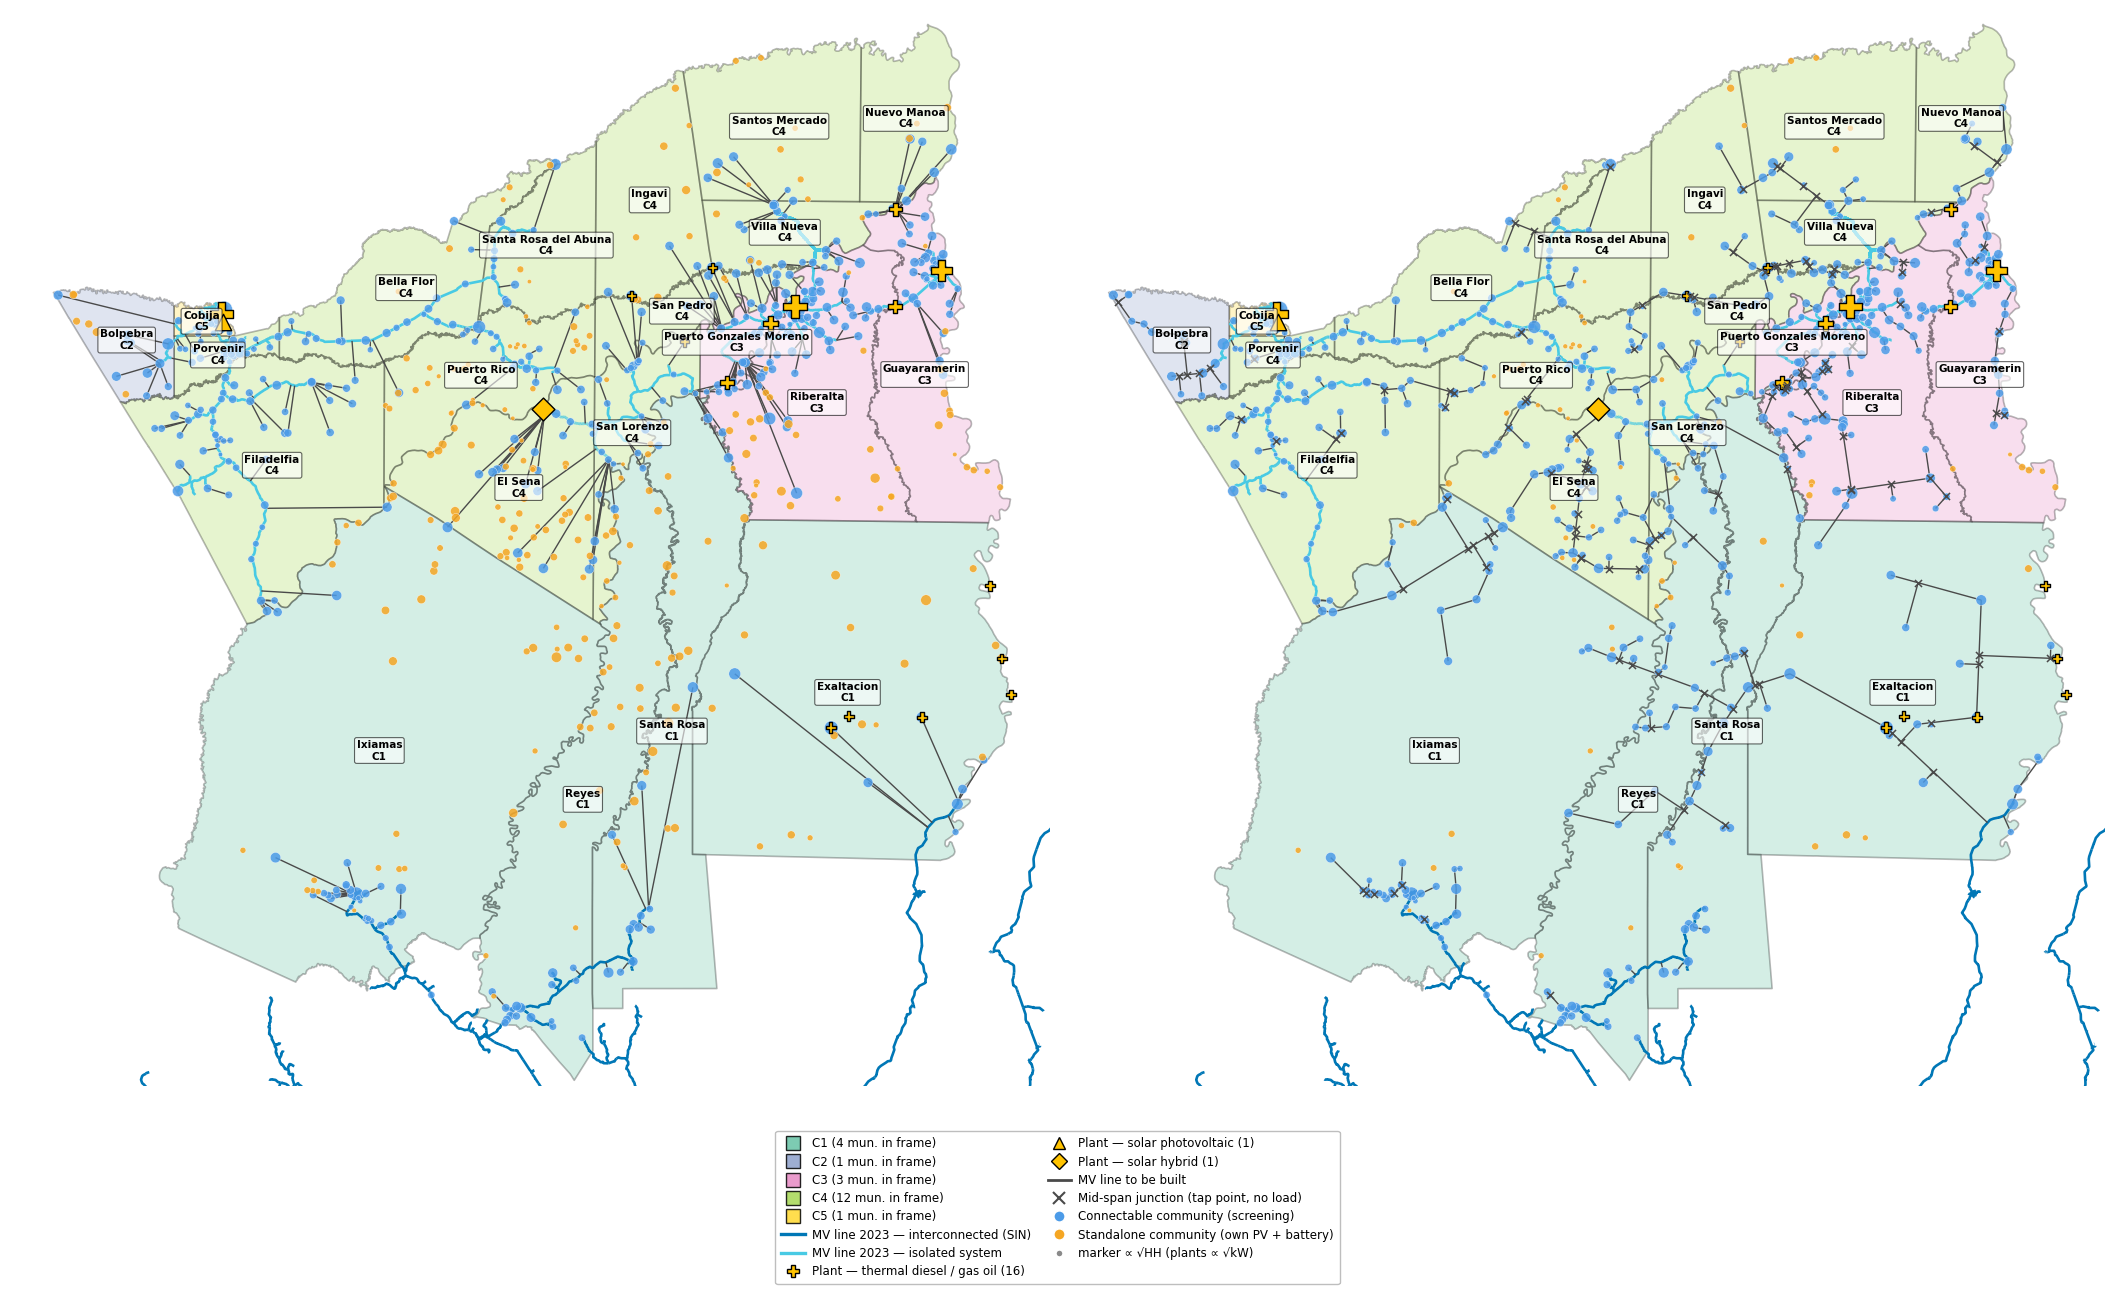

Figure A — 2024, two topologies over the same 697 communities. LEFT panel: independent breakeven screening, STAR topology. RIGHT panel: published greedy with definitive rejection and mid-span taps, TREE topology.
  star : 444 connectable, 253 standalone, 4,279.43 km over 444 edges, 4.17 M€/yr annualised
  tree : 626 connectable, 71 standalone, 3,947.91 km over 755 edges, 129 junctions, 3.99 M€/yr annualised


In [206]:
# -- Figure A: figure_A_2024_star_vs_greedy.png ----------------------------------------------
# Left panel: every connectable community runs its own spur to the network (independent breakeven
# screening). Right panel: the published tree, whose junction nodes are drawn as crosses. The two
# panels have different connectable counts, so the legend carries none — the caption reads them
# off the print below.
_y = "2024"
_ann_star = float(summary_breakeven[_y].set_index("Cluster").loc["TOTAL",
                                                                "extension_capex_star_annualise_EUR"])
_ann_tree = published_total(_y, "extension_capex_annualise_EUR")
_extent = content_extent(XY)
_legend_in = 2.0
_fig_h = 10.4 * (_extent[3] - _extent[2]) / (_extent[1] - _extent[0]) + _legend_in

_panels = [("star", conn_breakeven[_y], star_segments(conn_breakeven[_y]), star_km[_y],
            _ann_star, {}),
           ("tree", conn_greedy[_y], [edge_segment(e, tree_geom[_y]) for e in tree_greedy[_y]],
            km_greedy[_y], _ann_tree, junction_xy[_y])]

fig_a, axes = plt.subplots(1, 2, figsize=(21, _fig_h))
for ax, (_name, _conn, _segs, _km, _ann, _jxy) in zip(axes, _panels):
    draw_base(ax, extent=_extent)
    ax.add_collection(LineCollection(_segs, colors=C_EDGE, linewidths=1.0, zorder=2))
    draw_points(ax, _conn, hh_by_year[_y])
    draw_junctions(ax, _jxy)

fig_a.legend(handles=frame_legend(axes[1])
             + [Line2D([], [], color=C_EDGE, lw=2.0, label=L_EDGE),
                Line2D([], [], marker="x", ls="", ms=8, mec=C_JUNCTION, mew=1.5,
                       label=L_JUNCTION)]
             + status_handles(conn_greedy[_y], with_counts=False),
             loc="lower center", ncol=2, fontsize=8.5, **LEGEND_BOX)
fig_a.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=_legend_in / _fig_h, wspace=0.01)
save_fig(fig_a, "figure_A_2024_star_vs_greedy.png")
plt.show()

print(f"Figure A — {_y}, two topologies over the same 697 communities. LEFT panel: independent "
      f"breakeven screening, STAR topology. RIGHT panel: published greedy with definitive "
      f"rejection and mid-span taps, TREE topology.")
for _name, _conn, _segs, _km, _ann, _jxy in _panels:
    _jtxt = f", {len(_jxy)} junctions" if _jxy else ""
    print(f"  {_name:<5}: {int(_conn.sum())} connectable, {int((~_conn).sum())} standalone, "
          f"{_km:,.2f} km over {len(_segs)} edges{_jtxt}, {_ann / 1e6:.2f} M€/yr annualised")

  written: output\figures\figure_B_horizons_greedy.png
           3960 x 4647 px at 300 dpi, 2.22 MB


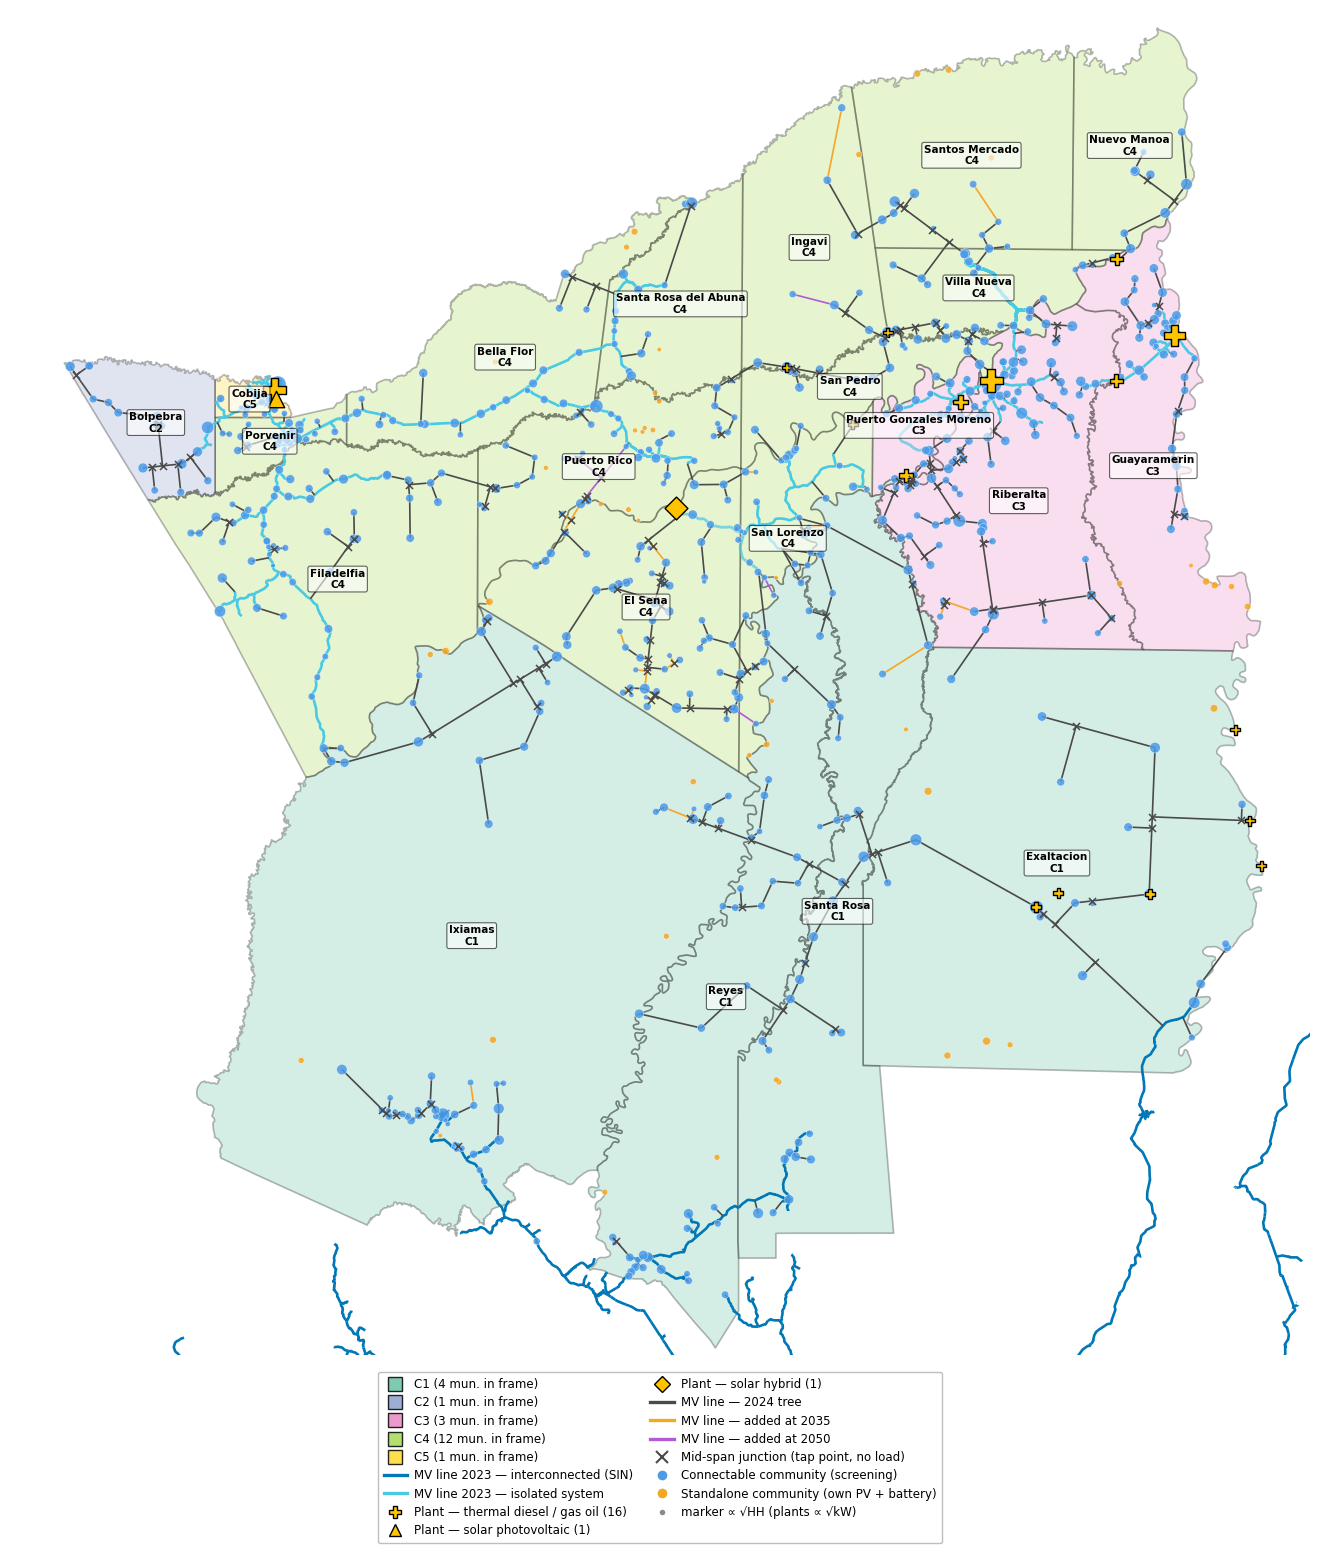

Figure B — one panel, the 2050 tree, every edge in the colour of the horizon it first appears in. The communities drawn are the 2050 classification.
  2024: 626 connectable, 71 standalone, 3,947.91 km of tree, 129 junctions, 3.99 M€/yr annualised; 747 of the 792 edges drawn first appear at this horizon
  2035: 645 connectable, 52 standalone, 4,095.38 km of tree, 139 junctions, 4.19 M€/yr annualised; 36 of the 792 edges drawn first appear at this horizon
  2050: 651 connectable, 46 standalone, 4,153.63 km of tree, 141 junctions, 4.32 M€/yr annualised; 9 of the 792 edges drawn first appear at this horizon
  8 edges of the earlier trees are absent from the 2050 tree and therefore from this panel — the trees are built independently per horizon, not nested


In [207]:
# -- Figure B: figure_B_horizons_greedy.png ---------------------------------------------------
# One panel, the 2050 tree, which contains every edge of the three horizons: the published trees
# are built independently per horizon and their edge sets are not nested, but each edge is drawn
# in the colour of the EARLIEST horizon that contains it, so antecedence is readable off the
# colours alone and the 2024 and 2035 panels add nothing.
# The 2024 tree is the same object as in figures A, C and G, so it keeps the neutral grey; orange
# and violet mark only what 2035 and 2050 add.
# Identity is GEOMETRIC (edge_geo_key), not by endpoint ids: junctions are numbered per run, so
# ("T", 7) of 2024 is not ("T", 7) of 2035, while the physical line is the same line.
# The panel is one horizon and the edges are three, so the legend carries no count.
edge_first_year, edge_segs = {}, {}
for _yy in EXT_YEARS:
    for e in tree_greedy[_yy]:
        _seg = edge_segment(e, tree_geom[_yy])
        _k = edge_geo_key(_seg)
        edge_first_year.setdefault(_k, _yy)
        edge_segs.setdefault((_yy, _k), _seg)

_y = EXT_YEARS[-1]
C_FIRST_SEEN = {EXT_YEARS[0]: C_EDGE, EXT_YEARS[1]: C_BY_YEAR[EXT_YEARS[1]],
                EXT_YEARS[2]: C_BY_YEAR[EXT_YEARS[2]]}
L_FIRST_SEEN = {EXT_YEARS[0]: f"MV line — {EXT_YEARS[0]} tree",
                EXT_YEARS[1]: f"MV line — added at {EXT_YEARS[1]}",
                EXT_YEARS[2]: f"MV line — added at {EXT_YEARS[2]}"}

_extent = content_extent(XY)
(_fw, _fh), _bot = fitted_figsize(_extent, 13.0, 1.9)
_keys = [edge_geo_key(edge_segment(e, tree_geom[_y])) for e in tree_greedy[_y]]
assert all(edge_first_year[_k] in EXT_YEARS for _k in _keys), "an edge has no horizon of origin"

fig_b, ax = plt.subplots(figsize=(_fw, _fh))
draw_base(ax, extent=_extent)
for _src in EXT_YEARS:
    _sub = [edge_segs[(_y, _k)] for _k in _keys if edge_first_year[_k] == _src]
    if _sub:
        ax.add_collection(LineCollection(_sub, colors=C_FIRST_SEEN[_src], linewidths=1.2,
                                         zorder=2))
draw_points(ax, conn_greedy[_y], hh_by_year[_y])
draw_junctions(ax, junction_xy[_y])

fig_b.legend(handles=frame_legend(ax)
             + [Line2D([], [], color=C_FIRST_SEEN[_yy], lw=2.4, label=L_FIRST_SEEN[_yy])
                for _yy in EXT_YEARS]
             + [Line2D([], [], marker="x", ls="", ms=8, mec=C_JUNCTION, mew=1.5,
                       label=L_JUNCTION)]
             + status_handles(conn_greedy[_y], with_counts=False),
             loc="lower center", ncol=2, fontsize=8.5, **LEGEND_BOX)
fig_b.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=_bot)
save_fig(fig_b, "figure_B_horizons_greedy.png")
plt.show()

print(f"Figure B — one panel, the {_y} tree, every edge in the colour of the horizon it first "
      f"appears in. The communities drawn are the {_y} classification.")
for _yy in EXT_YEARS:
    _new = sum(1 for _k in _keys if edge_first_year[_k] == _yy)
    print(f"  {_yy}: {int(conn_greedy[_yy].sum())} connectable, "
          f"{int((~conn_greedy[_yy]).sum())} standalone, {km_greedy[_yy]:,.2f} km of tree, "
          f"{len(junction_xy[_yy])} junctions, "
          f"{published_total(_yy, 'extension_capex_annualise_EUR') / 1e6:.2f} M€/yr annualised; "
          f"{_new} of the {len(_keys)} edges drawn first appear at this horizon")
_lost = [_k for _k in edge_first_year if _k not in set(_keys)]
print(f"  {len(_lost)} edges of the earlier trees are absent from the {_y} tree and therefore "
      f"from this panel — the trees are built independently per horizon, not nested")

  written: output\figures\figure_C_C1_shared_trunk.png
           3960 x 3821 px at 300 dpi, 1.30 MB


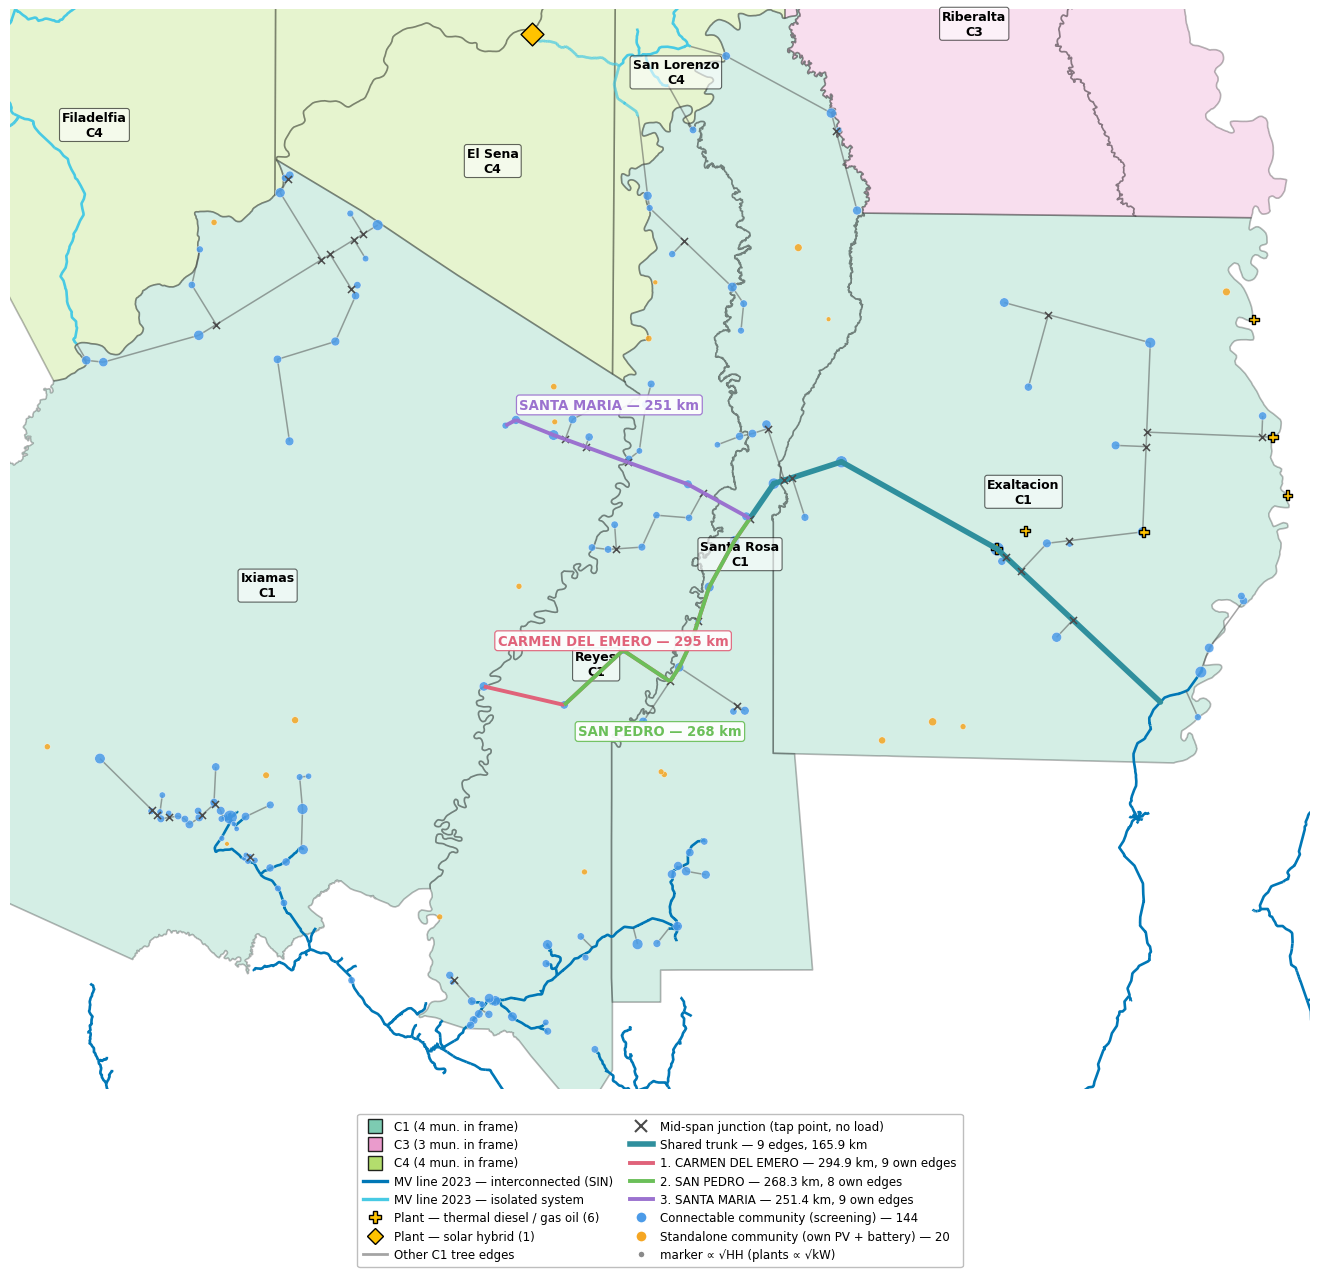

Figure C — cluster C1, published tree 2024: 1,471 km of 3,948 km, 13.37 M€ (36 % of the tree capex); 144 connectable, 20 standalone, 180 edges, 36 junctions; shared trunk 9 edges, 165.85 km
  frame: 418 x 347 km on the drawn content, against 444 x 369 km on the cluster layer (12 % of the area cropped)
  strokes: trunk 4.0, paths 2.8 (ratio 1.43, max 1.5)
  1. CARMEN DEL EMERO          294.86 km over 18 edges,  9 of its own, direct perpendicular  78.03 km
  2. SAN PEDRO                 268.34 km over 17 edges,  8 of its own, direct perpendicular  61.14 km
  3. SANTA MARIA               251.45 km over 18 edges,  9 of its own, direct perpendicular 108.16 km


In [ ]:
# -- Figure C: figure_C_C1_shared_trunk.png ---------------------------------------------------
# The figure that shows the method: three communities far from the network do not each pay their own spur, they pay the branch beyond a shared trunk. The trunk common to all three paths is
# drawn in its own colour, and only the diverging segments carry the per-community colour, so the sharing is directly readable. A path may run through junctions: those are tap points on a
# line already in the tree, and they carry no load of their own.
# The frame is the bounding box of what this figure DRAWS — the C1 communities and the C1 tree edges — not of the whole cluster layer, so no band of the picture carries only out-of-scope
# network. No title: the caption carries it.
_y = "2024"
_c1 = (CL_ARR == "C1")
_par = tree_parents(tree_greedy[_y])
_edges_c1 = {e: w for e, w in tree_greedy[_y].items() if tree_geom[_y][e][2] == "C1"}

_paths = {n: path_edges_to_root(n, _par) for n in _par if is_community(n) and _c1[n]}
_tops = sorted(_paths, key=lambda n: -_paths[n][1])[:3]
_trunk = set.intersection(*(set(_paths[n][0]) for n in _tops))   # section 8 checks this set
_trunk_km = sum(tree_greedy[_y][e] for e in _trunk)

_drawn = np.vstack([XY[_c1]] + [np.array(edge_segment(e, tree_geom[_y])) for e in _edges_c1])
_extent_c = content_extent(_drawn, margin_m=12_000)
_extent_old = content_extent(XY[_c1])
(_fw, _fh), _bot = fitted_figsize(_extent_c, 13.0, 1.8)

fig_c, ax = plt.subplots(figsize=(_fw, _fh))
draw_base(ax, sub=_c1, label_fs=9, extent=_extent_c)
ax.add_collection(LineCollection([edge_segment(e, tree_geom[_y]) for e in _edges_c1],
                                 colors=C_EDGE, linewidths=1.1, alpha=0.5, zorder=2))
draw_points(ax, conn_greedy[_y], hh_by_year[_y], sub=_c1)
_n_junc_c1 = draw_junctions(ax, junction_xy[_y], sub_cluster="C1", geom=tree_geom[_y])

# Shared trunk first, then only what each path adds beyond it.
ax.add_collection(LineCollection([edge_segment(e, tree_geom[_y]) for e in _trunk],
                                 colors=C_TRUNK, linewidths=TRUNK_LW, zorder=4, capstyle="round"))
_path_h = [Line2D([], [], color=C_TRUNK, lw=TRUNK_LW,
                  label=f"Shared trunk — {len(_trunk)} edges, {_trunk_km:,.1f} km")]
for _rank, (_n, _col) in enumerate(zip(_tops, C_PATHS), 1):
    _edges, _len = _paths[_n]
    _own = [e for e in _edges if e not in _trunk]
    ax.add_collection(LineCollection([edge_segment(e, tree_geom[_y]) for e in _own],
                                     colors=_col, linewidths=PATH_LW, zorder=5))
    # The community name on the map, in the path colour, is the second encoding that keeps the
    # three paths tellable apart under deuteranopia. The offsets are staggered because the three
    # deepest paths end close together.
    _off = [(10, 30), (10, -22), (10, 12)][_rank - 1]
    ax.annotate(f"{task1_geo['Comunidad'].iloc[_n]} — {_len:,.0f} km",
                (XY[_n, 0], XY[_n, 1]), xytext=_off, textcoords="offset points",
                fontsize=9.5, weight="bold", color=_col, zorder=6,
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=_col, linewidth=0.9,
                          alpha=0.92))
    _path_h.append(Line2D([], [], color=_col, lw=PATH_LW, label=(
        f"{_rank}. {task1_geo['Comunidad'].iloc[_n]} — {_len:,.1f} km, {len(_own)} own edges")))

fig_c.legend(handles=frame_legend(ax)
             + [Line2D([], [], color=C_EDGE, lw=2.0, alpha=0.5, label="Other C1 tree edges"),
                Line2D([], [], marker="x", ls="", ms=8, mec=C_JUNCTION, mew=1.5,
                       label=L_JUNCTION)]
             + _path_h + status_handles(conn_greedy[_y], sub=_c1),
             loc="lower center", ncol=2, fontsize=8.5, **LEGEND_BOX)
fig_c.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=_bot)
save_fig(fig_c, "figure_C_C1_shared_trunk.png")
plt.show()

_cap_c1 = published_total(_y, "extension_capex_EUR")   # TOTAL row; the C1 row is read below
_c1_capex = float(pd.read_csv(os.path.join(OUT, _y, "cluster_summary.csv"))
                  .set_index("Cluster").loc["C1", "extension_capex_EUR"])
print(f"Figure C — cluster C1, published tree {_y}: {km_greedy_cluster[_y]['C1']:,.0f} km of "
      f"{km_greedy[_y]:,.0f} km, {_c1_capex / 1e6:.2f} M€ "
      f"({100 * _c1_capex / _cap_c1:.0f} % of the tree capex); "
      f"{int(conn_greedy[_y][_c1].sum())} connectable, {int((~conn_greedy[_y][_c1]).sum())} "
      f"standalone, {len(_edges_c1)} edges, {_n_junc_c1} junctions; shared trunk "
      f"{len(_trunk)} edges, {_trunk_km:,.2f} km")
print(f"  frame: {(_extent_c[1] - _extent_c[0]) / 1000:,.0f} x "
      f"{(_extent_c[3] - _extent_c[2]) / 1000:,.0f} km on the drawn content, against "
      f"{(_extent_old[1] - _extent_old[0]) / 1000:,.0f} x "
      f"{(_extent_old[3] - _extent_old[2]) / 1000:,.0f} km on the cluster layer "
      f"({100 * (1 - ((_extent_c[1] - _extent_c[0]) * (_extent_c[3] - _extent_c[2]))
                / ((_extent_old[1] - _extent_old[0]) * (_extent_old[3] - _extent_old[2]))):.0f} "
      f"% of the area cropped)")
print(f"  strokes: trunk {TRUNK_LW}, paths {PATH_LW} (ratio {TRUNK_LW / PATH_LW:.2f}, max 1.5)")
for _rank, _n in enumerate(_tops, 1):
    _edges, _len = _paths[_n]
    print(f"  {_rank}. {task1_geo['Comunidad'].iloc[_n]:<24} {_len:>7,.2f} km over "
          f"{len(_edges):>2} edges, {len([e for e in _edges if e not in _trunk]):>2} of its own, "
          f"direct perpendicular {D_GRID[_n]:>6,.2f} km")

  written: output\figures\figure_D_capex_breakdown.png
           2700 x 2052 px at 300 dpi, 0.17 MB


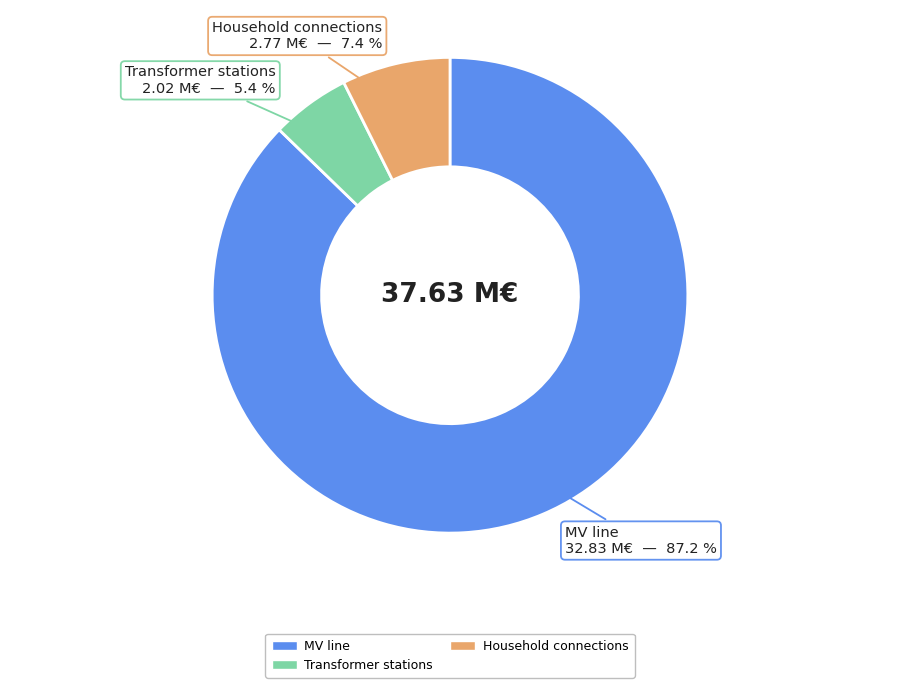

Figure D — output/2024/cluster_summary.csv, row TOTAL:
  MV line                extension_capex_ligne_EUR               32.83 M€    87.2 %
  Transformer stations   extension_capex_transformateur_EUR       2.02 M€     5.4 %
  Household connections  extension_capex_raccordement_EUR         2.77 M€     7.4 %
  TOTAL                  extension_capex_EUR                     37.63 M€   100.0 %


In [209]:
# -- Figure D: figure_D_capex_breakdown.png ---------------------------------------------------
# The 2024 capex of the published tree, split into its three posts. Every value is read from the
# TOTAL row of output/2024/cluster_summary.csv; nothing is recomputed. No title: the caption
# carries it. The post NAME stays in each callout on purpose — it is the second encoding that
# keeps the two pale wedges tellable apart for a protanope.
_posts = [("MV line", "extension_capex_ligne_EUR"),
          ("Transformer stations", "extension_capex_transformateur_EUR"),
          ("Household connections", "extension_capex_raccordement_EUR")]
_vals = np.array([published_total("2024", _col) for _, _col in _posts])
_total = published_total("2024", "extension_capex_EUR")
assert abs(_vals.sum() - _total) <= 1.0, \
    f"the three posts sum to {_vals.sum():,.0f} EUR, extension_capex_EUR says {_total:,.0f}"
_shares = 100.0 * _vals / _vals.sum()

fig_d, ax = plt.subplots(figsize=(10, 7.0))
_wedges, _ = ax.pie(_vals, colors=[C_CAPEX[lab] for lab, _ in _posts], startangle=90,
                    counterclock=False,
                    wedgeprops=dict(width=0.46, edgecolor="white", linewidth=2.0))
ax.set_aspect("equal")
for _w, (_lab, _), _v, _s in zip(_wedges, _posts, _vals, _shares):
    _ang = np.deg2rad((_w.theta1 + _w.theta2) / 2.0)
    _x, _yy = np.cos(_ang), np.sin(_ang)
    ax.annotate(f"{_lab}\n{_v / 1e6:.2f} M€  —  {_s:.1f} %",
                xy=(0.80 * _x, 0.80 * _yy), xytext=(1.24 * _x, 1.12 * _yy),
                ha="left" if _x >= 0 else "right", va="center", fontsize=10.5, color="#222222",
                bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=C_CAPEX[_lab], linewidth=1.3,
                          alpha=0.95),
                arrowprops=dict(arrowstyle="-", color=C_CAPEX[_lab], linewidth=1.3))
ax.text(0, 0, f"{_total / 1e6:.2f} M€", ha="center", va="center", fontsize=19, weight="bold",
        color="#222222")
# Equal aspect with an explicit data box: the axes box takes the box ratio, so the slack ends up
# left and right of the donut instead of as a band of white above the legend.
ax.set_xlim(-1.85, 1.85)
ax.set_ylim(-1.20, 1.20)

fig_d.legend(handles=[Patch(facecolor=C_CAPEX[lab], edgecolor="white", label=lab)
                      for lab, _ in _posts],
             loc="lower center", ncol=2, fontsize=9, **LEGEND_BOX)
fig_d.subplots_adjust(left=0.06, right=0.94, top=0.99, bottom=0.11)
save_fig(fig_d, "figure_D_capex_breakdown.png")
plt.show()

print("Figure D — output/2024/cluster_summary.csv, row TOTAL:")
for (_lab, _col), _v, _s in zip(_posts, _vals, _shares):
    print(f"  {_lab:<22} {_col:<38} {_v / 1e6:>6.2f} M€   {_s:>5.1f} %")
print(f"  {'TOTAL':<22} {'extension_capex_EUR':<38} {_total / 1e6:>6.2f} M€   100.0 %")

  written: output\figures\figure_E_breakeven_scatter.png
           3440 x 2168 px at 300 dpi, 0.50 MB


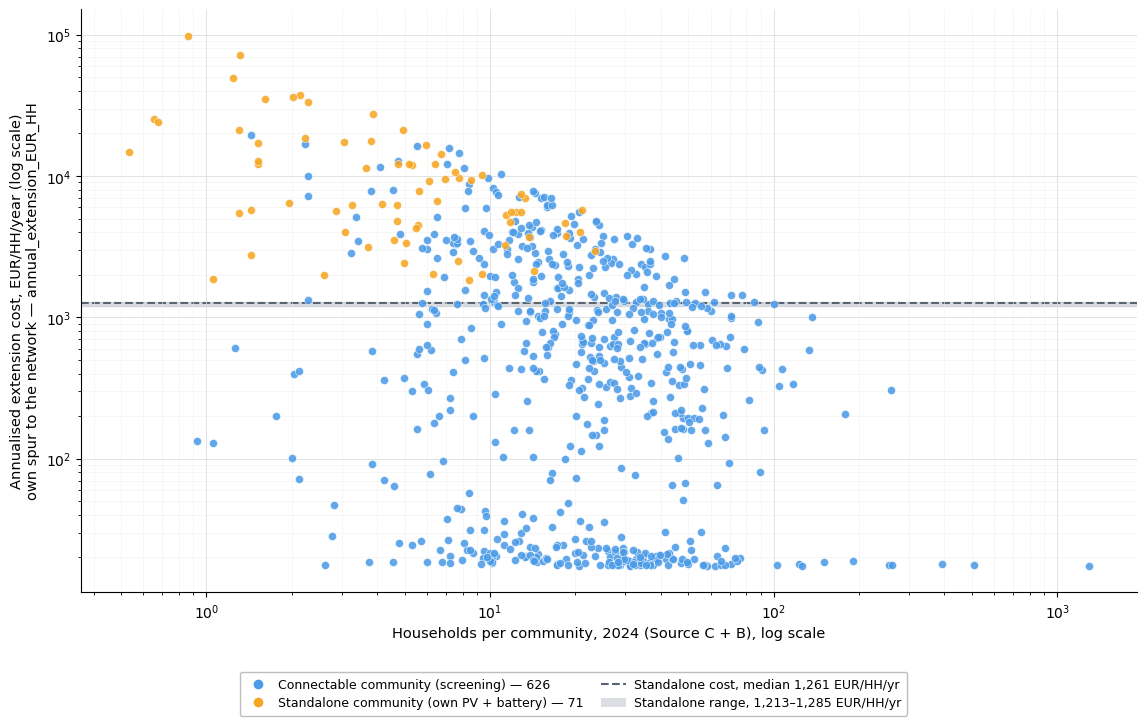

Figure E — 2024 published classification: 697 communities, 626 connectable, 71 standalone; standalone cost 1,212.80–1,284.99 EUR/HH/yr (21 municipal values), median 1,260.89
  182 connectable communities plot above their own standalone cost — the shared-trunk effect, not an inconsistency


In [210]:
# -- Figure E: figure_E_breakeven_scatter.png -------------------------------------------------
# One point per community, read from output/2024/community_detail.csv. The colour is the
# PUBLISHED status (greedy with taps); the y value is annual_extension_EUR_HH, which the CSV
# defines on the community's OWN spur to the network. The outputs carry no per-community cost on
# the published tree — only km_arete_parent_glouton, a length — so none is computed here. That is
# why 182 connectable communities plot above their own standalone cost: they attach to a shared
# trunk and never pay that spur. No title: the caption carries it.
_d = pd.read_csv(os.path.join(OUT, "2024", "community_detail.csv"))
assert int((~_d["dispersed"]).sum()) == int(published_total("2024", "N_connectable")), \
    "community_detail disagrees with cluster_summary on N_connectable"
_disp = _d["dispersed"].astype(bool).to_numpy()
_hh, _ext = _d["HH"].to_numpy(), _d["annual_extension_EUR_HH"].to_numpy()
_sa = _d["annual_standalone_EUR_HH"].to_numpy()
_lo, _hi, _med = _sa.min(), _sa.max(), float(np.median(_sa))

fig_e, ax = plt.subplots(figsize=(12, 7.2))
ax.axhspan(_lo, _hi, color="#9AA3AD", alpha=0.35, zorder=1)
ax.axhline(_med, color="#5A6470", lw=1.5, ls="--", zorder=1.5)
for _m, _col in ((~_disp, C_CONN), (_disp, C_DISP)):
    ax.scatter(_hh[_m], _ext[_m], s=34, c=_col, alpha=0.88, edgecolor="white", linewidth=0.4,
               zorder=3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Households per community, 2024 (Source C + B), log scale", fontsize=10.5)
# Kept to two short lines: a longer label runs past the axes height and gets clipped.
ax.set_ylabel("Annualised extension cost, EUR/HH/year (log scale)\n"
              "own spur to the network — annual_extension_EUR_HH", fontsize=10.5)
ax.grid(True, which="major", color="#DDDDDD", lw=0.6, zorder=0)
ax.grid(True, which="minor", color="#F0F0F0", lw=0.4, zorder=0)
for _s in ("top", "right"):
    ax.spines[_s].set_visible(False)

fig_e.legend(handles=[
    Line2D([], [], marker="o", ls="", ms=8, mfc=C_CONN, mec="white",
           label=f"{L_CONN} — {int((~_disp).sum())}"),
    Line2D([], [], marker="o", ls="", ms=8, mfc=C_DISP, mec="white",
           label=f"{L_DISP} — {int(_disp.sum())}"),
    Line2D([], [], color="#5A6470", lw=1.5, ls="--",
           label=f"Standalone cost, median {_med:,.0f} EUR/HH/yr"),
    Patch(facecolor="#9AA3AD", alpha=0.35,
          label=f"Standalone range, {_lo:,.0f}–{_hi:,.0f} EUR/HH/yr"),
], loc="lower center", ncol=2, fontsize=9, **LEGEND_BOX)
fig_e.subplots_adjust(left=0.095, right=0.975, top=0.985, bottom=0.175)
save_fig(fig_e, "figure_E_breakeven_scatter.png")
plt.show()

print(f"Figure E — 2024 published classification: {len(_d)} communities, "
      f"{int((~_disp).sum())} connectable, {int(_disp.sum())} standalone; standalone cost "
      f"{_lo:,.2f}–{_hi:,.2f} EUR/HH/yr ({_d['annual_standalone_EUR_HH'].nunique()} municipal "
      f"values), median {_med:,.2f}")
print(f"  {int(((~_disp) & (_ext > _sa)).sum())} connectable communities plot above their own "
      f"standalone cost — the shared-trunk effect, not an inconsistency")

  written: output\figures\figure_F_km_par_cluster.png
           3461 x 2108 px at 300 dpi, 0.13 MB


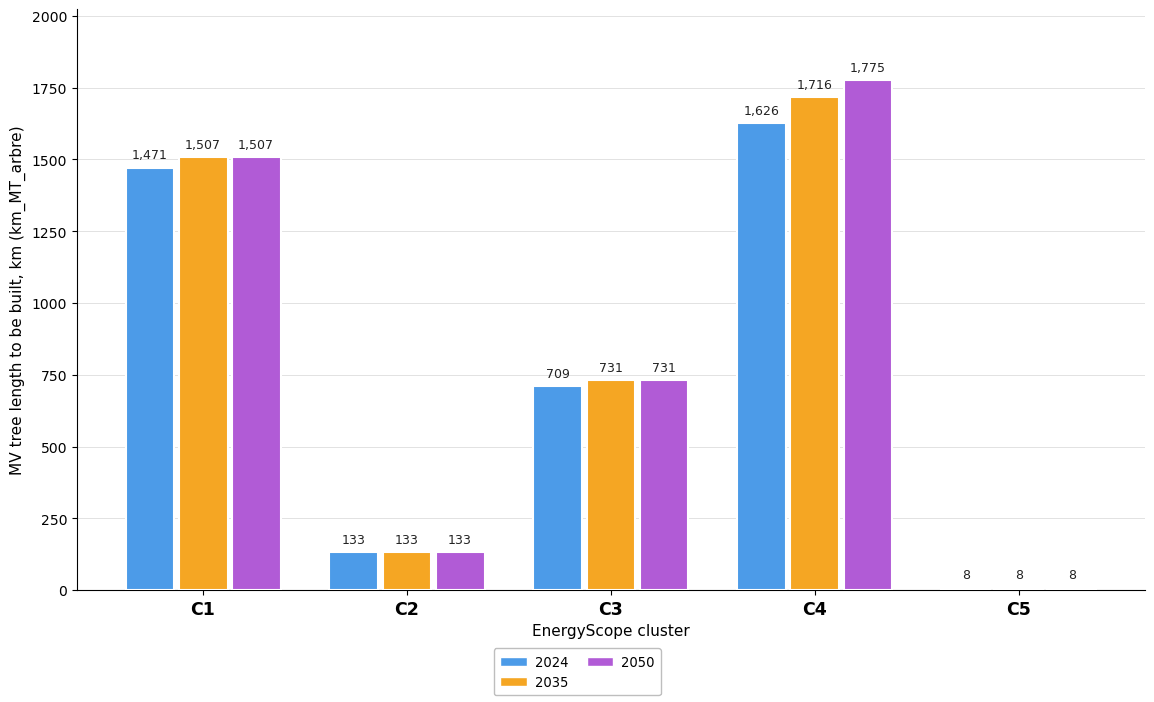

Figure F — km_MT_arbre per cluster, read from the three cluster_summary.csv:
       2024     2035     2050
C1  1471.36  1507.41  1507.41
C2   132.90   132.90   132.90
C3   709.36   730.52   730.52
C4  1626.10  1716.36  1774.61
C5     8.19     8.19     8.19
  region total: 2024 3,947.91 km, 2035 4,095.38 km, 2050 4,153.63 km


In [211]:
# -- Figure F: figure_F_km_par_cluster.png ----------------------------------------------------
# km_MT_arbre per cluster and horizon, read from the three cluster_summary.csv. No title: the
# caption carries it. Every bar carries its value in a fixed left-to-right order, which is the
# second encoding for the 2024 / 2050 pair — the palette check puts it below the normal-vision
# floor.
_km = pd.DataFrame({_y: [float(pd.read_csv(os.path.join(OUT, _y, "cluster_summary.csv"))
                               .set_index("Cluster").loc[_c, "km_MT_arbre"])
                         for _c in CLUSTERS] for _y in EXT_YEARS}, index=list(CLUSTERS))
_tot_km = {_y: published_total(_y, "km_MT_arbre") for _y in EXT_YEARS}
for _y in EXT_YEARS:
    assert abs(_km[_y].sum() - _tot_km[_y]) <= 0.01, f"{_y}: cluster rows do not sum to TOTAL"

fig_f, ax = plt.subplots(figsize=(12, 7))
_x = np.arange(len(CLUSTERS))
_w = 0.26
for _k, _y in enumerate(EXT_YEARS):
    _pos = _x + (_k - 1) * _w
    ax.bar(_pos, _km[_y].to_numpy(), width=_w - 0.02, color=C_BY_YEAR[_y], edgecolor="white",
           linewidth=1.5, zorder=3)
    for _xi, _v in zip(_pos, _km[_y].to_numpy()):
        ax.text(_xi, _v + 22, f"{_v:,.0f}", ha="center", va="bottom", fontsize=9,
                color="#222222", zorder=4)
ax.set_xticks(_x)
ax.set_xticklabels(list(CLUSTERS), fontsize=12.5, fontweight="bold")
ax.set_ylabel("MV tree length to be built, km (km_MT_arbre)", fontsize=11)
ax.set_xlabel("EnergyScope cluster", fontsize=11)
ax.set_ylim(0, _km.to_numpy().max() * 1.14)
ax.grid(True, axis="y", color="#DDDDDD", lw=0.6, zorder=0)
ax.set_axisbelow(True)
for _s in ("top", "right"):
    ax.spines[_s].set_visible(False)

fig_f.legend(handles=[Patch(facecolor=C_BY_YEAR[_y], edgecolor="white", label=_y)
                      for _y in EXT_YEARS],
             loc="lower center", ncol=2, fontsize=9.5, **LEGEND_BOX)
fig_f.subplots_adjust(left=0.085, right=0.975, top=0.985, bottom=0.155)
save_fig(fig_f, "figure_F_km_par_cluster.png")
plt.show()

print("Figure F — km_MT_arbre per cluster, read from the three cluster_summary.csv:")
print(_km.to_string())
print("  region total: " + ", ".join(f"{_y} {_tot_km[_y]:,.2f} km" for _y in EXT_YEARS))

  written: output\figures\figure_G_2024_map.png
           3960 x 4647 px at 300 dpi, 2.19 MB


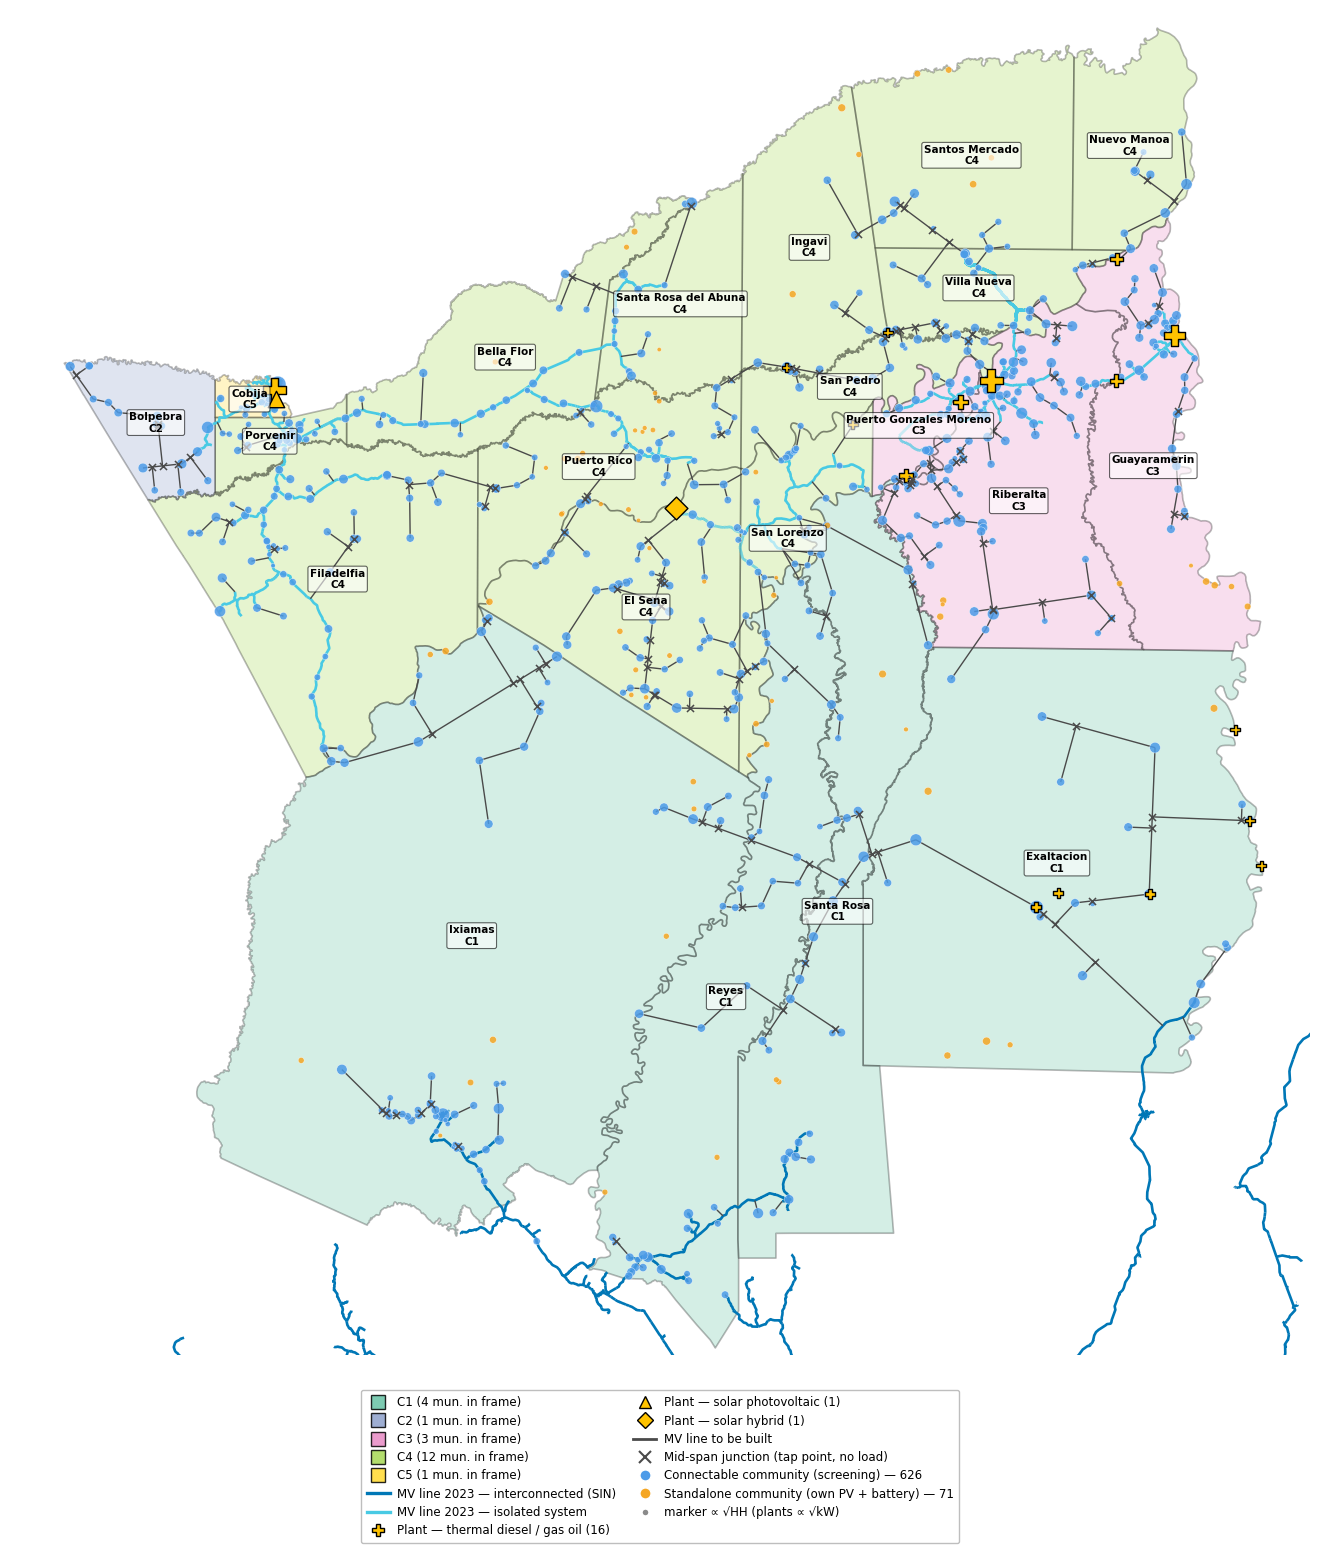

Figure G — 2024, published classification (greedy with definitive rejection and mid-span taps): 626 connectable, 71 standalone, 3,947.91 km of MV tree over 755 edges and 129 junctions, 3.99 M€/yr annualised


In [212]:
# -- Figure G: figure_G_2024_map.png ----------------------------------------------------------
# The right panel of figure A, alone and without a title: the published 2024 tree over the whole
# region. The caption carries the numbers printed below.
_y = "2024"
_ann_tree = published_total(_y, "extension_capex_annualise_EUR")
assert int(conn_greedy[_y].sum()) == int(published_total(_y, "N_connectable")), "N_connectable drift"
assert len(junction_xy[_y]) == int(published_total(_y, "N_jonctions")), "junction count drift"
assert abs(round(km_greedy[_y], 2) - published_total(_y, "km_MT_arbre")) < 0.005, "km drift"

_extent = content_extent(XY)
(_fw, _fh), _bot = fitted_figsize(_extent, 13.0, 1.9)
_segs = [edge_segment(e, tree_geom[_y]) for e in tree_greedy[_y]]

fig_g, ax = plt.subplots(figsize=(_fw, _fh))
draw_base(ax, extent=_extent)
ax.add_collection(LineCollection(_segs, colors=C_EDGE, linewidths=1.0, zorder=2))
draw_points(ax, conn_greedy[_y], hh_by_year[_y])
draw_junctions(ax, junction_xy[_y])
fig_g.legend(handles=frame_legend(ax)
             + [Line2D([], [], color=C_EDGE, lw=2.0, label=L_EDGE),
                Line2D([], [], marker="x", ls="", ms=8, mec=C_JUNCTION, mew=1.5,
                       label=L_JUNCTION)]
             + status_handles(conn_greedy[_y]),
             loc="lower center", ncol=2, fontsize=8.5, **LEGEND_BOX)
fig_g.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=_bot)
save_fig(fig_g, "figure_G_2024_map.png")
plt.show()

print(f"Figure G — {_y}, published classification (greedy with definitive rejection and mid-span "
      f"taps): {int(conn_greedy[_y].sum())} connectable, {int((~conn_greedy[_y]).sum())} "
      f"standalone, {km_greedy[_y]:,.2f} km of MV tree over {len(_segs)} edges and "
      f"{len(junction_xy[_y])} junctions, {_ann_tree / 1e6:.2f} M€/yr annualised")

## 7. Control

The published numbers, re-read from the files on disk, checked against the expected constants.

In [213]:
# Control values of the published run. A change here means the published CSVs moved.
N_CONNECTABLE_EXPECTED = {"2024": 626, "2035": 645, "2050": 651}
N_DISPERSED_EXPECTED = {"2024": 71, "2035": 52, "2050": 46}
KM_TREE_EXPECTED = {"2024": 3_947.91, "2035": 4_095.38, "2050": 4_153.63}
CAPEX_EXPECTED_EUR = {"2024": 37_628_923, "2035": 39_535_168, "2050": 40_679_823}
CAPEX_ANNUALISE_EXPECTED_EUR = {"2024": 3_991_648, "2035": 4_193_861, "2050": 4_315_285}
N_JONCTIONS_EXPECTED = {"2024": 129, "2035": 139, "2050": 141}
N_NODE_ONLY_EXPECTED = {"2024": 614, "2035": 632, "2050": 640}      # _glouton_noeud_seul
N_BREAKEVEN_EXPECTED = {"2024": 444, "2035": 473, "2050": 491}      # _breakeven_independant

_conn_from_csv = {}
for year in EXT_YEARS:
    _tot = pd.read_csv(os.path.join(OUT, year, "cluster_summary.csv")).set_index("Cluster").loc["TOTAL"]
    _n, _capex = int(_tot["N_connectable"]), float(_tot["extension_capex_EUR"])
    assert _n == N_CONNECTABLE_EXPECTED[year], \
        f"{year}: N_connectable = {_n}, expected {N_CONNECTABLE_EXPECTED[year]}"
    assert int(_tot["N_dispersed"]) == N_DISPERSED_EXPECTED[year], \
        f"{year}: N_dispersed = {int(_tot['N_dispersed'])}, expected {N_DISPERSED_EXPECTED[year]}"
    assert abs(float(_tot["km_MT_arbre"]) - KM_TREE_EXPECTED[year]) <= 0.01, \
        f"{year}: tree = {_tot['km_MT_arbre']:,.2f} km, expected {KM_TREE_EXPECTED[year]:,.2f} km"
    assert abs(_capex - CAPEX_EXPECTED_EUR[year]) <= 1.0, \
        f"{year}: capex = {_capex:,.0f} EUR, expected {CAPEX_EXPECTED_EUR[year]:,} EUR"
    assert abs(float(_tot["extension_capex_annualise_EUR"])
               - CAPEX_ANNUALISE_EXPECTED_EUR[year]) <= 1.0, \
        f"{year}: annualised capex = {_tot['extension_capex_annualise_EUR']:,.0f} EUR, " \
        f"expected {CAPEX_ANNUALISE_EXPECTED_EUR[year]:,} EUR"
    assert int(_tot["N_jonctions"]) == N_JONCTIONS_EXPECTED[year], \
        f"{year}: {int(_tot['N_jonctions'])} junctions, expected {N_JONCTIONS_EXPECTED[year]}"
    # One transformer per connected community. The tree has N_connectable + N_jonctions edges, so
    # pricing a transformer per edge would overstate the post by the junction count.
    assert abs(float(_tot["extension_capex_transformateur_EUR"]) - _n * TRAFO_EUR) <= 1.0, \
        f"{year}: transformer post != N_connectable x TRAFO_EUR"
    assert float(_tot["extension_capex_transformateur_EUR"]) \
        != (_n + int(_tot["N_jonctions"])) * TRAFO_EUR, \
        f"{year}: transformer post priced on the edge count"
    assert int(_tot["N_connectable" + SUFFIX_NODE]) == N_NODE_ONLY_EXPECTED[year], \
        f"{year}: node-only greedy N_connectable != {N_NODE_ONLY_EXPECTED[year]}"
    assert int(_tot["N_connectable" + SUFFIX_OLD]) == N_BREAKEVEN_EXPECTED[year], \
        f"{year}: independent-breakeven N_connectable != {N_BREAKEVEN_EXPECTED[year]}"

    _det = pd.read_csv(os.path.join(OUT, year, "community_detail.csv"))
    assert int((~_det["dispersed"]).sum()) == N_CONNECTABLE_EXPECTED[year], \
        f"{year}: community_detail disagrees with cluster_summary on N_connectable"
    _conn_from_csv[year] = ~_det["dispersed"].to_numpy()
    print(f"{year}  N_connectable {_n} == {N_CONNECTABLE_EXPECTED[year]}   |   "
          f"N_dispersed {int(_tot['N_dispersed'])}   |   "
          f"capex {_capex:>12,.0f} == {CAPEX_EXPECTED_EUR[year]:>12,} EUR   |   "
          f"tree {_tot['km_MT_arbre']:>8,.2f} km   |   {int(_tot['N_jonctions']):>3} junctions   |   "
          f"annualised {_tot['extension_capex_annualise_EUR'] / 1e6:.2f} M€/yr")

# Nesting, re-read from the CSVs rather than from memory.
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    _lost = int((_conn_from_csv[_a] & ~_conn_from_csv[_b]).sum())
    assert _lost == 0, f"nesting broken between {_a} and {_b}: {_lost} community dropped out"
print(f"nesting {' - '.join(EXT_YEARS)} holds in the written CSVs -> OK")

# The two annualisation conventions side by side. The CSVs carry CRF_MV alone; the classification
# that decided connectable vs standalone annualised at CRF_MV + OM_RATE. The gap is the O&M the
# published annualised capex does not show.
print()
print(f"annualisation: published CRF_MV = {CRF_MV:.8f}   vs   classification "
      f"CRF_MV + OM_RATE = {CRF_MV + OM_RATE:.8f}")
_rows = []
for year in EXT_YEARS:
    _cap = capex_posts(km_greedy[year], int(conn_greedy[year].sum()),
                       float(hh_by_year[year][conn_greedy[year]].sum()))
    _pub = float(pd.read_csv(os.path.join(OUT, year, "cluster_summary.csv"))
                 .set_index("Cluster").loc["TOTAL", "extension_capex_annualise_EUR"])
    assert abs(_cap["total_annualise_EUR"] - _pub) <= 1.0, f"{year}: annualised capex moved"
    _rows.append({
        "annee": year,
        "capex_EUR": round(_cap["total_EUR"], 0),
        "annualise_publie_EUR": round(_cap["total_annualise_EUR"], 0),
        "annualise_avec_om_EUR": round(_cap["total_annualise_avec_om_EUR"], 0),
        "ecart_EUR": round(_cap["total_annualise_avec_om_EUR"] - _cap["total_annualise_EUR"], 0),
        "ecart_%": round(100 * (_cap["total_annualise_avec_om_EUR"]
                                / _cap["total_annualise_EUR"] - 1), 2),
    })
print(pd.DataFrame(_rows).to_string(index=False))

_sd = pd.read_csv(os.path.join(OUT, "share_dispersion_final_BC.csv"))
assert int(_sd["N_connectable"].sum()) == N_CONNECTABLE_EXPECTED["2024"]
print()
print("output/share_dispersion_final_BC.csv")
print(_sd.to_string(index=False))
print()
print("--- demande_dispersee_GWh per cluster and horizon, published topology (the target)")
print(pd.DataFrame({_y: summary_greedy[_y].set_index("Cluster")["demande_dispersee_GWh"]
                    for _y in EXT_YEARS}).to_string())
print()
print("ALL CONTROLS PASSED — published files reproduce the expected values")

2024  N_connectable 626 == 626   |   N_dispersed 71   |   capex   37,628,923 ==   37,628,923 EUR   |   tree 3,947.91 km   |   129 junctions   |   annualised 3.99 M€/yr
2035  N_connectable 645 == 645   |   N_dispersed 52   |   capex   39,535,167 ==   39,535,168 EUR   |   tree 4,095.38 km   |   139 junctions   |   annualised 4.19 M€/yr
2050  N_connectable 651 == 651   |   N_dispersed 46   |   capex   40,679,822 ==   40,679,823 EUR   |   tree 4,153.63 km   |   141 junctions   |   annualised 4.32 M€/yr
nesting 2024 - 2035 - 2050 holds in the written CSVs -> OK

annualisation: published CRF_MV = 0.10607925   vs   classification CRF_MV + OM_RATE = 0.12607925
annee  capex_EUR  annualise_publie_EUR  annualise_avec_om_EUR  ecart_EUR  ecart_%
 2024 37628923.0             3991648.0              4744226.0   752578.0    18.85
 2035 39535168.0             4193861.0              4984564.0   790703.0    18.85
 2050 40679823.0             4315285.0              5128881.0   813596.0    18.85

output/sha

## 8. Diagnostic — households downstream of each tree edge

Read-only. Nothing is written and no published number moves. This section measures a quantity
the cost model deliberately ignores: **how many households sit downstream of each edge** of the
published greedy tree.

The tree is priced at a single `MV_EUR = 8 316 EUR/km` for every edge, whatever it carries — one
33 kV conductor size, from the trunk that feeds a whole branch down to the last spur serving a
single community. That is the assumption the limitations section has to bound, and the number
below is what bounds it: the most loaded edge of the tree is where a uniform conductor is least
defensible. **This figure enters no cost**; `extension_capex_EUR` and everything derived from it
are untouched.

Downstream is unambiguous because the tree is rooted at the existing MV network (`ROOT`): for the
edge `(child, parent)` it is the household sum of the subtree hanging off `child`.


In [214]:
_FIGC_TRUNK_2024 = set(_trunk)   # Figure C's trunk, cross-checked below


def edge_downstream_table(edges, geom, hh):
    """One row per tree edge: child, parent, km, households downstream of that edge.

    Rooted at ROOT, so the far side of an edge from the grid is well defined: for the edge
    (child, parent) the downstream load is the household sum of the subtree hanging off `child`.
    A junction contributes 0 — it is a tap point on a line, not a served community.
    """
    par = tree_parents(edges)              # {node: (parent, km)}; asserts the edge set is a tree
    children = {}
    for _n, (_p, _) in par.items():
        children.setdefault(_p, []).append(_n)

    order, stack = [], [ROOT]               # root-first, so reversed() sums leaves before parents
    while stack:
        u = stack.pop()
        order.append(u)
        stack.extend(children.get(u, []))
    assert len(order) == len(par) + 1, "traversal did not reach every node of the tree"

    sub = {}
    for u in reversed(order):
        if u != ROOT:
            sub[u] = (float(hh[u]) if is_community(u) else 0.0) \
                + sum(sub[v] for v in children.get(u, []))

    rows = [{"child": n, "parent": p, "km": w, "downstream_hh": sub[n],
             "own_hh": float(hh[n]) if is_community(n) else 0.0,
             "n_children": len(children.get(n, [])),
             "cluster": geom[frozenset((n, p))][2], "edge": frozenset((n, p))}
            for n, (p, w) in par.items()]
    df = pd.DataFrame(rows)
    assert len(df) == len(edges), "one row per edge"
    # every connected household hangs off exactly one root edge
    assert abs(df.loc[df["parent"] == ROOT, "downstream_hh"].sum()
               - df["own_hh"].sum()) < 1e-6, "downstream loads do not close on the tree total"
    return df


def _node_label(n):
    """Readable endpoint name. ROOT is the existing network, a junction is a tap point."""
    if n == ROOT:
        return "GRID (existing MV network)"
    if not is_community(n):
        return f"JUNCTION {n[1]} (mid-span tap, no load)"
    return (f"{task1_geo['Comunidad'].iloc[n]} "
            f"[{task1_geo['Municipio_std'].iloc[n].replace('_', ' ')}, {CL_ARR[n]}]")


DOWNSTREAM_BY_YEAR, TRUNK_C1_BY_YEAR = {}, {}
_dist_rows, _top_rows, _trunk_rows = [], [], []

for year in EXT_YEARS:
    _edges = tree_greedy[year]
    _hh = hh_by_year[year]
    _df = edge_downstream_table(_edges, tree_geom[year], _hh)
    DOWNSTREAM_BY_YEAR[year] = _df
    _d = _df["downstream_hh"]

    _dist_rows.append({
        "annee": year,
        "n_aretes": len(_df),
        "menages_raccordes": round(float(_df["own_hh"].sum()), 0),
        "aval_min": round(float(_d.min()), 0),
        "aval_q25": round(float(_d.quantile(0.25)), 0),
        "aval_median": round(float(_d.median()), 0),
        "aval_moyen": round(float(_d.mean()), 1),
        "aval_q75": round(float(_d.quantile(0.75)), 0),
        "aval_q90": round(float(_d.quantile(0.90)), 0),
        "aval_max": round(float(_d.max()), 0),
        "aretes_terminales": int((_df["n_children"] == 0).sum()),
        "aretes_aval_sup_100": int((_d > 100).sum()),
        "aretes_aval_sup_500": int((_d > 500).sum()),
        "aretes_aval_sup_1000": int((_d > 1000).sum()),
        "km_arete_la_plus_chargee": round(float(_df.loc[_d.idxmax(), "km"]), 2),
        "ratio_max_sur_median": round(float(_d.max() / _d.median()), 1),
    })

    for _rank, (_, _r) in enumerate(_df.sort_values("downstream_hh", ascending=False)
                                    .head(10).iterrows(), 1):
        _top_rows.append({
            "annee": year, "rang": _rank,
            "menages_aval": round(_r["downstream_hh"], 0),
            "km_arete": round(_r["km"], 2),
            "cluster": _r["cluster"],
            "extremite_aval": _node_label(_r["child"]),
            "extremite_amont": _node_label(_r["parent"]),
        })

    # C1 shared trunk, Figure C's definition, applied at each horizon
    _par_y = tree_parents(_edges)
    _paths_y = {n: path_edges_to_root(n, _par_y)
                for n in _par_y if is_community(n) and CL_ARR[n] == "C1"}
    _tops_y = sorted(_paths_y, key=lambda n: -_paths_y[n][1])[:3]
    _trunk_y = set.intersection(*(set(_paths_y[n][0]) for n in _tops_y))
    TRUNK_C1_BY_YEAR[year] = _trunk_y
    if year == "2024":
        assert _trunk_y == _FIGC_TRUNK_2024, "trunk does not reproduce Figure C's trunk"

    _t = _df[_df["edge"].isin(_trunk_y)]
    assert len(_t) == len(_trunk_y), "trunk edges not all found in the edge table"
    _root_most = _t.loc[_t["downstream_hh"].idxmax()]
    _c1_conn = float(_hh[(CL_ARR == "C1") & conn_greedy[year]].sum())
    _trunk_rows.append({
        "annee": year,
        "aretes_tronc": len(_t),
        "km_tronc": round(float(_t["km"].sum()), 2),
        "aval_arete_racine": round(float(_root_most["downstream_hh"]), 0),
        "km_arete_racine": round(float(_root_most["km"]), 2),
        "aval_arete_extremite": round(float(_t["downstream_hh"].min()), 0),
        "menages_C1_raccordes": round(_c1_conn, 0),
        "part_C1_sur_arete_racine_pct": round(100 * float(_root_most["downstream_hh"]) / _c1_conn, 1),
        "communautes_les_plus_profondes": " | ".join(
            task1_geo["Comunidad"].iloc[n] for n in _tops_y),
    })

diag_distribution = pd.DataFrame(_dist_rows)
diag_top10 = pd.DataFrame(_top_rows)
diag_trunk_c1 = pd.DataFrame(_trunk_rows)

print("DOWNSTREAM LOAD PER EDGE - published tree (greedy with mid-span taps), read-only")
print("this figure enters no cost; extension_capex_EUR is untouched")
print()
print("--- distribution of the downstream household load, per edge")
print(diag_distribution.to_string(index=False))
print()
print("--- the ten most loaded edges of each horizon")
for _y in EXT_YEARS:
    print(f"  {_y}")
    print(diag_top10[diag_top10["annee"] == _y][
        ["rang", "menages_aval", "km_arete", "cluster",
         "extremite_aval", "extremite_amont"]].to_string(index=False))
print()
print("--- C1 shared trunk (Figure C definition: edges common to the three deepest C1 paths)")
print(diag_trunk_c1.to_string(index=False))
print()
print("nothing written")

DOWNSTREAM LOAD PER EDGE - published tree (greedy with mid-span taps), read-only
this figure enters no cost; extension_capex_EUR is untouched

--- distribution of the downstream household load, per edge
annee  n_aretes  menages_raccordes  aval_min  aval_q25  aval_median  aval_moyen  aval_q75  aval_q90  aval_max  aretes_terminales  aretes_aval_sup_100  aretes_aval_sup_500  aretes_aval_sup_1000  km_arete_la_plus_chargee  ratio_max_sur_median
 2024       755            20012.0       1.0      15.0         35.0       125.8     105.0     331.0    1941.0                424                  198                   45                    18                     38.59                  54.9
 2035       784            24474.0       1.0      18.0         42.0       152.2     124.0     403.0    2302.0                434                  232                   61                    29                     38.59                  54.7
 2050       792            29097.0       1.0      22.0         49.0       

## 9. Diagnostic — what the node-only restriction costs

Read-only. Nothing is written and no published value moves. The published classification allows
mid-span taps (section 3); `greedy_connect` without them is computed in section 4 alongside, and
this section is the difference between the two, read off variables that already exist.

The restriction it measures is the one lifted in section 3: without taps, a community can only
attach to a node. On the node-only 2024 tree, 43 of its 83 standalone communities had a tree edge
passing closer than any attachable node, and 32 of them projected strictly inside a
community–community edge.

> `conn_noeud_seul`, `tree_noeud_seul`, `km_noeud_seul` are the node-only run;
> `conn_greedy`, `tree_greedy`, `tree_geom`, `km_greedy`, `junction_xy` are the published one.

In [215]:
TAP_ROWS = []
for year in EXT_YEARS:
    _hh = hh_by_year[year]
    _conn_t, _conn_n = conn_greedy[year], conn_noeud_seul[year]
    _cap_t = capex_posts(km_greedy[year], int(_conn_t.sum()), float(_hh[_conn_t].sum()))
    _cap_n = capex_posts(km_noeud_seul[year], int(_conn_n.sum()), float(_hh[_conn_n].sum()))
    _taps = tap_out[year]["tap_edge_km"]
    _kind = tap_out[year]["attach_kind"]
    TAP_ROWS.append({
        "annee": year,
        "N_conn_publie": int(_conn_t.sum()), "N_conn_noeud_seul": int(_conn_n.sum()),
        "N_disp_publie": int((~_conn_t).sum()), "N_disp_noeud_seul": int((~_conn_n).sum()),
        "km_publie": round(km_greedy[year], 2), "km_noeud_seul": round(km_noeud_seul[year], 2),
        "capex_publie_EUR": round(_cap_t["total_EUR"], 0),
        "capex_noeud_seul_EUR": round(_cap_n["total_EUR"], 0),
        "capex_ann_publie_EUR": round(_cap_t["total_annualise_EUR"], 0),
        "capex_ann_noeud_seul_EUR": round(_cap_n["total_annualise_EUR"], 0),
        "n_jonctions": len(junction_xy[year]),
        "km_piquage_moyen": round(float(_taps.mean()), 4) if len(_taps) else np.nan,
        "km_piquage_median": round(float(np.median(_taps)), 4) if len(_taps) else np.nan,
        "km_piquage_min": round(float(_taps.min()), 4) if len(_taps) else np.nan,
        "km_piquage_max": round(float(_taps.max()), 4) if len(_taps) else np.nan,
        "attache_reseau": int((_kind[_conn_t] == "root").sum()),
        "attache_noeud": int((_kind[_conn_t] == "node").sum()),
        "attache_piquage": int((_kind[_conn_t] == "tap").sum()),
    })
tap_summary = pd.DataFrame(TAP_ROWS)

print("PUBLISHED (mid-span taps) vs NODE-ONLY GREEDY - read-only diagnostic")
print("nothing written; both classifications come from section 4")
print()
print("--- 1. classification, tree and capex")
print(tap_summary[["annee", "N_conn_publie", "N_conn_noeud_seul", "N_disp_publie",
                   "N_disp_noeud_seul", "km_publie", "km_noeud_seul"]].to_string(index=False))
print()
print(tap_summary[["annee", "capex_publie_EUR", "capex_noeud_seul_EUR",
                   "capex_ann_publie_EUR", "capex_ann_noeud_seul_EUR"]].to_string(index=False))
print()
for _, _r in tap_summary.iterrows():
    print(f"  {_r['annee']}: dN_connectable {_r['N_conn_publie'] - _r['N_conn_noeud_seul']:+d}   "
          f"dkm {_r['km_publie'] - _r['km_noeud_seul']:+,.2f} "
          f"({100 * (_r['km_publie'] / _r['km_noeud_seul'] - 1):+.2f} %)   "
          f"dcapex {_r['capex_publie_EUR'] - _r['capex_noeud_seul_EUR']:+,.0f} EUR "
          f"({100 * (_r['capex_publie_EUR'] / _r['capex_noeud_seul_EUR'] - 1):+.2f} %)   "
          f"dcapex annualise "
          f"{_r['capex_ann_publie_EUR'] - _r['capex_ann_noeud_seul_EUR']:+,.0f} EUR/an")

print()
print("--- 2. junctions, and how each connected community attaches")
print(tap_summary[["annee", "n_jonctions", "km_piquage_moyen", "km_piquage_median",
                   "km_piquage_min", "km_piquage_max", "attache_reseau", "attache_noeud",
                   "attache_piquage"]].to_string(index=False))

print()
print("--- 3. switches node-only -> published, per cluster")
_sw_rows = []
for year in EXT_YEARS:
    _conn_n, _conn_t = conn_noeud_seul[year], conn_greedy[year]
    _gain, _loss = (~_conn_n) & _conn_t, _conn_n & (~_conn_t)
    for cluster in list(CLUSTERS) + ["TOTAL"]:
        _m = np.ones(len(CL_ARR), dtype=bool) if cluster == "TOTAL" else (CL_ARR == cluster)
        _sw_rows.append({"annee": year, "cluster": cluster, "N_communautes": int(_m.sum()),
                         "dispersee_vers_connectable": int(_gain[_m].sum()),
                         "connectable_vers_dispersee": int(_loss[_m].sum()),
                         "N_conn_noeud_seul": int(_conn_n[_m].sum()),
                         "N_conn_publie": int(_conn_t[_m].sum())})
tap_switches = pd.DataFrame(_sw_rows)
print(tap_switches.to_string(index=False))

print()
print("--- 4. share_dispersion per cluster, aggregate_clusters definition")
print("    (households of the dispersed communities / households of the cluster; this is NOT the")
print("     energy ratio EnergyScope is fed in the access and projection scenarios)")
_sd_rows = []
for cluster in CLUSTERS:
    _m = CL_ARR == cluster
    _row = {"cluster": cluster}
    for year in EXT_YEARS:
        _hh, _den = hh_by_year[year], float(SCENARIOS[year][cluster])
        _row[f"{year}_publie"] = round(_hh[_m & (~conn_greedy[year])].sum() / _den, 4)
        _row[f"{year}_noeud_seul"] = round(_hh[_m & (~conn_noeud_seul[year])].sum() / _den, 4)
    _sd_rows.append(_row)
tap_share_dispersion = pd.DataFrame(_sd_rows)
print(tap_share_dispersion.to_string(index=False))

print()
print("--- 5. the communities still dispersed, and the edge nearest to them")
_nb_rows = []
for year in EXT_YEARS:
    _disp = np.where(~conn_greedy[year])[0]
    _keys = list(tree_greedy[year])
    _A = np.array([tree_geom[year][e][0] for e in _keys])
    _B = np.array([tree_geom[year][e][1] for e in _keys])
    _d_near, _cl_near = [], []
    for i in _disp:
        _d, _t = _dist_point_to_segments(XY[i], _A, _B)
        _a = int(np.argmin(_d))
        _d_near.append(float(_d[_a]))
        _cl_near.append(tree_geom[year][_keys[_a]][2])
    _d_near = np.array(_d_near)
    _other = np.array([_cl_near[k] != CL_ARR[i] for k, i in enumerate(_disp)])
    _nb_rows.append({
        "annee": year, "N_dispersee": len(_disp),
        "arete_proche_autre_cluster": int(_other.sum()),
        "d_min_km": round(float(_d_near.min()), 4),
        "d_q25_km": round(float(np.quantile(_d_near, 0.25)), 4),
        "d_mediane_km": round(float(np.median(_d_near)), 4),
        "d_q75_km": round(float(np.quantile(_d_near, 0.75)), 4),
        "d_max_km": round(float(_d_near.max()), 4),
        "moins_1km": int((_d_near < 1).sum()), "moins_2km": int((_d_near < 2).sum()),
        "moins_5km": int((_d_near < 5).sum()),
    })
tap_remaining = pd.DataFrame(_nb_rows)
print(tap_remaining.to_string(index=False))
print()
print("an edge carried by another cluster is unusable by construction: inter-cluster edges are")
print("forbidden in the published classification and in the node-only one alike")
print()
print("nothing written")

PUBLISHED (mid-span taps) vs NODE-ONLY GREEDY - read-only diagnostic
nothing written; both classifications come from section 4

--- 1. classification, tree and capex
annee  N_conn_publie  N_conn_noeud_seul  N_disp_publie  N_disp_noeud_seul  km_publie  km_noeud_seul
 2024            626                614             71                 83    3947.91        4125.63
 2035            645                632             52                 65    4095.38        4327.57
 2050            651                640             46                 57    4153.63        4396.38

annee  capex_publie_EUR  capex_noeud_seul_EUR  capex_ann_publie_EUR  capex_ann_noeud_seul_EUR
 2024        37628923.0            39054905.0             3991648.0                 4142915.0
 2035        39535168.0            41415700.0             4193861.0                 4393346.0
 2050        40679823.0            42653750.0             4315285.0                 4524678.0

  2024: dN_connectable +12   dkm -177.72 (-4.31 %)   dca

## 10. Diagnostic — sub-optimality of the published tree

Read-only. Nothing is written. The greedy is an ordering heuristic, not an optimiser: it accepts
the cheapest candidate at each step and never revisits an edge it has laid. This section puts a
number on that, so the point does not have to be made in passing: the **minimum spanning tree
over exactly the published connected set**, on the node-only allowed edges (community–root and
same-cluster community–community, `build_tree_mst`), and the gap to the published tree in km, in
per cent, and on the line post of the capex.

The MST is a lower bound on the node-only edge set, not a candidate topology: no incremental rule
reaches it, and it says nothing about **which** communities are worth connecting — the connected
set is taken as published and never re-decided here.

In [216]:
_rows = []
for year in EXT_YEARS:
    _idx = np.where(conn_greedy[year])[0]
    _mst = build_tree_mst(_idx, CL_ARR)
    _km_mst, _ = check_tree(_mst, conn_greedy[year], f"{year} MST on the published set")
    _km_no_tap = float(sum(greedy_tree_nodes_only(_idx, hh_by_year[year]).values()))
    _km_pub = km_greedy[year]
    assert _km_mst <= _km_no_tap + 1e-9, f"{year}: the MST is not the node-only shortest tree"
    _rows.append({
        "annee": year,
        "N_connectable_publie": int(conn_greedy[year].sum()),
        "km_arbre_publie": round(_km_pub, 2),
        "km_mst_meme_ensemble": round(_km_mst, 2),
        "km_glouton_sans_piquage_meme_ensemble": round(_km_no_tap, 2),
        "ecart_publie_vs_mst_km": round(_km_pub - _km_mst, 2),
        "ecart_publie_vs_mst_%": round(100 * (_km_pub / _km_mst - 1), 2),
        "ecart_sans_piquage_vs_mst_%": round(100 * (_km_no_tap / _km_mst - 1), 2),
        "poste_ligne_publie_EUR": round(_km_pub * MV_EUR, 0),
        "poste_ligne_mst_EUR": round(_km_mst * MV_EUR, 0),
        "ecart_poste_ligne_EUR": round((_km_pub - _km_mst) * MV_EUR, 0),
        "ecart_sur_capex_total_%": round(
            100 * (_km_pub - _km_mst) * MV_EUR
            / float(published_summaries[year].set_index("Cluster").loc["TOTAL",
                                                                       "extension_capex_EUR"]), 2),
    })
diag_mst = pd.DataFrame(_rows)

print("SUB-OPTIMALITY OF THE PUBLISHED TREE - read-only diagnostic, nothing written")
print("reference: node-only minimum spanning tree over the published connected set")
print()
print(diag_mst.to_string(index=False))
print()
for _, _r in diag_mst.iterrows():
    print(f"  {_r['annee']}: published {_r['km_arbre_publie']:>8,.2f} km vs MST "
          f"{_r['km_mst_meme_ensemble']:>8,.2f} km -> +{_r['ecart_publie_vs_mst_km']:,.2f} km "
          f"(+{_r['ecart_publie_vs_mst_%']:.2f} %), line post +{_r['ecart_poste_ligne_EUR']:,.0f} EUR, "
          f"{_r['ecart_sur_capex_total_%']:.2f} % of the published capex")
print()
print("nothing written")

SUB-OPTIMALITY OF THE PUBLISHED TREE - read-only diagnostic, nothing written
reference: node-only minimum spanning tree over the published connected set

annee  N_connectable_publie  km_arbre_publie  km_mst_meme_ensemble  km_glouton_sans_piquage_meme_ensemble  ecart_publie_vs_mst_km  ecart_publie_vs_mst_%  ecart_sans_piquage_vs_mst_%  poste_ligne_publie_EUR  poste_ligne_mst_EUR  ecart_poste_ligne_EUR  ecart_sur_capex_total_%
 2024                   626          3947.91               3669.17                                4270.06                  278.73                   7.60                        16.38              32830797.0           30512838.0              2317960.0                     6.16
 2035                   645          4095.38               3782.73                                4427.14                  312.66                   8.27                        17.04              34057199.0           31457151.0              2600048.0                     6.58
 2050                